# CLEANING WORKFLOW
**Stage 1** — Imports and Initial Load

**Stage 2** — Initial Data Inspection

**Stage 3** — Contradictory Row Inspection and Drop

**Stage 4** — Timestamp Construction and Datetime Feature Extraction

**Stage 5** — Admin and Test Session Drop

**Stage 6** — UTM Imputation

**Stage 7** — Landing Page Inspection

**Stage 8** — Landing Page Classification and Feature Engineering

**Stage 9** — Last Page Cleaning and Feature Engineering

**Stage 10** — Source Cleaning

**Stage 11** — Medium Cleaning

**Stage 12** — Source and Medium Swap Correction

**Stage 13** — Channel Mapping

**Stage 14** — Campaign Column Decision

**Stage 15** — Once Ask Imputation

**Stage 16** — Mosaic Geodemographic Join

**Stage 17** — Column Drops Pass 1: Constant and Irrelevant Columns

**Stage 18** — Column Drops Pass 2: Superseded and Intermediate Columns

**Stage 19** — Final Dataset Validation and SummarySonnet 4.6Extended


# A. Data Inspection

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
import re
from urllib.parse import urlparse
%autosave 30

Autosaving every 30 seconds


In [142]:
data = pd.read_csv("UNICEF2026S1_clf_train_oneoff_eda_leaky.xls")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69515 entries, 0 to 69514
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   unique_session_id             53802 non-null  object 
 1   session_start_timestamp_date  69515 non-null  object 
 2   session_start_timestamp_time  69515 non-null  object 
 3   session_end_timestamp_date    69515 non-null  object 
 4   session_end_timestamp_time    69515 non-null  object 
 5   session_duration_seconds      69515 non-null  int64  
 6   session_source                64632 non-null  object 
 7   session_medium                64584 non-null  object 
 8   session_campaign              62551 non-null  object 
 9   device_category               69515 non-null  object 
 10  device_model                  46548 non-null  object 
 11  browser                       69515 non-null  object 
 12  os                            69515 non-null  object 
 13  c

In [143]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "missing": data.isnull().sum(),
    "missing_%": data.isnull().mean() * 100,
    "unique": data.nunique()
})

summary.sort_values("missing_%", ascending=False)

,dtype,missing,missing_%,unique
Gender,object,60765,87.41,3
device_model,object,22967,33.04,795
PostCode,float64,21097,30.35,1158
SupporterID,object,15715,22.61,53799
unique_session_id,object,15713,22.60,53800
Monthly_Ask3,float64,12294,17.69,8
Monthly_Ask2,float64,12294,17.69,8
Monthly_Ask1,float64,12123,17.44,9
Once_Ask3,float64,8657,12.45,46
Once_Ask2,float64,8621,12.40,39


In [144]:
data.describe()

,session_duration_seconds,PostCode,seconds_to_purchase,Once_Ask1,Once_Ask2,Once_Ask3,Monthly_Ask1,Monthly_Ask2,Monthly_Ask3,TARGET_purchased
count,69515.00,48418.00,69515.00,60894.00,60894.00,60858.00,57392.00,57221.00,57221.00,69515.00
mean,345.15,3401.85,162.99,80.80,120.95,325.37,24.58,28.93,35.97,0.77
std,1668.37,1328.94,241.55,243.98,377.65,511.55,3.03,4.82,4.87,0.42
min,0.00,0.00,0.00,4.00,17.00,35.00,4.00,11.00,18.00,0.00
25%,97.00,2234.00,30.00,63.00,95.00,218.00,25.00,28.00,35.00,1.00
50%,170.00,3071.00,108.00,70.00,95.00,350.00,25.00,28.00,35.00,1.00
75%,324.00,4101.00,197.00,70.00,95.00,350.00,25.00,28.00,35.00,1.00
max,277238.00,7325.00,5739.00,7000.00,10500.00,14000.00,39.00,50.00,56.00,1.00


In [145]:
data['PostCode'] = data['PostCode'].astype('Int64')

# B. Data Cleaning and Feature Engineering

Before any feature engineering begins, rows with internally contradictory values are identified and removed. The data dictionary flags a set of columns that should only contain data when a donation occurs, and inspecting these columns against the target variable reveals two types of violations.

For TARGET=0 rows, `donationType` appears non-null for all 15,716 non-donor rows which sounds alarming but is not. It holds a single constant value across the entire dataset and was clearly collected as a default for every row regardless of donation status. `SupporterID` is populated for 318 non-donor rows and `PostCode` for 288, both consistent with CRM pre-population where known contacts get their fields filled whenever they visit regardless of whether they convert. None of these warrant a drop.

For TARGET=1 rows, `SupporterID` is null for 317 donors which simply means those donors had no existing CRM record at the time, likely first time donors or unmatched transactions. `seconds_to_purchase` being zero for 56 donor rows is the genuine contradiction since a completed donation must have taken some nonzero amount of time.

The drop is anchored exclusively on `seconds_to_purchase` since it is the only column where the contradiction is completely unambiguous in both directions. A non-donor session cannot have a time-to-purchase recorded, and a donor session cannot have a time-to-purchase of zero. Every other column has a plausible alternative explanation that does not require treating the row as corrupted. The 376 affected rows represent 0.541% of the dataset so dropping them has no meaningful impact on the analysis.

In [148]:
donation_only_cols = [
    'seconds_to_purchase',
    'purchase_page_location',
    'purchase_event_timestamp_date',
    'purchase_event_timestamp_time',
    'donationType',
    'ecommerce_purchases',
    'purchase_revenue',
    'transaction_id',
    'SupporterID',
    'PostCode',
    'Gender'
]

existing_donation_cols = [c for c in donation_only_cols if c in data.columns]

# TARGET=0 rows — any donation-only column that is non-null
target0 = data[data['TARGET_purchased'] == 0]
print(f"TARGET=0 rows: {len(target0):,}")
print("non-null counts across donation-only columns:")
for col in existing_donation_cols:
    if col == 'seconds_to_purchase':
        count = (target0[col] > 0).sum()
    else:
        count = target0[col].notna().sum()
    print(f"  {col}: {count:,}")

print()

# TARGET=1 rows — any donation-only column that is null or zero
target1 = data[data['TARGET_purchased'] == 1]
print(f"TARGET=1 rows: {len(target1):,}")
print("null or zero counts across donation-only columns:")
for col in existing_donation_cols:
    if col == 'seconds_to_purchase':
        count = (target1[col] == 0).sum()
    else:
        count = target1[col].isna().sum()
    print(f"  {col}: {count:,}")

print()

# drop decision anchored on seconds_to_purchase only
contra_type1 = (data['TARGET_purchased'] == 0) & (data['seconds_to_purchase'] > 0)
contra_type2 = (data['TARGET_purchased'] == 1) & (data['seconds_to_purchase'] == 0)
print(f"rows to drop — TARGET=0 with seconds_to_purchase > 0: {contra_type1.sum():,}")
print(f"rows to drop — TARGET=1 with seconds_to_purchase = 0: {contra_type2.sum():,}")

TARGET=0 rows: 15,716
non-null counts across donation-only columns:
  seconds_to_purchase: 320
  donationType: 15,716
  SupporterID: 318
  PostCode: 288
  Gender: 76

TARGET=1 rows: 53,799
null or zero counts across donation-only columns:
  seconds_to_purchase: 56
  donationType: 0
  SupporterID: 317
  PostCode: 5,669
  Gender: 45,125

rows to drop — TARGET=0 with seconds_to_purchase > 0: 320
rows to drop — TARGET=1 with seconds_to_purchase = 0: 56


In [149]:
# drop all contradictory rows and reset index
rows_before = len(data)
contra_mask = contra_type1 | contra_type2

data = data[~contra_mask].reset_index(drop=True)

print(f"rows before: {rows_before:,}")
print(f"rows dropped: {contra_mask.sum():,} ({contra_mask.sum()/rows_before*100:.3f}%)")
print(f"rows after:  {len(data):,}")
print(f"\nTARGET distribution after drop:")
print(data['TARGET_purchased'].value_counts())
print(f"conversion rate: {data['TARGET_purchased'].mean():.3f}")

rows before: 69,515
rows dropped: 376 (0.541%)
rows after:  69,139

TARGET distribution after drop:
TARGET_purchased
1    53743
0    15396
Name: count, dtype: int64
conversion rate: 0.777


## 1. Timestamp

In [151]:
import pandas as pd
data_raw = pd.read_csv("UNICEF2026S1_clf_train_oneoff_eda_leaky.xls")

data_raw['session_start'] = pd.to_datetime(
    data_raw['session_start_timestamp_date'] + ' ' + data_raw['session_start_timestamp_time'])

print(f"date range: {data_raw['session_start'].min()} to {data_raw['session_start'].max()}")
print()
print("year distribution:")
print(data_raw['session_start'].dt.year.value_counts().sort_index())
print()
print("month distribution:")
print(data_raw['session_start'].dt.month.value_counts().sort_index())
print()
print(f"median session duration: {data_raw['session_duration_seconds'].median():.0f}s")
print(f"mean session duration: {data_raw['session_duration_seconds'].mean():.0f}s")
print(f"max session duration: {data_raw['session_duration_seconds'].max():.0f}s")
print(f"sessions above 10800s: {(data_raw['session_duration_seconds'] > 10800).sum()}")

date range: 2024-12-01 00:34:33 to 2026-02-19 22:23:58

year distribution:
session_start
2024     4917
2025    61122
2026     3476
Name: count, dtype: int64

month distribution:
session_start
1      5099
2      3761
3      4690
4      3137
5      5335
6     10382
7      5846
8      6547
9      3692
10     4305
11     3546
12    13175
Name: count, dtype: int64

median session duration: 170s
mean session duration: 345s
max session duration: 277238s
sessions above 10800s: 62


In [152]:
# combine date and time into single datetime columns
data['session_start'] = pd.to_datetime(
    data['session_start_timestamp_date'] + ' ' + data['session_start_timestamp_time'])
data['session_end'] = pd.to_datetime(
    data['session_end_timestamp_date'] + ' ' + data['session_end_timestamp_time'])

# extract useful time features for EDA
data['session_hour']       = data['session_start'].dt.hour
data['session_dayofweek']  = data['session_start'].dt.dayofweek   # 0=Mon 6=Sun
data['session_day_name']   = data['session_start'].dt.day_name()
data['session_month']      = data['session_start'].dt.month
data['session_month_name'] = data['session_start'].dt.month_name()
data['session_year']       = data['session_start'].dt.year
data['session_date']       = data['session_start'].dt.date
data['is_weekend']         = (data['session_dayofweek'] >= 5).astype(int)

# australian eofy tax season runs may and june
data['is_tax_season']      = data['session_month'].isin([5, 6]).astype(int)

# bucket hours into time of day periods
data['time_of_day'] = pd.cut(data['session_hour'],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=['night', 'morning', 'afternoon', 'evening', 'night2']
)
data['time_of_day'] = data['time_of_day'].astype(str).replace('night2', 'night')

# cap extreme session durations - 277k seconds is clearly a tracking artefact
data['session_duration_capped'] = data['session_duration_seconds'].clip(upper=10800)

# move timestamp columns to the front after session id
time_cols = ['session_start', 'session_end', 'session_hour', 'session_dayofweek',
             'session_day_name', 'session_month', 'session_month_name',
             'session_year', 'session_date', 'is_weekend', 'is_tax_season',
             'time_of_day', 'session_duration_capped']

other_cols = [c for c in data.columns if c not in time_cols]
data = data[other_cols[:1] + time_cols + other_cols[1:]]

print(f"Date range: {data['session_start'].min()} → {data['session_start'].max()}")
print(data[['session_start', 'session_hour', 'session_day_name', 'is_weekend', 'is_tax_season', 'time_of_day']].head())

Date range: 2024-12-01 00:34:33 → 2026-02-19 22:23:58
        session_start  session_hour session_day_name  is_weekend  \
0 2025-08-07 21:35:54            21         Thursday           0   
1 2025-11-19 11:44:04            11        Wednesday           0   
2 2025-05-22 08:52:58             8         Thursday           0   
3 2025-05-16 16:24:28            16           Friday           0   
4 2024-12-24 05:32:35             5          Tuesday           0   

   is_tax_season time_of_day  
0              0       night  
1              0     morning  
2              1     morning  
3              1   afternoon  
4              0       night  


## 2. Landing Page + Last Page 

In [154]:
data['session_source'].unique()

array(['facebook', 'google', 'm.facebook.com', 'Google', nan,
       'l.instagram.com', 'unicef.org', 'meta', 'ET', 'bing', 'sms',
       'drawnames.com.au', 'edm', 'SMS', 'au.search.yahoo.com', 'dm',
       'qantas', 'help.unicef.org', 'duckduckgo', 'Linktree',
       'paperless.blissandbone.com', 'Sprout', 'linktree', 'Meta',
       'instagram.com', 'chatgpt.com', 'Facebook', 'plainly', 'scan.page',
       'youtube', 't.co', 'ecosia.org', 'electricwicky.com', 'InStadium',
       'statics.teams.cdn.office.net', 'mamamia.com.au', 'unicef',
       'display', 'freepalestine.net.au', 'amwchr.org.au',
       'tagassistant.google.com', 'lm.facebook.com',
       'googleadservices.com', 'perplexity.ai', 'ozbargain.com.au', 'DM',
       'qwant.com', 'l.facebook.com', 'outlook', 'uk.search.yahoo.com',
       'google&utm_medium=cpc&utm_id=23166384167__&gad_source=1&gad_campaignid=23166424736&gclid=Cj0KCQiA5uDIBhDAARIsAOxj0CFTPgt5GCmyd5U7ojqopOErhw73vSa4f35Vq8I36APcCp4uoN1_YjsaAsykEALw_wcB',
    

33 sessions land on internal test pages like admin-test-production and thermometer-test. These are not real donor sessions and have no place in the analysis. At 0.048% of the dataset the impact of dropping them is negligible.

In [156]:
# check for internal test and admin sessions before any url classification
admin_kw = ['admin-test', 'thermometer-test', 'admin-test-sandbox-stripe']

def peek_path(url):
    if pd.isna(url): return np.nan
    path = urlparse(str(url)).path.lower().rstrip('/')
    path = path.replace('=', '-')
    path = re.sub(r'\s+', '-', path)
    path = re.sub(r'-{2,}', '-', path)
    path = path.replace('crickey', 'cricket')
    path = path.replace('fearless-delivereies', 'fearless-deliveries')
    path = path.replace('children--gaza', 'children-gaza')
    return path if path != '' else 'homepage'

temp_path = data['landing_page_location'].apply(peek_path)
admin_mask = temp_path.apply(lambda p: any(k in str(p) for k in admin_kw))

print(f"admin rows found: {admin_mask.sum():,} ({admin_mask.sum()/len(data)*100:.3f}%)")
print(temp_path[admin_mask].value_counts())

rows_before = len(data)
data = data[~admin_mask].reset_index(drop=True)
print(f"\nrows before: {rows_before:,} | rows after: {len(data):,} | dropped: {rows_before - len(data):,}")

admin rows found: 33 (0.048%)
landing_page_location
/donate/admin-test-production        22
/donate/admin-test-sandbox            9
/donate/thermometer-test              1
/donate/admin-test-sandbox-stripe     1
Name: count, dtype: int64

rows before: 69,139 | rows after: 69,106 | dropped: 33


### 2.1. UTM Imputation 

Campaign tracking data is not always captured cleanly at the point of collection. Some sessions arrive with missing source and medium values, and in a small number of cases the UTM parameters are incorrectly merged into the source field rather than stored in their respective columns — producing values like `google&utm_medium=cpc&gclid=...` sitting inside source where only a platform name should be. This is a data collection issue, not a user behaviour issue.

Rather than discarding these rows or treating them as unattributable, the landing page URL is used as a recovery source since UNICEF embeds campaign tracking parameters directly in their donation page URLs.

The fix runs in two passes. The first pass detects and repairs the corrupted rows by splitting the merged field and redistributing the parameters back into their correct columns — so `google&utm_medium=cpc&gclid=...` gets split so that `google` stays in source, `cpc` moves into medium, and the campaign ID moves into campaign. The second pass extracts tracking values directly from the landing page URL to fill any source or medium values still missing after the first pass. Only rows that were null before each pass are filled so no existing values are overwritten.

In [159]:
# clean whitespace and normalise empty strings to null across utm columns
def clean_missing(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "" or x.lower() == "nan" or x.lower() == "none":
        return np.nan
    return x

for col in ["session_source", "session_medium", "session_campaign", "landing_page_location"]:
    data[col] = data[col].apply(clean_missing)

print("Before fixing")
print("session_source nulls:", data["session_source"].isna().sum())
print("session_medium nulls:", data["session_medium"].isna().sum())

# detect and fix mangled source rows that have embedded utm params inside the source field
mangled_mask = data["session_source"].astype(str).str.contains(r"&utm_medium=", case=False, na=False)
print("\nMangled session_source rows:", mangled_mask.sum())

for idx in data.index[mangled_mask]:
    raw = str(data.at[idx, "session_source"])
    parts = raw.split("&")
    data.at[idx, "session_source"] = clean_missing(parts[0])
    kv = {}
    for p in parts[1:]:
        if "=" in p:
            k, v = p.split("=", 1)
            kv[k.strip().lower()] = v.strip()
    if pd.isna(data.at[idx, "session_medium"]):
        data.at[idx, "session_medium"] = clean_missing(kv.get("utm_medium"))
    if pd.isna(data.at[idx, "session_campaign"]):
        data.at[idx, "session_campaign"] = clean_missing(kv.get("utm_campaign"))

# extract utm params from landing page url to fill remaining nulls
def get_utm(url, key):
    try:
        if pd.isna(url):
            return np.nan
        parsed = parse_qs(urlparse(str(url)).query)
        value = parsed.get(key, [np.nan])[0]
        return clean_missing(value)
    except:
        return np.nan

source_null_before = data["session_source"].isna()
medium_null_before = data["session_medium"].isna()

data["utm_source_from_url"] = data["landing_page_location"].apply(lambda x: get_utm(x, "utm_source"))
data["utm_medium_from_url"] = data["landing_page_location"].apply(lambda x: get_utm(x, "utm_medium"))

source_fill_mask = source_null_before & data["utm_source_from_url"].notna()
medium_fill_mask = medium_null_before & data["utm_medium_from_url"].notna()

data.loc[source_fill_mask, "session_source"] = data.loc[source_fill_mask, "utm_source_from_url"]
data.loc[medium_fill_mask, "session_medium"] = data.loc[medium_fill_mask, "utm_medium_from_url"]

Before fixing
session_source nulls: 4785
session_medium nulls: 4833

Mangled session_source rows: 3


### 2.2. Landing Page Cleaning 

With source and medium attribution cleaned up, the next step is understanding what pages visitors are actually landing on and where they end up. Before building any classification features from the page URLs, a thorough inspection is needed to see what path structures exist, spot any typos or test pages that need handling, and understand how often users navigate away from their landing page before the session ends. The findings from this inspection directly inform the classification logic in the next stage.

In [162]:
# basic shape of the two url columns
print("=== LANDING PAGE ===")
print(f"Total rows:     {len(data):,}")
print(f"Non-null:       {data['landing_page_location'].notna().sum():,}")
print(f"Unique URLs:    {data['landing_page_location'].nunique():,}")

print("\n=== LAST PAGE ===")
print(f"Non-null:       {data['last_page_location'].notna().sum():,}")
print(f"Unique URLs:    {data['last_page_location'].nunique():,}")

# extract raw path for inspection only - not saving yet
def peek_path(url):
    if pd.isna(url):
        return np.nan
    return urlparse(str(url)).path.lower().rstrip('/') or 'homepage'

landing_paths = data['landing_page_location'].apply(peek_path)
last_paths    = data['last_page_location'].apply(peek_path)

# top landing pathsb

print("\n=== TOP 30 LANDING PAGE PATHS ===")
print(landing_paths.value_counts().head(30))

# top last paths
print("\n=== TOP 30 LAST PAGE PATHS ===")
print(last_paths.value_counts().head(30))

# what prefixes exist beyond /donate
print("\n=== LANDING PAGE PATH PREFIXES ===")
prefixes = landing_paths.apply(lambda p: '/' + p.split('/')[1] if isinstance(p, str) and '/' in p else p)
print(prefixes.value_counts())

# same for last page
print("\n=== LAST PAGE PATH PREFIXES ===")
prefixes_last = last_paths.apply(lambda p: '/' + p.split('/')[1] if isinstance(p, str) and '/' in p else p)
print(prefixes_last.value_counts())

# how often do landing and last page differ
same = (landing_paths == last_paths).sum()
total = landing_paths.notna().sum()
print(f"\n=== PAGE NAVIGATION ===")
print(f"Same landing and last page: {same:,} ({same/total*100:.1f}%)")
print(f"Different pages:            {total - same:,} ({(total-same)/total*100:.1f}%)")

# when they differ what does the journey look like
diff_mask = landing_paths != last_paths
print("\n=== SAMPLE JOURNEYS WHERE PAGES DIFFER ===")
print(pd.DataFrame({
    'landing': landing_paths[diff_mask],
    'last':    last_paths[diff_mask]
}).head(20).to_string(index=False))

# conversion rate by landing path prefix
data['_landing_prefix'] = prefixes
print("\n=== CONVERSION RATE BY LANDING PREFIX ===")
print(data.groupby('_landing_prefix')['TARGET_purchased'].agg(['mean','count'])
      .rename(columns={'mean':'conv_rate'})
      .sort_values('count', ascending=False)
      .round(3))
data.drop(columns=['_landing_prefix'], inplace=True)

=== LANDING PAGE ===
Total rows:     69,106
Non-null:       69,106
Unique URLs:    38,094

=== LAST PAGE ===
Non-null:       69,106
Unique URLs:    36,179

=== TOP 30 LANDING PAGE PATHS ===
landing_page_location
/donate/children-gaza-crisis-appeal                       29154
/donate/become-a-monthly-donor                             9342
/donate/fearless-deliveries-childrens-appeal               3288
/donate/where-the-need-is-greatest                         2558
/donate/children-gaza-crisis-matched-appeal                2317
/donate/donate-once                                        2136
/donate/stay-regular-giving                                2112
/donate/myanmar-earthquake-appeal                          2048
/donate/children-cant-wait-tax-appeal                      1871
/donate/survival-24                                        1272
/donate/children-lebanon-emergency-appeal                  1209
/donate/gaza-crisis-triple-your-impact                     1195
/donate/children-gaz

Every session in this dataset starts on a /donate page, which makes the landing page the single most important contextual signal available. It captures what campaign the visitor was responding to, whether the appeal was framed around an active emergency or a general cause, and whether any special mechanics like matched giving or seasonal tax messaging were in play. All of that framing happens before the visitor makes any decision, so it directly shapes donation behaviour.

The landing page is classified across five layers: the broad page family, the emergency or non-emergency framing, the specific cause or country, any seasonal timing signal, and the donor audience the page was built for. On top of that, additional signals are extracted from the url structure itself — whether the page is part of an a/b test, whether a campaign year is embedded in the slug, what donation frequency the page is pushing, and the raw campaign slug for reference. These features turn a raw url into something that can actually be analysed and compared across sessions.

In [164]:
def clean_landing_path(url):
    if pd.isna(url): return np.nan
    path = urlparse(str(url)).path.lower().rstrip('/')
    path = path.replace('=', '-')
    path = re.sub(r'\s+', '-', path)
    path = re.sub(r'-{2,}', '-', path)
    path = path.replace('crickey', 'cricket')
    path = path.replace('fearless-delivereies', 'fearless-deliveries')
    path = path.replace('children--gaza', 'children-gaza')
    return path if path != '' else 'homepage'

data['landing_page_path'] = data['landing_page_location'].apply(clean_landing_path)

# keyword references built from manual classification of all unique landing urls
emergency_countries     = ['gaza', 'ukraine', 'sudan', 'myanmar', 'lebanon',
                            'syria', 'yemen', 'sri-lanka', 'climate-emergency']
non_emergency_countries = ['burundi', 'cambodia', 'papua-new-guinea', 'pacific',
                            'timor-leste', 'cyclone']
afghan_non_emergency    = 'help-fight-malnutrition-in-afghanistan'
afghan_emergency        = ['help-children-in-afghanistan',
                            'help-children-in-afghanistan-crisis',
                            'philanthropy-help-children-in-afghanistan']
partner_programs        = ['cricket', 'i-am', 'liam-neeson', 'sixers',
                            'change-for-good', 'globus', 'small-change-big-difference']
engagement_only         = ['paddington', 'wiggles', 'beckham',
                            'donate-raised-funds', 'hope']
general_emergency_kw    = ['children-s-emergency-appeal', 'childrens-emergency-appeal',
                            'children-cant-wait', 'cyclone-emergency']
matched_kw              = ['matched', '-mg', 'triple-your-impact']
philanthropy_kw         = ['philanthropy']
corporate_kw            = ['corporate', 'business']
tax_kw                  = ['tax-appeal', 'eofy', '-tax',
                            'childrens-emergency-appeal-eofy', 'bridging-the-gap']
holiday_kw              = ['christmas', 'fearless-deliveries',
                            'for-every-child-every-chance']
nutrition_kw            = ['vaccinate', 'malnutrition', 'nutrition', 'impact2025',
                            'impact-2025', 'impact-edition', 'impact-issue']
education_kw            = ['education-for-every-girl']
immunisation_kw         = ['vaccinate', 'covid-19']
monthly_kw              = ['monthly-donor', 'regular-giving', 'stay-regular',
                            'express-become', 'stay-for-children']
once_kw                 = ['donate-once', 'donate-now', 'donate-once-mv']


# layer 1 — broad page family
def get_page_family(path):
    if pd.isna(path): return np.nan
    if not path.startswith('/donate'):     return 'informational'
    if any(k in path for k in engagement_only): return 'other_engagement'
    if (any(k in path for k in emergency_countries)
            or any(k in path for k in non_emergency_countries)
            or afghan_non_emergency in path
            or any(k in path for k in afghan_emergency)
            or 'afghanistan' in path
            or any(k in path for k in partner_programs)
            or any(k in path for k in nutrition_kw)
            or any(k in path for k in education_kw)):
        return 'intent_based_donation'
    return 'general_donation'


# layer 2 — emergency vs non-emergency appeal framing
def get_appeal_type(path, family):
    if pd.isna(path) or family not in ('general_donation', 'intent_based_donation'):
        return np.nan
    if any(k in path for k in tax_kw): return 'emergency'
    if family == 'general_donation':
        return 'emergency' if any(k in path for k in general_emergency_kw) else 'non_emergency'
    if family == 'intent_based_donation':
        if (afghan_non_emergency in path
                or any(k in path for k in non_emergency_countries)
                or any(k in path for k in partner_programs)
                or any(k in path for k in nutrition_kw)
                or any(k in path for k in education_kw)):
            return 'non_emergency'
        if (any(k in path for k in emergency_countries)
                or any(k in path for k in afghan_emergency)
                or 'afghanistan' in path):
            return 'emergency'
    return 'non_emergency'


# layer 3 — specific cause or country campaign
def get_campaign(path, family):
    if pd.isna(path) or family != 'intent_based_donation': return np.nan
    for c in emergency_countries:
        if c in path: return c.replace('-emergency', '').strip('-')
    if any(k in path for k in afghan_emergency) or 'afghanistan' in path:
        return 'afghanistan'
    if afghan_non_emergency in path: return 'afghanistan'
    for c in non_emergency_countries:
        if c in path: return c
    if any(k in path for k in partner_programs):  return 'partnership_program'
    if any(k in path for k in nutrition_kw):       return 'nutrition'
    if any(k in path for k in education_kw):       return 'education'
    if any(k in path for k in immunisation_kw):    return 'immunisation'
    return np.nan


# layer 4 — seasonal campaign timing
def get_seasonal_tag(path):
    if pd.isna(path): return np.nan
    if any(k in path for k in tax_kw):     return 'tax'
    if any(k in path for k in holiday_kw): return 'holiday'
    return np.nan


# layer 5 — donor audience segment
def get_donor_segment(path):
    if pd.isna(path): return np.nan
    if any(k in path for k in philanthropy_kw): return 'philanthropy'
    if any(k in path for k in corporate_kw):    return 'corporate'
    if any(k in path for k in matched_kw):       return 'matched_giving'
    return np.nan


# donation frequency intent signalled by page before any ask is shown
def get_frequency_intent(path):
    if pd.isna(path): return 'unspecified'
    if any(k in path for k in monthly_kw): return 'monthly'
    if any(k in path for k in once_kw):    return 'one_off'
    return 'unspecified'


# apply everything
data['lp_family']           = data['landing_page_path'].apply(get_page_family)
data['lp_appeal']           = data.apply(lambda r: get_appeal_type(r['landing_page_path'], r['lp_family']), axis=1)
data['lp_campaign']         = data.apply(lambda r: get_campaign(r['landing_page_path'], r['lp_family']), axis=1)
data['lp_seasonal']         = data['landing_page_path'].apply(get_seasonal_tag)
data['lp_segment']          = data['landing_page_path'].apply(get_donor_segment)
data['lp_frequency_intent'] = data['landing_page_path'].apply(get_frequency_intent)

print("layer 1 — page family:")
print(data['lp_family'].value_counts(dropna=False))
print("\nlayer 2 — appeal type:")
print(data['lp_appeal'].value_counts(dropna=False))
print("\nlayer 3 — campaign:")
print(data['lp_campaign'].value_counts(dropna=False))
print("\nlayer 4 — seasonal:")
print(data['lp_seasonal'].value_counts(dropna=False))
print("\nlayer 5 — donor segment:")
print(data['lp_segment'].value_counts(dropna=False))
print("\nfrequency intent:")
print(data['lp_frequency_intent'].value_counts(dropna=False))
print("\nconversion rate by appeal type:")
print(data.groupby('lp_appeal', dropna=False)['TARGET_purchased'].mean().round(3))
print("\nconversion rate by frequency intent:")
print(data.groupby('lp_frequency_intent')['TARGET_purchased'].mean().round(3))
print("\nconversion rate by seasonal tag:")
print(data.groupby('lp_seasonal', dropna=False)['TARGET_purchased'].mean().round(3))
print("\nconversion rate by donor segment:")
print(data.groupby('lp_segment', dropna=False)['TARGET_purchased'].mean().round(3))
print("\nconversion rate by campaign:")
print(data.groupby('lp_campaign', dropna=False)['TARGET_purchased'].mean().sort_values(ascending=False).round(3))

layer 1 — page family:
lp_family
intent_based_donation    41691
general_donation         27158
other_engagement           257
Name: count, dtype: int64

layer 2 — appeal type:
lp_appeal
emergency        43307
non_emergency    25542
NaN                257
Name: count, dtype: int64

layer 3 — campaign:
lp_campaign
gaza                   35150
NaN                    27415
myanmar                 2200
lebanon                 1211
partnership_program     1208
nutrition                593
ukraine                  426
sudan                    418
afghanistan              315
sri-lanka                 72
education                 35
yemen                     32
syria                     21
cambodia                   3
cyclone                    2
climate                    2
burundi                    1
papua-new-guinea           1
pacific                    1
Name: count, dtype: int64

layer 4 — seasonal:
lp_seasonal
NaN        62892
holiday     3408
tax         2806
Name: count, dtype: int64

In [165]:
print("=== landing page coverage ===")
print(f"unique raw URLs: {data['landing_page_location'].nunique():,}")
print(f"unique cleaned paths: {data['landing_page_path'].nunique():,}")

print("\n=== page family distribution ===")
print(data['lp_family'].value_counts(dropna=False))
print(data['lp_family'].value_counts(normalize=True, dropna=False).mul(100).round(1))

print("\n=== appeal type distribution ===")
print(data['lp_appeal'].value_counts(dropna=False))

print("\n=== campaign distribution ===")
print(data['lp_campaign'].value_counts(dropna=False).head(12))

print("\n=== seasonal tag distribution ===")
print(data['lp_seasonal'].value_counts(dropna=False))

print("\n=== donor segment distribution ===")
print(data['lp_segment'].value_counts(dropna=False))

print("\n=== frequency intent distribution ===")
print(data['lp_frequency_intent'].value_counts(dropna=False))

print("\n=== conversion rate by family ===")
print(data.groupby('lp_family', dropna=False)['TARGET_purchased'].mean().round(3))

print("\n=== conversion rate by appeal ===")
print(data.groupby('lp_appeal', dropna=False)['TARGET_purchased'].mean().round(3))

print("\n=== top 5 landing page paths by volume ===")
print(data['landing_page_path'].value_counts().head(5))

=== landing page coverage ===
unique raw URLs: 38,094
unique cleaned paths: 114

=== page family distribution ===
lp_family
intent_based_donation    41691
general_donation         27158
other_engagement           257
Name: count, dtype: int64
lp_family
intent_based_donation   60.30
general_donation        39.30
other_engagement         0.40
Name: proportion, dtype: float64

=== appeal type distribution ===
lp_appeal
emergency        43307
non_emergency    25542
NaN                257
Name: count, dtype: int64

=== campaign distribution ===
lp_campaign
gaza                   35150
NaN                    27415
myanmar                 2200
lebanon                 1211
partnership_program     1208
nutrition                593
ukraine                  426
sudan                    418
afghanistan              315
sri-lanka                 72
education                 35
yemen                     32
Name: count, dtype: int64

=== seasonal tag distribution ===
lp_seasonal
NaN        62892
holi

### 2.3. Last Page Cleaning

The last page tells a simpler story. Since 88.6% of sessions never leave their landing page, the last page only needs two things: a clean stripped path and a section bucket. For the sessions that do navigate away, knowing whether they drifted to informational content, the about us section, or stayed within the donate flow is enough to surface friction signals. A flag is also added for sessions where the visitor was redirected toward a monthly giving page, since that represents a deliberate upsell journey rather than general navigation.

In [168]:
def strip_last_page_path(url):
    if pd.isna(url): return np.nan
    path = urlparse(str(url)).path.lower().rstrip('/')
    return path.lstrip('/') if path != '' else 'homepage'

data['last_page_path'] = data['last_page_location'].apply(strip_last_page_path)

# bucket by site section to understand where sessions end up
def get_last_page_section(path):
    if pd.isna(path):                                      return 'unknown'
    if path == 'homepage':                                 return 'homepage'
    if path == 'donate':                                   return 'donate_root'
    if path.startswith('donate'):                          return 'donate'
    if path.startswith('about-us'):                        return 'about_us'
    if path.startswith('our-people'):                      return 'our_people'
    if path.startswith('give-a-gift'):                     return 'give_a_gift'
    if path.startswith('what-we-do'):                      return 'what_we_do'
    if path.startswith('stories'):                         return 'stories'
    if path.startswith('support-unicef'):                  return 'support_us'
    if path.startswith('media-release'):                   return 'media_release'
    if path.startswith('unicef-youth'):                    return 'youth'
    if path.startswith('parent-teacher'):                  return 'education'
    if path.startswith('frequently'):                      return 'faq'
    if path.startswith(('tax-receipts', 'donation-tax')):  return 'tax_info'
    return 'other'

data['last_page_section'] = data['last_page_path'].apply(get_last_page_section)

# flag sessions where unicef redirected visitor toward a monthly commitment
data['last_page_upsell_flag'] = data['last_page_path'].apply(
    lambda p: 1 if isinstance(p, str) and 'express-become-a-monthly-donor' in p else 0)

# flag whether user navigated away from the donate section entirely
data['left_donate_section'] = data['last_page_section'].apply(
    lambda s: 0 if s in ('donate', 'donate_root') else 1)

# flag whether last page matches landing page — single page session
data['single_page_session'] = (
    data['landing_page_path'].str.lstrip('/') == data['last_page_path']
).astype(int)

print("=== last page section breakdown with conversion rate ===")
section_summary = (data.groupby('last_page_section')
                       .agg(sessions=('TARGET_purchased', 'count'),
                            conv_rate=('TARGET_purchased', 'mean'))
                       .sort_values('sessions', ascending=False)
                       .round(3))
print(section_summary)

print(f"\nsessions ending on donate page:      {(data['last_page_section'] == 'donate').sum():,}")
print(f"sessions that left donate section:   {data['left_donate_section'].sum():,}")
print(f"single page sessions:                {data['single_page_session'].sum():,}")
print(f"upsell redirect sessions:            {data['last_page_upsell_flag'].sum():,}")

print("\nconversion rate — stayed in donate vs left:")
print(data.groupby('left_donate_section')['TARGET_purchased'].mean().round(3))

print("\nconversion rate — single page vs multi page:")
print(data.groupby('single_page_session')['TARGET_purchased'].mean().round(3))

print("\nconversion rate — upsell redirect sessions:")
print(data.groupby('last_page_upsell_flag')['TARGET_purchased'].mean().round(3))

=== last page section breakdown with conversion rate ===
                   sessions  conv_rate
last_page_section                     
donate                66591       0.78
homepage                785       0.80
donate_root             419       0.85
about_us                330       0.53
give_a_gift             224       0.50
other                   168       0.74
our_people              127       0.79
what_we_do              122       0.72
support_us              115       0.69
stories                  97       0.83
tax_info                 45       0.73
faq                      30       0.40
youth                    27       0.85
education                20       0.65
media_release             6       0.33

sessions ending on donate page:      66,591
sessions that left donate section:   2,096
single page sessions:                61,240
upsell redirect sessions:            1,100

conversion rate — stayed in donate vs left:
left_donate_section
0   0.78
1   0.70
Name: TARGET_purchased

## 3. Session Source

In [170]:
print(data['session_source'].nunique())
data['session_source'].unique()

106


array(['facebook', 'google', 'm.facebook.com', 'Google', nan,
       'l.instagram.com', 'unicef.org', 'meta', 'ET', 'bing', 'sms',
       'drawnames.com.au', 'edm', 'SMS', 'au.search.yahoo.com', 'dm',
       'qantas', 'help.unicef.org', 'duckduckgo', 'Linktree',
       'paperless.blissandbone.com', 'Sprout', 'linktree', 'Meta',
       'instagram.com', 'chatgpt.com', 'Facebook', 'plainly', 'scan.page',
       'youtube', 't.co', 'ecosia.org', 'electricwicky.com', 'InStadium',
       'statics.teams.cdn.office.net', 'mamamia.com.au', 'unicef',
       'display', 'freepalestine.net.au', 'amwchr.org.au',
       'lm.facebook.com', 'googleadservices.com', 'perplexity.ai',
       'ozbargain.com.au', 'DM', 'qwant.com', 'l.facebook.com', 'outlook',
       'uk.search.yahoo.com', 'linkedin', 'syndicatedsearch.goog',
       'Ambassadors', 'web', 'australianphilanthropicservices.com.au',
       'LinkedIn', 'scanned.page', 'pat_cummins', 'TV',
       'cooperblack.bandcamp.com', 'youtube.com', 'ig',
   

The raw source field contains 107 unique values before cleaning, which is far too fragmented to be analytically useful. The noise comes from several distinct problems: the same platform written in different cases or domain formats, mangled rows where google ads tracking parameters were collapsed into the source field, low volume referral sites that carry no meaningful channel signal, and what appears to be bot or security scanner traffic that should never have been recorded as a session source. Before source and medium can be combined into a proper channel classification, the source column needs to be standardised into consistent canonical labels. Each raw value is mapped to a clean label based on what it actually represents rather than how it was recorded.

In [172]:
# strip whitespace first before anything else
data['session_source'] = data['session_source'].apply(
    lambda x: str(x).strip() if pd.notna(x) else np.nan)

# lookup from inspecting all 107 raw values
src_map = {
    # facebook
    'facebook': 'facebook', 'Facebook': 'facebook', 'facebook.com': 'facebook',
    'm.facebook.com': 'facebook', 'l.facebook.com': 'facebook',
    'lm.facebook.com': 'facebook', 'fb-SiteLink': 'facebook',
    # instagram
    'l.instagram.com': 'instagram', 'instagram.com': 'instagram', 'ig': 'instagram',
    # meta 
    'meta': 'meta', 'Meta': 'meta',
    # linkedin
    'linkedin': 'linkedin', 'LinkedIn': 'linkedin', 'linkedin.com': 'linkedin',
    # youtube
    'youtube': 'youtube', 'youtube.com': 'youtube', 'm.youtube.com': 'youtube',
    # x/twitter
    't.co': 'x', 'X': 'x',
    # other social
    'Threads': 'threads', 'tiktok.com': 'tiktok', 'reddit.com': 'reddit',
    'social_post': 'social_post', 'social': 'social',
    # link aggregators
    'Linktree': 'linktree', 'linktree': 'linktree', 'linktr.ee': 'linktree',
    # google
    'google': 'google', 'Google': 'google',
    'syndicatedsearch.goog': 'google',
    'googleadservices.com': 'google_ads',
    'tagassistant.google.com': 'google_tag_assistant',
    # other search engines
    'bing': 'bing',
    'yahoo': 'yahoo', 'au.search.yahoo.com': 'yahoo', 'uk.search.yahoo.com': 'yahoo',
    'duckduckgo': 'duckduckgo', 'ecosia.org': 'ecosia',
    'qwant.com': 'qwant', 'yellow-search.org': 'yellow_search',
    # ai search
    'perplexity.ai': 'perplexity', 'chatgpt.com': 'chatgpt',
    'copilot.microsoft.com': 'copilot', 'kaik.ai': 'kaik_ai', 'ebn-kaik.ai': 'kaik_ai',
    # email platforms
    'ET': 'exacttarget', 'sfmc': 'sfmc', 'edm': 'edm',
    'outlook': 'outlook', 'plainly': 'plainly', 'Subscribe': 'email_subscribe',
    # sms and dm
    'sms': 'sms', 'SMS': 'sms', 'dm': 'dm', 'DM': 'dm',
    # offline
    'Print': 'print', 'TV': 'tv', 'preroll': 'preroll',
    # programmatic and display
    'display': 'display', 'programmatic': 'programmatic', 'media': 'media',
    'paid': 'paid', 'gumgum': 'gumgum', 'nova.taboolanews.com': 'taboola',
    'msn.com': 'msn', 'ntp.msn.com': 'msn_display',
    # unicef internal
    'unicef.org': 'unicef_internal', 'unicef': 'unicef_internal',
    'help.unicef.org': 'unicef_internal', 'shop.unicef.org.au': 'unicef_internal',
    'unicefaustralia': 'unicef_internal',
    # partnerships and ambassadors
    'Sprout': 'sprout_social', 'Ambassadors': 'ambassadors',
    'pat_cummins': 'pat_cummins', 'cricketaustralia': 'cricket_australia',
    'cricket.com.au': 'cricket_australia', 'InStadium': 'instadium',
    'AREmedia': 'aremedia', 'qantas': 'qantas', 'Qantas': 'qantas',
    'samsung': 'samsung',
    # referral sites
    'drawnames.com.au': 'drawnames', 'mamamia.com.au': 'mamamia',
    'ozbargain.com.au': 'ozbargain', 'acnc.gov.au': 'acnc',
    'australianphilanthropicservices.com.au': 'aps',
    'cooperblack.bandcamp.com': 'bandcamp', 'war.ukraine.ua': 'ukraine_referral',
    'freepalestine.net.au': 'free_palestine', 'amwchr.org.au': 'amwchr',
    'scan.page': 'scan_page', 'scanned.page': 'scan_page',
    # browser default
    'web': 'web',
    # bot and scanner traffic
    'electricwicky.com': 'bot_or_scanner', 'paperless.blissandbone.com': 'bot_or_scanner',
    'login.zscalerone.net': 'bot_or_scanner', 'urlisolation.com': 'bot_or_scanner',
    'slashgear.com': 'bot_or_scanner', 'app-mobile-solutions.com': 'bot_or_scanner',
    'live.tiz-cycling.tv': 'bot_or_scanner', 'nhs-vic.compass.education': 'bot_or_scanner',
    'statics.teams.cdn.office.net': 'ms_teams', 'engage.cloud.microsoft': 'ms_teams',
    'app.optimizely.com': 'optimizely',
    'reneweconomy-com-au.cdn.ampproject.org': 'amp',
    'b8cdc877d6962b62a0028a4aebc9c649.safeframe.googlesyndication.com': 'google_safeframe',
    '02bce965d7f147a5d83e9947fd72acf0.safeframe.googlesyndication.com': 'google_safeframe',}

def clean_session_source(raw):
    if pd.isna(raw):
        return np.nan
    s = str(raw).strip()
    # catch any remaining mangled google ads strings the utm stage didnt fix
    if any(k in s for k in ['utm_', 'gclid', 'gad_source', 'gad_campaignid']):
        return 'google_ads'
    return src_map.get(s, s)

data['session_source_clean'] = data['session_source'].apply(clean_session_source)

print(f"before: {data['session_source'].nunique()} unique values")
print(f"after:  {data['session_source_clean'].nunique()} unique values")
print(f"nulls:  {data['session_source_clean'].isna().sum():,}")
print(f"\ntop sources after cleaning:")
print(data['session_source_clean'].value_counts(dropna=False).head(30))

before: 106 unique values
after:  68 unique values
nulls:  4,785

top sources after cleaning:
session_source_clean
google               31345
facebook             10851
exacttarget           7580
sms                   5019
NaN                   4785
meta                  3979
unicef_internal       1745
bing                  1177
dm                     700
instagram              379
linktree               343
qantas                 269
edm                    146
yahoo                  128
youtube                123
duckduckgo              61
ecosia                  51
chatgpt                 44
instadium               39
mamamia                 38
sprout_social           36
cricket_australia       33
programmatic            28
bot_or_scanner          28
x                       26
ozbargain               17
ms_teams                15
ambassadors             11
linkedin                11
scan_page               10
Name: count, dtype: int64


## 4. Session Medium 

In [174]:
print(data['session_medium'].nunique())
data['session_medium'].unique()

45


array(['paid_social', 'cpc', 'referral', nan, 'organic', 'Email', 'ppc',
       'short_url', 'pmax', 'youtube', 'paid_search', 'qantas_email',
       'website', 'bin', 'social_post', 'image', 'qr_code', 'story_post',
       'search', 'button', 'video', 'qr code', 'in_stadium', 'demandgen',
       'aremedia', 'envelope', 'postcomment', 'qrcode', 'email',
       'redirect', 'shorturl', 'Meta', 'linear_TV', 'social', 'app',
       'paid_media', 'linktree', 'QR code', 'print', 'dv360', 'Youtube',
       'display', 'paid', 'LinkedIn', 'mybusiness', 'dv360_audio'],
      dtype=object)

With 46 unique values in the raw medium field, the same fragmentation problems seen in source appear here too, just at a smaller scale. The issues are more contained though, mostly capitalisation inconsistencies, a handataul of duplicates like ppc and cpc meaning the same thing, and three different ways of writing qr_code. Unlike source, medium does not have mangled rows or bot traffic to deal with. A straightforward lookup fixes everything without needing the layered logic used for source.

In [176]:
medium_map = {
    # capitalisation fixes
    'Email':       'email',
    'Youtube':     'youtube',
    'Meta':        'meta',
    'LinkedIn':    'linkedin',
    'linear_TV':   'linear_tv',

    # duplicates meaning the same thing
    'ppc':         'cpc',
    'shorturl':    'short_url',

    # qr code written three different ways
    'qr code':     'qr_code',
    'QR code':     'qr_code',
    'qrcode':      'qr_code',

    'demand_gen':  'demandgen',
    'dv360_audio': 'dv360',
}

def clean_session_medium(raw):
    if pd.isna(raw):
        return np.nan
    s = str(raw).strip()
    return medium_map.get(s, s)

data['session_medium_clean'] = data['session_medium'].apply(clean_session_medium)

print(f"before: {data['session_medium'].nunique()} unique values")
print(f"after:  {data['session_medium_clean'].nunique()} unique values")
print(f"nulls:  {data['session_medium_clean'].isna().sum():,}")
print(f"\nmedium distribution after cleaning:")
print(data['session_medium_clean'].value_counts(dropna=False))

before: 45 unique values
after:  37 unique values
nulls:  4,830

medium distribution after cleaning:
session_medium_clean
cpc             24593
paid_social     14325
email            7587
organic          6211
short_url        5320
NaN              4830
referral         2533
pmax              882
paid_search       733
qr_code           428
social_post       418
image             338
qantas_email      145
video             136
website           127
youtube            93
envelope           74
bin                68
demandgen          54
search             40
in_stadium         39
app                32
dv360              28
redirect           13
button              9
aremedia            9
postcomment         9
social              8
story_post          7
linktree            4
linear_tv           3
display             2
meta                2
mybusiness          2
print               1
paid_media          1
paid                1
linkedin            1
Name: count, dtype: int64


In [177]:
source_like_in_medium = ['meta', 'linkedin', 'linktree', 'youtube', 'aremedia']

mask = data['session_medium_clean'].isin(source_like_in_medium)
print(f"rows flagged: {mask.sum():,}")
print()
print(data.loc[mask, ['session_source', 'session_medium']].drop_duplicates().to_string())

rows flagged: 109

      session_source session_medium
78            google        youtube
2815         display       aremedia
17355    pat_cummins           Meta
22065    social_post       linktree
51854         google        Youtube
58130    social_post       LinkedIn
67219        preroll       aremedia


Inspecting the flagged rows confirms 7 distinct cases where source and medium values were recorded in the wrong columns, affecting 109 rows in total. For example google appears as the source with youtube as the medium, when youtube is clearly the platform and video should describe the ad format. Each case is unambiguous so the fix is applied directly, either swapping the values between columns or correcting the medium to something that actually makes sense for that source.

In [179]:
# fix rows where source and medium are recorded in the wrong columns

# google + youtube — youtube is the platform, video is the correct medium
mask1 = (data['session_source_clean'] == 'google') & (data['session_medium_clean'].isin(['youtube', 'Youtube']))
data.loc[mask1, 'session_medium_clean'] = 'video'
print(f"google + youtube fixed: {mask1.sum()} row(s)")

# display + aremedia — straight swap
mask2 = (data['session_source_clean'] == 'display') & (data['session_medium_clean'] == 'aremedia')
data.loc[mask2, ['session_source_clean', 'session_medium_clean']] = (
    data.loc[mask2, ['session_medium_clean', 'session_source_clean']].to_numpy()
)
print(f"display + aremedia swapped: {mask2.sum()} row(s)")

# pat_cummins + meta — meta is not a valid medium, referral is the closest fit
mask3 = (data['session_source_clean'] == 'pat_cummins') & (data['session_medium_clean'].isin(['Meta', 'meta']))
data.loc[mask3, 'session_medium_clean'] = 'referral'
print(f"pat_cummins + meta fixed: {mask3.sum()} row(s)")

# social_post + linktree — straight swap
mask4 = (data['session_source_clean'] == 'social_post') & (data['session_medium_clean'] == 'linktree')
data.loc[mask4, ['session_source_clean', 'session_medium_clean']] = (
    data.loc[mask4, ['session_medium_clean', 'session_source_clean']].to_numpy()
)
print(f"social_post + linktree swapped: {mask4.sum()} row(s)")

# social_post + linkedin — straight swap
mask5 = (data['session_source_clean'] == 'social_post') & (data['session_medium_clean'].isin(['LinkedIn', 'linkedin']))
data.loc[mask5, ['session_source_clean', 'session_medium_clean']] = (
    data.loc[mask5, ['session_medium_clean', 'session_source_clean']].to_numpy()
)
print(f"social_post + linkedin swapped: {mask5.sum()} row(s)")

# preroll + aremedia — straight swap
mask6 = (data['session_source_clean'] == 'preroll') & (data['session_medium_clean'] == 'aremedia')
data.loc[mask6, ['session_source_clean', 'session_medium_clean']] = (
    data.loc[mask6, ['session_medium_clean', 'session_source_clean']].to_numpy()
)
print(f"preroll + aremedia swapped: {mask6.sum()} row(s)")

# verify nothing source-like remains in medium
remaining = data['session_medium_clean'].isin(['meta', 'Meta', 'linkedin', 'LinkedIn', 'linktree', 'youtube', 'Youtube', 'aremedia'])
print(f"\nsource-like values still in medium: {remaining.sum()}")
print(f"after:  {data['session_medium_clean'].nunique()} unique values")
print(data['session_medium_clean'].value_counts(dropna=False))

google + youtube fixed: 93 row(s)
display + aremedia swapped: 8 row(s)
pat_cummins + meta fixed: 2 row(s)
social_post + linktree swapped: 4 row(s)
social_post + linkedin swapped: 1 row(s)
preroll + aremedia swapped: 1 row(s)

source-like values still in medium: 0
after:  33 unique values
session_medium_clean
cpc             24593
paid_social     14325
email            7587
organic          6211
short_url        5320
NaN              4830
referral         2535
pmax              882
paid_search       733
qr_code           428
social_post       423
image             338
video             229
qantas_email      145
website           127
envelope           74
bin                68
demandgen          54
search             40
in_stadium         39
app                32
dv360              28
redirect           13
display            10
button              9
postcomment         9
social              8
story_post          7
linear_tv           3
mybusiness          2
paid_media          1
print   

## 5. Feature Engineer: Categorise Channel

With source and medium both cleaned and corrected, a new channel column is derived by reading across both columns together. Medium is checked first since it carries the strongest and most direct signal about how the session arrived. Source is only used as a fallback when medium is missing. The mapping follows the GA4 default channel grouping as the reference framework since it is the industry standard and makes the analysis comparable to broader digital fundraising benchmarks. Where the GA4 definition needed adapting for UNICEF specifically, for example separating SMS as its own channel, flagging internal unicef traffic, and handling offline sources like qr codes and event activations, those adjustments are made explicitly.

In [182]:
def map_channel(medium, source):
    med = str(medium).strip().lower() if pd.notna(medium) else None
    src = str(source).strip().lower() if pd.notna(source) else None

    # bot and scanner traffic flagged before anything else
    if src == 'bot_or_scanner':
        return 'bot_or_scanner'

    # unicef internal traffic and ms teams kept separate from real donor sessions
    if src in ['unicef_internal', 'ms_teams']:
        return 'internal'

    # paid search — keyword buying on search engines
    if med in ['cpc', 'paid_search']:
        return 'paid_search'

    # paid social — explicit paid social medium only, no source assumptions
    if med == 'paid_social':
        return 'paid_social'

    # GA4 cross-network — pmax and demandgen span multiple placements
    if med in ['pmax', 'demandgen']:
        return 'cross_network'

    # display and programmatic buying
    if med in ['display', 'image', 'dv360', 'paid_media', 'paid', 'preroll']:
        return 'display'

    # email — edm, sfmc, exacttarget and qantas email partnership all land here
    if med in ['email', 'qantas_email']:
        return 'email'

    # organic search
    if med in ['organic', 'search']:
        return 'organic_search'

    # organic social — unpaid social interactions
    if med in ['social_post', 'social', 'story_post', 'postcomment']:
        return 'organic_social'

    # video
    if med in ['youtube', 'video']:
        return 'organic_video'

    # offline — qr codes require a physical scan, rest are traditional media
    if med in ['qr_code', 'print', 'linear_tv', 'in_stadium', 'bin', 'envelope']:
        return 'offline'

    # direct — internal redirects with no other signal
    if med == 'redirect':
        return 'direct'

    # referral — external sites and link aggregators
    if med in ['referral', 'website', 'app', 'button', 'linktree', 'mybusiness']:
        return 'referral'

    # short_url — channel depends entirely on the source
    if med == 'short_url':
        if src == 'sms':             return 'sms'
        if src == 'dm':              return 'organic_social'
        if src == 'unicef_internal': return 'internal'
        if src == 'youtube':         return 'organic_video'
        return 'referral'

    # qr_code from dm source — physical qr distributed via direct message
    if med == 'qr_code' and src == 'dm':
        return 'offline'

    # medium is null — fall back on source signal
    if med is None:
        if src in ['google', 'bing', 'yahoo', 'duckduckgo',
                   'ecosia', 'qwant', 'yellow_search']:  return 'organic_search'
        if src == 'google_ads':                          return 'paid_search'
        if src in ['exacttarget', 'sfmc', 'edm',
                   'outlook', 'plainly', 'email_subscribe']: return 'email'
        if src == 'sms':                                 return 'sms'
        if src == 'dm':                                  return 'organic_social'
        if src == 'youtube':                             return 'organic_video'
        if src in ['programmatic', 'display', 'gumgum',
                   'taboola', 'msn_display']:            return 'display'
        if src in ['chatgpt', 'perplexity', 'copilot',
                   'kaik_ai']:                           return 'referral'
        if src in ['linktree', 'mamamia', 'ozbargain',
                   'drawnames', 'acnc', 'aps', 'bandcamp',
                   'scan_page', 'ukraine_referral',
                   'free_palestine', 'amwchr']:          return 'referral'
        if src in ['sprout_social', 'social_post']:      return 'organic_social'
        if src == 'qantas':                              return 'offline'
        if src in ['instadium', 'cricket_australia',
                   'pat_cummins', 'ambassadors']:        return 'offline'
        return 'unknown'

    return 'other'


data['channel'] = data.apply(
    lambda row: map_channel(row['session_medium_clean'], row['session_source_clean']), axis=1
)

print(f"rows mapped to a channel: {data['channel'].notna().sum():,}")
print(f"coverage: {data['channel'].notna().sum() / len(data) * 100:.1f}%")
print(f"unique channels: {data['channel'].nunique()}")
print(data['channel'].value_counts(dropna=False))
print(f"\nother (unmatched medium): {(data['channel'] == 'other').sum():,}")
print(f"unknown (null medium no source match): {(data['channel'] == 'unknown').sum():,}")

rows mapped to a channel: 69,106
coverage: 100.0%
unique channels: 14
channel
paid_search       25326
paid_social       14325
email              7732
organic_search     6269
sms                5019
unknown            4782
internal           1760
referral            985
cross_network       936
organic_social      723
offline             612
display             379
organic_video       230
bot_or_scanner       28
Name: count, dtype: int64

other (unmatched medium): 0
unknown (null medium no source match): 4,782


## 6. Session Campaign 

In [184]:
print(f"unique campaign values: {data['session_campaign'].nunique():,}")
print(f"null values: {data['session_campaign'].isna().sum():,} ({data['session_campaign'].isna().sum()/len(data)*100:.1f}%)")
print(f"\ntop 20 most common campaigns:")
print(data['session_campaign'].value_counts().head(20))

unique campaign values: 518
null values: 6,866 (9.9%)

top 20 most common campaigns:
session_campaign
(organic)                                                               20634
(referral)                                                               4828
fb_a_sc_gp_cnsd_pso_mt_eng_25022025_pros                                 3870
appeals_consideration                                                    3439
unicef_climate_conversion                                                1486
fb_nec_cnsd_pso_ot_eng_28052025_cnsd                                     1306
bau_appeals_conversion                                                    844
gaza-famine-sv-sms                                                        837
hco_unicef_meta_appeals_a_sc                                              772
fb_rtg_gp_conv_pso_mt_eng_25022025_rtg                                    696
gp_pmax                                                                   650
gaza_mg_2025_bsva                       

The session_campaign column contains 519 unique values with no consistent encoding convention across campaigns. Some follow a structured naming format, others use shorthand labels, and some are just numeric IDs. Decoding this reliably would require internal knowledge of how each team named their campaigns at the time of execution, which is not available. Since the landing page features already capture the most commercially meaningful signals, including appeal type, cause theme, seasonal timing, and donor segment, the campaign column adds little that is not already covered. It is dropped from the analysis.

## 7. Once Ask

In [187]:
ask_cols = ['Once_Ask1', 'Once_Ask2', 'Once_Ask3']

# null breakdown
print("=== null breakdown ===")
print(data[ask_cols].isna().sum().to_string())
all_null_mask     = data[ask_cols].isna().all(axis=1)
ask3_only_null    = data['Once_Ask3'].isna() & data['Once_Ask1'].notna() & data['Once_Ask2'].notna()
ask1_only_null    = data['Once_Ask1'].isna() & data['Once_Ask2'].notna() & data['Once_Ask3'].notna()
ask2_only_null    = data['Once_Ask2'].isna() & data['Once_Ask1'].notna() & data['Once_Ask3'].notna()
print(f"all 3 null:        {all_null_mask.sum():,}")
print(f"only ask3 null:    {ask3_only_null.sum():,}")
print(f"only ask1 null:    {ask1_only_null.sum():,}")
print(f"only ask2 null:    {ask2_only_null.sum():,}")

# ask ladder structure
print("\n=== ask ladder structure ===")
valid = data[ask_cols].dropna()
increasing = (valid['Once_Ask1'] < valid['Once_Ask2']) & (valid['Once_Ask2'] < valid['Once_Ask3'])
print(f"unique ladders:          {valid.drop_duplicates().shape[0]:,}")
print(f"strictly increasing:     {increasing.sum():,}")
print(f"not strictly increasing: {(~increasing).sum():,}")

print("\ntop 10 most common ladders:")
print(valid.value_counts().head(10))

# distribution
print("\n=== ask amount distribution ===")
print(data[ask_cols].describe().round(0))

# landing page context
print("\n=== all-null rows by landing page (top 10) ===")
print(data.loc[all_null_mask, 'landing_page_path'].value_counts().head(10))

print("\n=== landing pages with more than 1 unique ladder ===")
ladder_counts = (
    data.dropna(subset=ask_cols)
    .groupby('landing_page_path')[ask_cols]
    .apply(lambda g: g.drop_duplicates().shape[0])
    .sort_values(ascending=False)
)
print(f"pages with >1 ladder: {(ladder_counts > 1).sum():,}")
print(ladder_counts[ladder_counts > 1].head(10))

=== null breakdown ===
Once_Ask1    8589
Once_Ask2    8589
Once_Ask3    8624
all 3 null:        8,589
only ask3 null:    35
only ask1 null:    0
only ask2 null:    0

=== ask ladder structure ===
unique ladders:          72
strictly increasing:     60,482
not strictly increasing: 0

top 10 most common ladders:
Once_Ask1  Once_Ask2  Once_Ask3
70.00      95.00      350.00       28458
63.00      91.00      190.00        6694
           95.00      238.00        4107
59.00      93.00      218.00        3370
70.00      105.00     350.00        3165
63.00      98.00      190.00        3111
59.00      95.00      266.00        1603
63.00      112.00     252.00        1091
                      230.00        1044
70.00      89.00      350.00        1018
Name: count, dtype: int64

=== ask amount distribution ===
       Once_Ask1  Once_Ask2  Once_Ask3
count   60517.00   60517.00   60482.00
mean       81.00     121.00     326.00
std       245.00     379.00     513.00
min         4.00      17.00    

In [188]:
# inspect why ask3 was null for these rows
ask3_null = data['Once_Ask3'].isna() & data['Once_Ask1'].notna() & data['Once_Ask2'].notna()
print(f"rows with ask3 null: {ask3_null.sum():,}")
print(f"\nlanding pages affected:")
print(data.loc[ask3_null, 'landing_page_path'].value_counts())
print(f"\nask1 and ask2 values in these rows:")
print(data.loc[ask3_null, ['Once_Ask1', 'Once_Ask2']].value_counts())

rows with ask3 null: 35

landing pages affected:
landing_page_path
/donate/i-am                          31
/donate/where-the-need-is-greatest     4
Name: count, dtype: int64

ask1 and ask2 values in these rows:
Once_Ask1  Once_Ask2
63.00      119.00       35
Name: count, dtype: int64


In [189]:
# all 35 rows have Ask1=63 Ask2=119 — find most common Ask3 for that ladder globally
print("most common Ask3 for Ask1=63 Ask2=119:")
print(data.loc[(data['Once_Ask1']==63) & (data['Once_Ask2']==119) & data['Once_Ask3'].notna(), 'Once_Ask3'].value_counts().head(5))

ask3_still_null = data['Once_Ask3'].isna() & data['Once_Ask1'].notna() & data['Once_Ask2'].notna()

ask3_global_fill = (
    data.dropna(subset=ask_cols)
        .groupby(['Once_Ask1', 'Once_Ask2', 'Once_Ask3']).size()
        .reset_index(name='n')
        .sort_values(['Once_Ask1', 'Once_Ask2', 'n'], ascending=[True, True, False])
        .drop_duplicates(subset=['Once_Ask1', 'Once_Ask2'], keep='first')
)

data = data.merge(ask3_global_fill[['Once_Ask1', 'Once_Ask2', 'Once_Ask3']],
                  on=['Once_Ask1', 'Once_Ask2'], how='left', suffixes=('', '_fill'))

data.loc[ask3_still_null, 'Once_Ask3'] = data.loc[ask3_still_null, 'Once_Ask3_fill']
data.drop(columns=['Once_Ask3_fill'], inplace=True)

valid = data[ask_cols].dropna()
increasing = (valid['Once_Ask1'] < valid['Once_Ask2']) & (valid['Once_Ask2'] < valid['Once_Ask3'])
print(f"\nfilled: {ask3_still_null.sum():,} | still null: {(data['Once_Ask3'].isna() & data['Once_Ask1'].notna() & data['Once_Ask2'].notna()).sum():,}")

most common Ask3 for Ask1=63 Ask2=119:
Once_Ask3
245.00    291
Name: count, dtype: int64

filled: 35 | still null: 0


For the remaining 8,589 rows where all three ask amounts are missing, the imputation runs in three passes moving from the most specific context to the most general. The first pass matches on the exact full landing URL including query parameters — if a session with missing asks shares an identical URL with sessions that have complete ask data, the most common ladder for that exact URL is used. The second pass strips the URL down to just the path slug and fills any remaining nulls using the most common ladder observed for that landing page. The third pass fills anything still missing using the global mode ladder across the entire dataset.

In [191]:
ask_cols = ['Once_Ask1', 'Once_Ask2', 'Once_Ask3']
all3_null_before = data[ask_cols].isna().all(axis=1)
print(f"all 3 null before imputation: {all3_null_before.sum():,}")

# pass 1 — exact full landing url match
url_ladder = (
    data.dropna(subset=ask_cols)
        .groupby(['landing_page_location'] + ask_cols)
        .size().reset_index(name='n')
        .sort_values(['landing_page_location', 'n'], ascending=[True, False])
        .drop_duplicates(subset=['landing_page_location'], keep='first')
)

rows_before = len(data)
data = data.merge(url_ladder[['landing_page_location'] + ask_cols],
                  on='landing_page_location', how='left', suffixes=('', '_url_fill'))
assert len(data) == rows_before

still_null = all3_null_before.copy()
for col in ask_cols:
    data.loc[still_null, col] = data.loc[still_null, col].fillna(data.loc[still_null, f'{col}_url_fill'])
data.drop(columns=[f'{col}_url_fill' for col in ask_cols], inplace=True)

after_pass1 = data[ask_cols].isna().all(axis=1)
print(f"filled in pass 1 (exact url):   {(all3_null_before & ~after_pass1).sum():,} | remaining: {after_pass1.sum():,}")

# pass 2 — landing page path match
path_ladder = (
    data.dropna(subset=ask_cols)
        .groupby(['landing_page_path'] + ask_cols)
        .size().reset_index(name='n')
        .sort_values(['landing_page_path', 'n'], ascending=[True, False])
        .drop_duplicates(subset=['landing_page_path'], keep='first')
)

rows_before = len(data)
data = data.merge(path_ladder[['landing_page_path'] + ask_cols],
                  on='landing_page_path', how='left', suffixes=('', '_path_fill'))
assert len(data) == rows_before

for col in ask_cols:
    data.loc[after_pass1, col] = data.loc[after_pass1, col].fillna(data.loc[after_pass1, f'{col}_path_fill'])
data.drop(columns=[f'{col}_path_fill' for col in ask_cols], inplace=True)

after_pass2 = data[ask_cols].isna().all(axis=1)
print(f"filled in pass 2 (path slug):   {(after_pass1 & ~after_pass2).sum():,} | remaining: {after_pass2.sum():,}")

# pass 3 — global mode
global_mode = (
    data.dropna(subset=ask_cols)
        .groupby(ask_cols).size().reset_index(name='n')
        .sort_values('n', ascending=False).iloc[0]
)
for col, val in zip(ask_cols, [global_mode['Once_Ask1'], global_mode['Once_Ask2'], global_mode['Once_Ask3']]):
    data.loc[after_pass2, col] = data.loc[after_pass2, col].fillna(val)

after_pass3 = data[ask_cols].isna().all(axis=1)
print(f"filled in pass 3 (global mode): {(after_pass2 & ~after_pass3).sum():,} | remaining: {after_pass3.sum():,}")
print(f"\nglobal mode used: Ask1={global_mode['Once_Ask1']} Ask2={global_mode['Once_Ask2']} Ask3={global_mode['Once_Ask3']}")
print(f"\nnulls remaining after all passes:")
print(data[ask_cols].isna().sum())

all 3 null before imputation: 8,589
filled in pass 1 (exact url):   2,317 | remaining: 6,272
filled in pass 2 (path slug):   6,264 | remaining: 8
filled in pass 3 (global mode): 8 | remaining: 0

global mode used: Ask1=70.0 Ask2=95.0 Ask3=350.0

nulls remaining after all passes:
Once_Ask1    0
Once_Ask2    0
Once_Ask3    0
dtype: int64


In [192]:
# create a single ask bracket label from the three ask columns combined
data['once_ask_bracket'] = (
    data['Once_Ask1'].astype(str).str.replace('.0', '', regex=False) + '_' +
    data['Once_Ask2'].astype(str).str.replace('.0', '', regex=False) + '_' +
    data['Once_Ask3'].astype(str).str.replace('.0', '', regex=False)
)

# rows where any ask is null get labelled as unknown
null_ask_mask = data[['Once_Ask1', 'Once_Ask2', 'Once_Ask3']].isna().any(axis=1)
data.loc[null_ask_mask, 'once_ask_bracket'] = 'unknown'

print(f"unique ask brackets: {data['once_ask_bracket'].nunique():,}")
print(f"unknown (missing asks): {(data['once_ask_bracket'] == 'unknown').sum():,}")
print(f"\ntop 15 most common ask brackets:")
print(data['once_ask_bracket'].value_counts().head(15))

unique ask brackets: 72
unknown (missing asks): 0

top 15 most common ask brackets:
once_ask_bracket
70_95_350      33317
63_91_190       7446
63_95_238       4262
59_93_218       4066
70_105_350      3676
63_98_190       3259
59_95_266       1858
70_105_346      1225
63_112_252      1171
63_112_230      1058
70_89_350       1050
294_521_861      980
7_17_41          850
63_93_218        745
70_140_350       505
Name: count, dtype: int64


## 8. Mosaic

In [194]:
group_cols = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N']

pc_art = pd.read_csv('Postcode ART.csv')
pc_art['Postcode'] = pd.to_numeric(pc_art['Postcode'], errors='coerce').astype('Int64')

for g in group_cols:
    pc_art[g] = pd.to_numeric(pc_art[g], errors='coerce').fillna(0)

# find dominant group per postcode
pc_art['mosaic_group'] = pc_art[group_cols].idxmax(axis=1)

# merge to data — match on PostCode (capital C)
postcode_map = pc_art[['Postcode', 'mosaic_group']].copy()
postcode_map['Postcode'] = postcode_map['Postcode'].astype('Int64')

rows_before = len(data)
data = data.merge(postcode_map.rename(columns={'Postcode': 'PostCode'}),
                  on='PostCode', how='left')
assert len(data) == rows_before

print(f"mosaic_group assigned: {data['mosaic_group'].notna().sum():,} sessions ({data['mosaic_group'].notna().mean()*100:.1f}%)")
print(f"null (no postcode): {data['mosaic_group'].isna().sum():,} sessions")
print(f"\ndominant group distribution:")
print(data['mosaic_group'].value_counts(dropna=False))

mosaic_group assigned: 48,052 sessions (69.5%)
null (no postcode): 21,054 sessions

dominant group distribution:
mosaic_group
NaN    21054
G       6019
I       5766
C       5569
F       4987
D       4624
A       4458
K       3710
B       2903
J       2584
M       1961
E       1914
N       1208
H       1184
L       1165
Name: count, dtype: int64


In [195]:
# Step 1: define chosen variables
chosen_vars = {
    ('Children Ever Born',                 '0'),
    ('Children Ever Born',                 '1'),
    ('Children Ever Born',                 '2'),
    ('Children Ever Born',                 '3'),
    ('Children Ever Born',                 '4 or more'),
    ('Household Composition',              'Singles'),
    ('Household Composition',              'Couples'),
    ('Household Composition',              'Families'),
    ('Household Composition',              'Single Parents'),
    ('Household Composition',              'Sharers'),
    ('Employment Status',                  'Employed'),
    ('Employment Status',                  'Unemployed'),
    ('Employment Status',                  'Not in the Labour Force'),
    ('Overall Financial Situation',        'No money to spare'),
    ('Overall Financial Situation',        'Manage to meet expenses'),
    ('Overall Financial Situation',        'Involuntary saving'),
    ('Overall Financial Situation',        'Savings gradually building up'),
    ('Overall Financial Situation',        'Spending on extras'),
    ('Overall Financial Situation',        'Few financial concerns'),
    ('Charity Donations (Past 12 Months)', 'Yes'),
    ('Charity Donations (Past 12 Months)', 'No'),
    ('Affluence Level',                    'Low income Low assets'),
    ('Affluence Level',                    'Average income Low assets'),
    ('Affluence Level',                    'High income Low assets'),
    ('Affluence Level',                    'Average income Average assets'),
    ('Affluence Level',                    'Low income High assets'),
    ('Affluence Level',                    'High income High assets'),
    ('Affluence Level',                    'Highest income and assets'),
}

group_cols = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N']

# Step 2: read Grand Index Means
raw = pd.read_excel(
    'Mosaic Australia Grand Index.xlsx',
    sheet_name='Grand Index - Means',
    header=5
)

raw.columns = (
    ['drop1', 'drop2', 'Category', 'Topic', 'Variable', 'Source', 'National_Mean']
    + group_cols
    + list(raw.columns[21:])
)

grand = raw[['Topic', 'Variable', 'National_Mean'] + group_cols].copy()
grand = grand.dropna(subset=['Topic', 'Variable'])
grand['Topic']        = grand['Topic'].astype(str).str.strip()
grand['Variable']     = grand['Variable'].astype(str).str.strip()
grand['National_Mean'] = pd.to_numeric(grand['National_Mean'], errors='coerce')
for g in group_cols:
    grand[g] = pd.to_numeric(grand[g], errors='coerce')

# Step 3: filter to chosen rows
grand_means = grand[
    grand.apply(lambda r: (r['Topic'], r['Variable']) in chosen_vars, axis=1)
].copy().reset_index(drop=True)

print(f"chosen rows requested: {len(chosen_vars)}")
print(f"matched rows from grand index: {len(grand_means)}")

missing_pairs = chosen_vars - set(zip(grand_means['Topic'], grand_means['Variable']))
if missing_pairs:
    print("\nchosen pairs not found in grand index:")
    for t, v in sorted(missing_pairs):
        print(f"  {t} | {v}")

# Step 4: build clean column names
def make_col_name(topic, variable):
    def clean(s):
        s = str(s).lower().strip()
        s = re.sub(r'[^\w]+', '_', s)
        s = re.sub(r'_+', '_', s).strip('_')
        return s
    return f"mosaic_{clean(topic)}__{clean(variable)}"

grand_means['col_name'] = grand_means.apply(
    lambda r: make_col_name(r['Topic'], r['Variable']), axis=1
)

# Step 5: get unique postcodes from data
unique_postcodes = set(data['PostCode'].dropna().astype(int).unique())
print(f"\nunique postcodes in data: {len(unique_postcodes)}")

# Step 6: load postcode ART and compute group weights
pc_art = pd.read_csv('Postcode ART.csv')
pc_art['Postcode'] = pd.to_numeric(pc_art['Postcode'], errors='coerce').astype('Int64')
pc_art = pc_art[pc_art['Postcode'].isin(unique_postcodes)].copy()

for g in group_cols:
    pc_art[g] = pd.to_numeric(pc_art[g], errors='coerce').fillna(0)

pc_art['total_households'] = pc_art[group_cols].sum(axis=1)
for g in group_cols:
    pc_art[f'w_{g}'] = np.where(
        pc_art['total_households'] > 0,
        pc_art[g] / pc_art['total_households'],
        np.nan
    )

print(f"postcodes matched in art file: {pc_art['Postcode'].nunique()}")
print(f"postcodes not found in art:    {len(unique_postcodes) - pc_art['Postcode'].nunique()}")

if pc_art['Postcode'].duplicated().any():
    raise ValueError("duplicate postcode rows found in Postcode ART.csv")

# Step 7: compute weighted postcode score for each variable
weight_cols = [f'w_{g}' for g in group_cols]

for _, var_row in grand_means.iterrows():
    col_name   = var_row['col_name']
    group_vals = var_row[group_cols].values.astype(float)
    nat_mean   = var_row['National_Mean']
    if pd.isna(nat_mean):
        nat_mean = np.nanmean(group_vals)
    if pd.isna(nat_mean):
        raise ValueError(f"national mean and all group means missing for {col_name}")
    group_vals = np.where(np.isnan(group_vals), nat_mean, group_vals)
    pc_art[col_name] = (pc_art[weight_cols].values * group_vals).sum(axis=1)

# Step 8: merge back to data on PostCode
mosaic_cols  = grand_means['col_name'].tolist()
pc_features  = pc_art[['Postcode'] + mosaic_cols].rename(columns={'Postcode': 'PostCode'})

rows_before  = len(data)
data         = data.merge(pc_features, on='PostCode', how='left', validate='m:1')
assert len(data) == rows_before, "merge created duplicate rows"

print(f"\njoin complete — rows: {rows_before:,}")
print(f"\nnull counts per mosaic column:")
print(data[mosaic_cols].isna().sum().to_string())
print(f"\nsample descriptives:")
print(data[mosaic_cols].describe().round(2))

chosen rows requested: 28
matched rows from grand index: 28

unique postcodes in data: 1158
postcodes matched in art file: 1154
postcodes not found in art:    4

join complete — rows: 69,106

null counts per mosaic column:
mosaic_children_ever_born__0                                         21054
mosaic_children_ever_born__1                                         21054
mosaic_children_ever_born__2                                         21054
mosaic_children_ever_born__3                                         21054
mosaic_children_ever_born__4_or_more                                 21054
mosaic_household_composition__singles                                21054
mosaic_household_composition__couples                                21054
mosaic_household_composition__families                               21054
mosaic_household_composition__single_parents                         21054
mosaic_household_composition__sharers                                21054
mosaic_employment_status__e

In [196]:
data.columns

Index(['unique_session_id', 'session_start', 'session_end', 'session_hour',
       'session_dayofweek', 'session_day_name', 'session_month',
       'session_month_name', 'session_year', 'session_date', 'is_weekend',
       'is_tax_season', 'time_of_day', 'session_duration_capped',
       'session_start_timestamp_date', 'session_start_timestamp_time',
       'session_end_timestamp_date', 'session_end_timestamp_time',
       'session_duration_seconds', 'session_source', 'session_medium',
       'session_campaign', 'device_category', 'device_model', 'browser', 'os',
       'country', 'region', 'city', 'PostCode', 'SupporterID', 'Gender',
       'landing_page_location', 'last_page_location', 'seconds_to_purchase',
       'donationType', 'Once_Ask1', 'Once_Ask2', 'Once_Ask3', 'Monthly_Ask1',
       'Monthly_Ask2', 'Monthly_Ask3', 'TARGET_purchased',
       'utm_source_from_url', 'utm_medium_from_url', 'landing_page_path',
       'lp_family', 'lp_appeal', 'lp_campaign', 'lp_seasonal', 'lp_se

## 9. Dropping Columns

### 9.1. Dropping Original Raw Columns

With all feature engineering complete, columns that serve no analytical purpose are removed. This first pass drops columns with a single constant value that carry zero information and the three monthly ask columns which are irrelevant to a one-off donation classification task.

In [200]:
cols_to_drop = [
    'country',
    'donationType',
    'Monthly_Ask1',
    'Monthly_Ask2',
    'Monthly_Ask3',
]

cols_before = len(data.columns)
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])

print(f"columns dropped: {cols_before - len(data.columns)}")
print(f"columns before: {cols_before} | columns after: {len(data.columns)}")

columns dropped: 5
columns before: 90 | columns after: 85


### 9.2. Dropping Redundant Columns

With the first pass of constant and irrelevant columns removed, this pass drops everything that has been superseded by an engineered version, all intermediate columns created during cleaning that are no longer needed, raw timestamp columns replaced by extracted time features, raw URL columns replaced by cleaned path and classification features, high cardinality columns with no analytical value, leakage columns, and identifier columns. After dropping, all remaining columns are renamed for consistency and reordered into logical groups to make the final dataset easy to navigate.

In [203]:
# ── drop superseded and intermediate columns ──────────────────────────────────
cols_to_drop = [
    'session_source',
    'session_medium',
    'session_campaign',
    'landing_page_location',
    'last_page_location',
    'session_start_timestamp_date',
    'session_start_timestamp_time',
    'session_end_timestamp_date',
    'session_end_timestamp_time',
    'session_start',
    'session_end',
    'session_duration_seconds',
    'utm_source_from_url',
    'utm_medium_from_url',
]

cols_before = len(data.columns)
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
print(f"dropped: {cols_before - len(data.columns)} | remaining: {len(data.columns)}")

# ── rename for consistency ────────────────────────────────────────────────────
data = data.rename(columns={
    'PostCode':                'postcode',
    'session_source_clean':    'session_source',
    'session_medium_clean':    'session_medium',
    'session_duration_capped': 'session_duration',
    'Once_Ask1':               'once_ask1',
    'Once_Ask2':               'once_ask2',
    'Once_Ask3':               'once_ask3',
    'TARGET_purchased':        'target_purchased',
    'landing_page_path':       'land_page_path',
    'lp_family':               'land_family',
    'lp_appeal':               'land_appeal',
    'lp_campaign':             'land_campaign',
    'lp_seasonal':             'land_seasonal',
    'lp_segment':              'land_segment',
    'lp_frequency_intent':     'land_frequency_intent',
    'last_page_path':          'last_page_path',
    'last_page_section':       'last_page_section',
    'last_page_upsell_flag':   'last_upsell_flag',
    'left_donate_section':     'last_left_donate',
    'single_page_session':     'last_single_page',
    'channel':                 'session_channel',
})

# ── reorder into logical groups ───────────────────────────────────────────────
mosaic_cols = [c for c in data.columns if c.startswith('mosaic_')]

col_order = (
    # session context
    ['postcode', 'region', 'device_category', 'os', 'browser',
     'device_model', 'city', 'Gender',
     'unique_session_id', 'SupporterID']
    # time features
    + ['session_year', 'session_month', 'session_month_name',
       'session_dayofweek', 'session_day_name', 'session_date',
       'session_hour', 'time_of_day', 'is_weekend', 'is_tax_season',
       'session_duration']
    # channel and attribution
    + ['session_channel', 'session_source', 'session_medium']
    # landing page features
    + ['land_page_path', 'land_family', 'land_appeal', 'land_campaign',
       'land_seasonal', 'land_segment', 'land_frequency_intent']
    # last page features
    + ['last_page_path', 'last_page_section',
       'last_upsell_flag', 'last_left_donate', 'last_single_page']
    # ask amounts
    + ['once_ask1', 'once_ask2', 'once_ask3', 'once_ask_bracket']
    # mosaic geodemographic features
    + mosaic_cols
    # target
    + ['target_purchased'])

col_order = [c for c in col_order if c in data.columns]
remaining  = [c for c in data.columns if c not in col_order]
data       = data[col_order + remaining]

print(f"final column count: {len(data.columns)}")
print(f"column order:")
print(data.columns.tolist())

dropped: 14 | remaining: 71
final column count: 71
column order:
['postcode', 'region', 'device_category', 'os', 'browser', 'device_model', 'city', 'Gender', 'unique_session_id', 'SupporterID', 'session_year', 'session_month', 'session_month_name', 'session_dayofweek', 'session_day_name', 'session_date', 'session_hour', 'time_of_day', 'is_weekend', 'is_tax_season', 'session_duration', 'session_channel', 'session_source', 'session_medium', 'land_page_path', 'land_family', 'land_appeal', 'land_campaign', 'land_seasonal', 'land_segment', 'land_frequency_intent', 'last_page_path', 'last_page_section', 'last_upsell_flag', 'last_left_donate', 'last_single_page', 'once_ask1', 'once_ask2', 'once_ask3', 'once_ask_bracket', 'mosaic_group', 'mosaic_children_ever_born__0', 'mosaic_children_ever_born__1', 'mosaic_children_ever_born__2', 'mosaic_children_ever_born__3', 'mosaic_children_ever_born__4_or_more', 'mosaic_household_composition__singles', 'mosaic_household_composition__couples', 'mosaic_ho

## 10. Dataset Validation and Summary 

In [205]:
# identify duplicate session IDs excluding rows with no session ID
dup_mask = data['unique_session_id'].notna() & \
           data.duplicated(subset='unique_session_id', keep=False)

print(f"duplicate rows found: {dup_mask.sum()}")
print(data[dup_mask][['unique_session_id', 'session_date', 'session_hour',
                       'session_duration', 'target_purchased',
                       'SupporterID']].to_string())

duplicate rows found: 2
      unique_session_id session_date  session_hour  session_duration  target_purchased SupporterID
46960          S-066105   2025-01-01             0                29                 1    C-084862
59395          S-066105   2024-12-31            23                92                 0         NaN


Duplicate session IDs S-097157 and S-066105 represent a tracking artefact where a single visitor journey was split across a session start record and a donation record. Retaining both double-counts the visit and misrepresents conversion metrics. The fix merges the pair by transferring the donation timestamp, status, and SupporterID to the initial session record before dropping the redundant row.

In [207]:
# drop the row with shorter session duration from each duplicate pair
for uid in ['S-097157', 'S-066105']:
    indices = data[data['unique_session_id'] == uid].index.tolist()
    if len(indices) < 2:
        print(f"{uid}: only one row found, skipping")
        continue
    # keep the row with the longer session duration
    drop_idx = data.loc[indices, 'session_duration'].idxmin()
    data.drop(index=drop_idx, inplace=True)
    print(f"{uid}: dropped index {drop_idx}")

data = data.reset_index(drop=True)
print(f"\nrows after duplicate repair: {len(data):,}")

S-097157: only one row found, skipping
S-066105: dropped index 46960

rows after duplicate repair: 69,105


In [208]:
print("=" * 60)
print("FINAL DATASET VALIDATION AND SUMMARY")
print("=" * 60)

print(f"\nshape: {data.shape}")
print(f"rows: {len(data):,} | columns: {len(data.columns)}")

print("\n--- target distribution ---")
print(data['target_purchased'].value_counts())
print(f"conversion rate: {data['target_purchased'].mean():.3f}")

print("\n--- column list and dtypes ---")
print(data.dtypes.to_string())

print("\n--- missing values ---")
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(data) * 100).round(2)
print(pd.DataFrame({'missing': missing, 'missing_%': missing_pct}).to_string())
print(f"\ncolumns with no missing values: {(data.isnull().sum() == 0).sum()}")

print("\n--- categorical columns cardinality ---")
for col in data.select_dtypes(include='object').columns:
    top = data[col].value_counts().index[0] if data[col].notna().any() else 'all null'
    print(f"  {col}: {data[col].nunique()} unique | top: {top}")

print("\n--- mosaic coverage ---")
mosaic_cols = [c for c in data.columns if c.startswith('mosaic_')]
mosaic_null = data[mosaic_cols[0]].isna().sum()
print(f"rows with mosaic features:    {len(data) - mosaic_null:,} ({(len(data) - mosaic_null)/len(data)*100:.1f}%)")
print(f"rows without mosaic features: {mosaic_null:,} ({mosaic_null/len(data)*100:.1f}%)")

FINAL DATASET VALIDATION AND SUMMARY

shape: (69105, 71)
rows: 69,105 | columns: 71

--- target distribution ---
target_purchased
1    53736
0    15369
Name: count, dtype: int64
conversion rate: 0.778

--- column list and dtypes ---
postcode                                                               Int64
region                                                                object
device_category                                                       object
os                                                                    object
browser                                                               object
device_model                                                          object
city                                                                  object
Gender                                                                object
unique_session_id                                                     object
SupporterID                                                           obje

# C. EDA

## 1. Descriptive Statistics

In [211]:
# ── additional imports for eda ────────────────────────────────────────────────
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from scipy.stats import (mannwhitneyu, kruskal, chi2_contingency,
                          spearmanr, pointbiserialr)
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [212]:
import random

# ── brand palette ─────────────────────────────────────────────────────────────
u_cyan   = '#1CABE2'
u_blue   = '#374EA2'
u_yellow = '#FFC20E'
u_orange = '#F26A21'
u_red    = '#E2231A'
u_green  = '#80BD41'
u_grey   = '#546E7A'
u_dark   = '#111111'

core_palette = [u_cyan, u_blue, u_orange, u_green, u_yellow, u_red, u_grey]

theme_converted = u_blue
theme_dropoff   = u_orange
theme_focus     = u_cyan
theme_base      = u_grey
theme_success   = u_green
theme_alert     = u_yellow

import matplotlib.colors as mcolors
seq_cmap = mcolors.LinearSegmentedColormap.from_list('uni_seq', ['#FFFFFF', u_cyan, u_blue])
div_cmap = mcolors.LinearSegmentedColormap.from_list('uni_div', [u_orange, '#FFFFFF', u_blue])

# ── rcParams ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#D3D3D3',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#F5F5F5',
    'grid.linewidth': 0.6,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.titlepad': 13,
    'legend.fontsize': 11,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#D3D3D3',
    'figure.autolayout': True,
})

# ── global constants ──────────────────────────────────────────────────────────
OVERALL_CR = data['target_purchased'].mean()
TCOL       = 'target_purchased'

# ── helper functions ──────────────────────────────────────────────────────────
def strip_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def get_rotating_colors(n, palette=core_palette, seed=42):
    colors = palette.copy()
    random.Random(seed).shuffle(colors)
    return [colors[i % len(colors)] for i in range(n)]

def append_bar_values(ax, format_str='{:.1f}%', text_size=16, text_color=u_dark):
    xmax = ax.get_xlim()[1]
    for rect in ax.patches:
        w = rect.get_width()
        if w <= 0:
            continue
        if w > xmax * 0.15:
            ax.text(w - xmax * 0.03, rect.get_y() + rect.get_height()/2,
                    format_str.format(w), va='center', ha='right',
                    fontsize=text_size, color='white', fontweight='bold')
        else:
            ax.text(w + xmax * 0.02, rect.get_y() + rect.get_height()/2,
                    format_str.format(w), va='center', ha='left',
                    fontsize=text_size, color=text_color, fontweight='bold')

def color_bars(ax, colors):
    for bar, c in zip(ax.patches, colors):
        bar.set_facecolor(c)

# single consolidated stats function used across all bivariate and multivariate sections
def get_stats(df, col1, col2, target=TCOL):
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, _ = chi2_contingency(ct)
    n   = ct.values.sum()
    v   = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    sig = 'significant' if p < 0.05 else 'not significant'
    strength = 'strong' if v > 0.3 else ('moderate' if v > 0.1 else 'weak')
    print(f"{col1} × {col2}:")
    print(f"  chi-square p = {p:.4f} ({sig}) | Cramér's V = {v:.4f} ({strength})\n")
    return chi2, p, v

def categorize_v_strength(v):
    v = abs(v)
    if v < 0.10: return 'negligible'
    if v < 0.30: return 'small'
    if v < 0.50: return 'moderate'
    return 'strong'

def categorize_cohens_d(d):
    d = abs(d)
    if d < 0.20: return 'negligible'
    if d < 0.50: return 'small'
    if d < 0.80: return 'medium'
    return 'large'

In [213]:
# ── feature typology ──────────────────────────────────────────────────────────
# seconds_to_purchase, Gender, SupporterID are post-event leakage — excluded from all
# predictive and causal interpretation; any use below is descriptive only
metric_features = ['once_ask1', 'once_ask2', 'once_ask3', 'session_duration']
factor_features = [
    'session_channel', 'session_source', 'session_medium',
    'device_category', 'os', 'browser', 'region',
    'land_family', 'land_appeal', 'land_campaign',
    'land_seasonal', 'land_segment', 'land_frequency_intent',
    'last_page_section', 'time_of_day', 'is_weekend', 'is_tax_season'
]

# ── numeric summary ───────────────────────────────────────────────────────────
def compile_numeric_inspect(features):
    inspect = data[features].agg([
        'count', 'mean', 'std', 'min',
        lambda x: x.quantile(0.25), 'median',
        lambda x: x.quantile(0.75), 'max', 'skew', 'kurt'
    ]).T
    inspect.columns = ['n_valid', 'mean', 'stdev', 'min', 'p25',
                        'median', 'p75', 'max', 'skew', 'kurtosis']
    inspect['iqr']           = inspect['p75'] - inspect['p25']
    inspect['null_vol']      = data[features].isna().sum()
    inspect['null_density_%'] = (data[features].isna().mean() * 100).round(2)
    return inspect.round(3)

numeric_inspect = compile_numeric_inspect(metric_features)
print("=== numeric feature inspect ===")
print(numeric_inspect.to_string())

# ── categorical summary ───────────────────────────────────────────────────────
def compile_categorical_inspect(features):
    n_obs   = len(data)
    inspect = pd.DataFrame(index=features)
    inspect['cardinality']       = data[features].nunique()
    inspect['null_vol']          = data[features].isna().sum()
    inspect['null_density_%']    = (inspect['null_vol'] / n_obs * 100).round(2)
    inspect['primary_mode']      = data[features].mode().iloc[0]
    inspect['mode_vol']          = [
        data[f].value_counts().iloc[0] if data[f].notna().any() else 0
        for f in features
    ]
    inspect['mode_concentration_%'] = (
        inspect['mode_vol'] / (n_obs - inspect['null_vol']) * 100
    ).round(2)
    return inspect

categorical_inspect = compile_categorical_inspect(factor_features)
print("\n=== categorical feature inspect ===")
print(categorical_inspect.to_string())

=== numeric feature inspect ===
                  n_valid   mean  stdev   min    p25  median    p75      max  skew  kurtosis    iqr  null_vol  null_density_%
once_ask1        69105.00  81.78 245.66  4.00  63.00   70.00  70.00  7000.00 26.49    729.13   7.00         0            0.00
once_ask2        69105.00 122.47 380.87 17.00  95.00   95.00  95.00 10500.00 25.20    664.11   0.00         0            0.00
once_ask3        69105.00 329.57 515.69 35.00 218.00  350.00 350.00 14000.00 24.16    618.86 132.00         0            0.00
session_duration 69105.00 321.41 542.49  0.00  97.00  170.00 324.00 10800.00  9.30    147.46 227.00         0            0.00

=== categorical feature inspect ===
                       cardinality  null_vol  null_density_%           primary_mode  mode_vol  mode_concentration_%
session_channel                 14         0            0.00            paid_search     25326                 36.65
session_source                  65      4784            6.92         

Numeric variables exhibit extreme right-skew, driven by severe upper-bound outliers across all ask amounts and session durations. The categorical profile reveals a mobile-dominant audience (70%) acquired primarily via paid search, with traffic heavily concentrated on intent-based emergency appeals. Crucially, the target variable demonstrates a significant class imbalance with a 77.76% baseline conversion rate, establishing a high baseline threshold that any subsequent predictive model must overcome to demonstrate value.

## 2. Univariate Analysis

### 2.1. Target - Whether a donor made a donation

In [217]:
# target class distribution & predictive baselines ────────────────────────────
print("\n=== target distribution & baseline thresholds ===")
target_vector  = data['target_purchased']
class_counts   = target_vector.value_counts().sort_index()
total_sessions = len(target_vector)

prob_0 = class_counts[0] / total_sessions
prob_1 = class_counts[1] / total_sessions

acc_naive        = 0.50
acc_proportional = (prob_1 ** 2) + (prob_0 ** 2)
acc_informed     = max(prob_0, prob_1)

print(f"total evaluation sessions:  {total_sessions:,}")
print(f"positive class (donors):    {class_counts[1]:,} ({prob_1*100:.2f}%)")
print(f"negative class (drop-offs): {class_counts[0]:,} ({prob_0*100:.2f}%)")
print(f"conversion rate:            {target_vector.mean():.4f}")
print(f"imbalance ratio (0:1):      {class_counts[0]/class_counts[1]:.2f} : 1")
print(f"---")
print(f"naive 50/50 baseline:       {acc_naive:.4f}")
print(f"proportional guess:         {acc_proportional:.4f}")
print(f"informed majority guess:    {acc_informed:.4f}")


=== target distribution & baseline thresholds ===
total evaluation sessions:  69,105
positive class (donors):    53,736 (77.76%)
negative class (drop-offs): 15,369 (22.24%)
conversion rate:            0.7776
imbalance ratio (0:1):      0.29 : 1
---
naive 50/50 baseline:       0.5000
proportional guess:         0.6541
informed majority guess:    0.7776


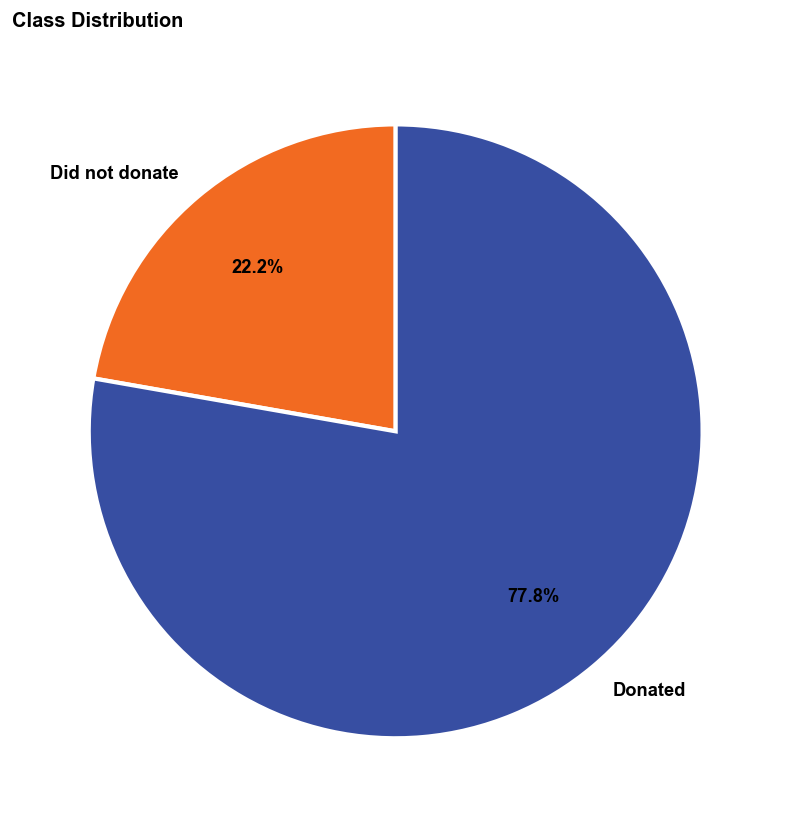

In [218]:
import matplotlib.pyplot as plt

# Data setup
counts = data['target_purchased'].value_counts().sort_index()
labels = ['Did not donate', 'Donated']
colours = [u_orange, u_blue]

# Create the pie chart
plt.figure(figsize=(8, 7))

wedges, texts, autotexts = plt.pie(
    counts.values,
    labels=labels,           # Added labels here
    autopct='%1.1f%%',
    startangle=90,
    colors=colours,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    pctdistance=0.7,
    labeldistance=1.1        # Adjusts the distance of the labels from the center
)

# Formatting
plt.title('Class Distribution', loc='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('pie_chart.png')

The target variable analysis identifies a baseline conversion rate of 77.76% across 69,105 sessions. This distribution establishes a high performance floor where an informed majority guess achieves 0.7776 accuracy without any feature input.

The imbalance ratio of 0.29 to 1 indicates that the majority of the dataset consists of successful conversions. For this EDA, the focus shifts from general conversion drivers to identifying the specific friction points that lead to the 22.24% drop off rate despite the high intent observed across the site. Accuracy alone will not be a sufficient metric for evaluating future predictive utility because the proportional and informed baselines are already elevated.

### 2.2. Continuous Predictors

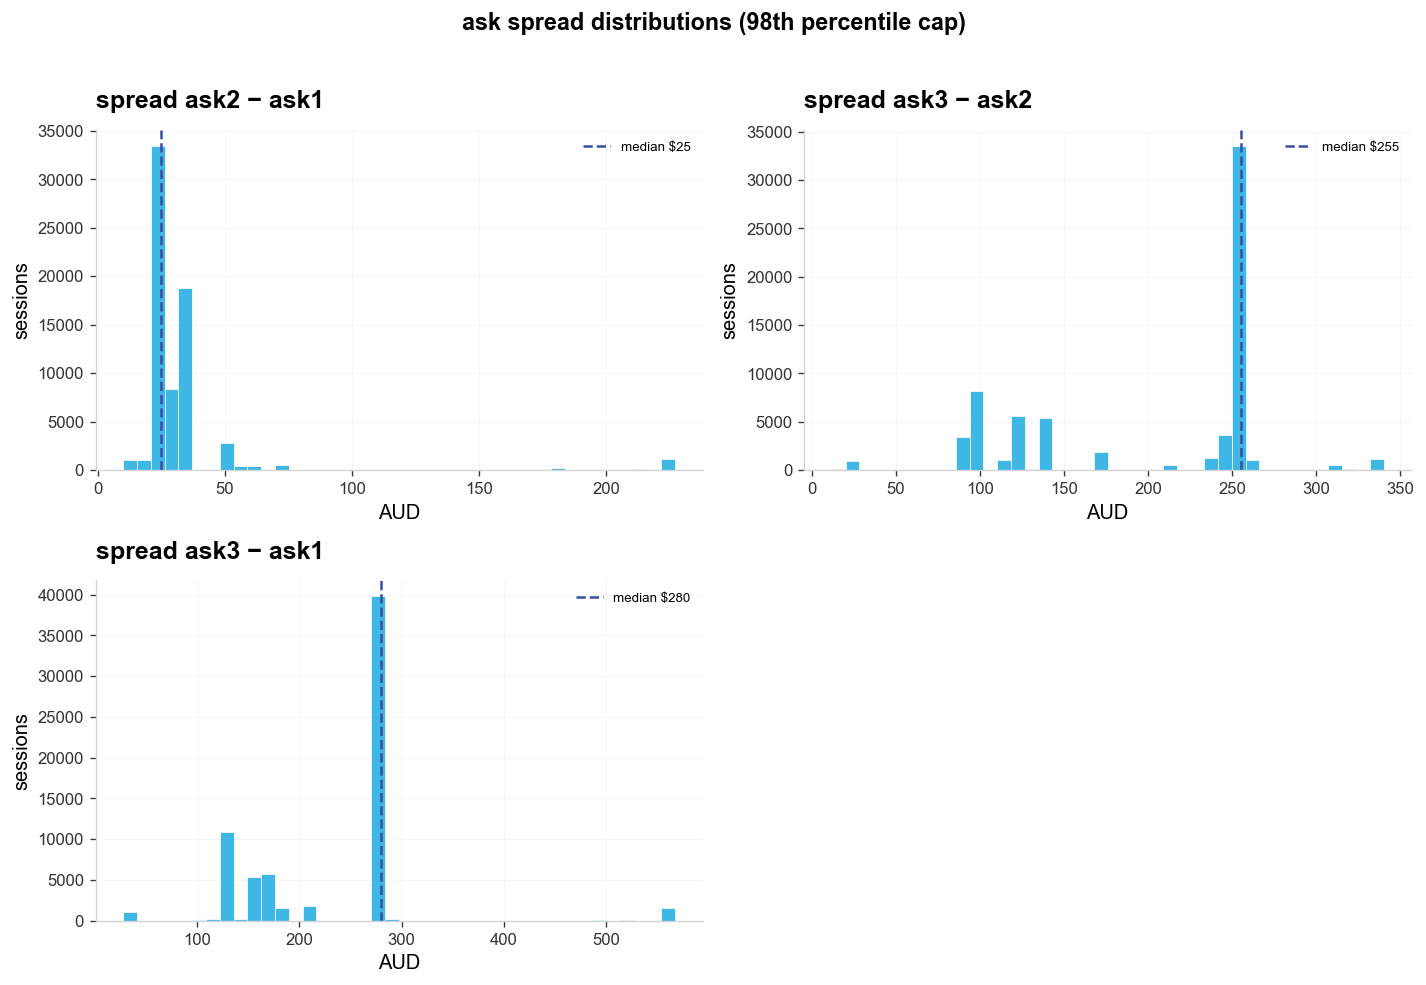

In [221]:
# ask spread and ratio distributions
data['spread_12'] = data['once_ask2'] - data['once_ask1']
data['spread_23'] = data['once_ask3'] - data['once_ask2']
data['spread_13'] = data['once_ask3'] - data['once_ask1']

spread_cols   = ['spread_12', 'spread_23', 'spread_13']
spread_labels = ['spread ask2 − ask1', 'spread ask3 − ask2', 'spread ask3 − ask1']

# Change to a 2x2 grid (max 2 side-by-side) and adjust the height
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten() # Flatten the 2D axes array to easily iterate 

for i, (col, label) in enumerate(zip(spread_cols, spread_labels)):
    ax = axes[i]
    series  = data[col].dropna()
    clipped = series[series <= series.quantile(0.98)]
    ax.hist(clipped, bins=40, color=u_cyan, edgecolor='white',
            linewidth=0.5, alpha=0.85)
    ax.axvline(series.median(), color=u_blue, linestyle='--',
               linewidth=1.5, label=f'median ${series.median():.0f}')
    ax.set_title(label, loc='left')
    ax.set_xlabel('AUD')
    ax.set_ylabel('sessions')
    ax.legend(fontsize=8, frameon=False)
    strip_axes(ax)

# Hide the 4th (empty) subplot
axes[3].axis('off')

plt.suptitle('ask spread distributions (98th percentile cap)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

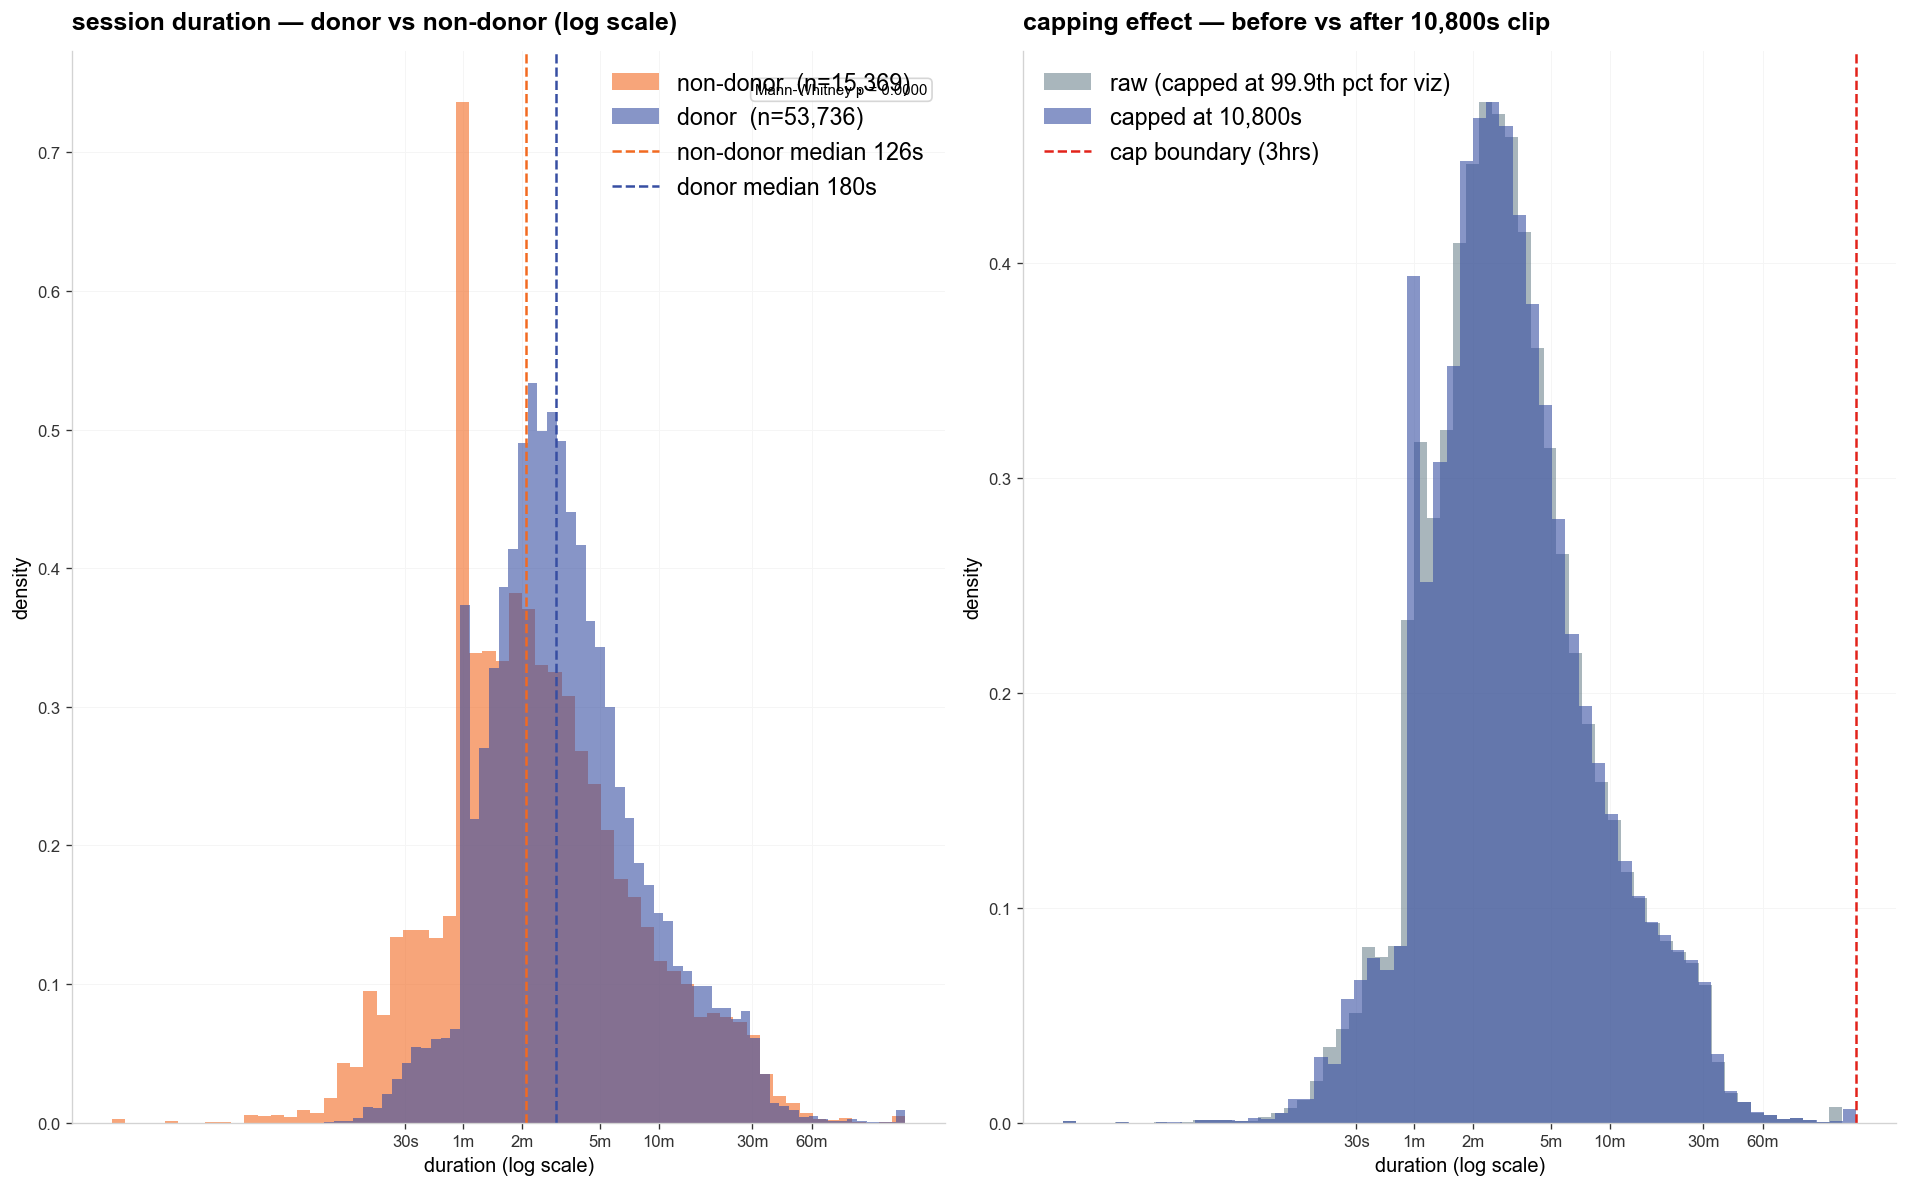

sessions above cap (10800s): 60 (0.09%)


In [222]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# ── left: donor vs non-donor overlay (log scale) ─────────────────────────────
d1 = data[data['target_purchased'] == 1]['session_duration'].dropna()
d0 = data[data['target_purchased'] == 0]['session_duration'].dropna()

axes[0].hist(np.log1p(d0), bins=60, color=u_orange, alpha=0.6,
             density=True, label=f'non-donor  (n={len(d0):,})')
axes[0].hist(np.log1p(d1), bins=60, color=u_blue, alpha=0.6,
             density=True, label=f'donor  (n={len(d1):,})')
axes[0].axvline(np.log1p(d0.median()), color=u_orange,
                linestyle='--', linewidth=1.5,
                label=f'non-donor median {d0.median():.0f}s')
axes[0].axvline(np.log1p(d1.median()), color=u_blue,
                linestyle='--', linewidth=1.5,
                label=f'donor median {d1.median():.0f}s')

tick_vals = [30, 60, 120, 300, 600, 1800, 3600]
axes[0].set_xticks(np.log1p(tick_vals))
axes[0].set_xticklabels([f'{v}s' if v < 60 else f'{v//60}m' for v in tick_vals])
axes[0].set_title('session duration — donor vs non-donor (log scale)', loc='left')
axes[0].set_xlabel('duration (log scale)')
axes[0].set_ylabel('density')
axes[0].legend(fontsize=14, frameon=False)
strip_axes(axes[0])

u_stat, p_val = mannwhitneyu(d1, d0, alternative='two-sided')
axes[0].text(0.98, 0.97,
             f'Mann-Whitney p = {p_val:.4f}',
             transform=axes[0].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#CCCCCC', alpha=0.8))

# ── right: capping effect before vs after 10800s ─────────────────────────────
raw_dur    = data['session_duration_seconds'] if 'session_duration_seconds' in data.columns \
             else data['session_duration']
capped_dur = data['session_duration']

axes[1].hist(np.log1p(raw_dur.clip(upper=raw_dur.quantile(0.999))),
             bins=60, color=u_grey, alpha=0.5,
             density=True, label='raw (capped at 99.9th pct for viz)')
axes[1].hist(np.log1p(capped_dur),
             bins=60, color=u_blue, alpha=0.6,
             density=True, label='capped at 10,800s')
axes[1].axvline(np.log1p(10800), color=u_red, linestyle='--',
                linewidth=1.5, label='cap boundary (3hrs)')

axes[1].set_xticks(np.log1p(tick_vals))
axes[1].set_xticklabels([f'{v}s' if v < 60 else f'{v//60}m' for v in tick_vals])
axes[1].set_title('capping effect — before vs after 10,800s clip', loc='left')
axes[1].set_xlabel('duration (log scale)')
axes[1].set_ylabel('density')
axes[1].legend(fontsize=14, frameon=False)
strip_axes(axes[1])

plt.tight_layout()
plt.show()

print(f"sessions above cap (10800s): "
      f"{(data['session_duration'] >= 10800).sum():,} "
      f"({(data['session_duration'] >= 10800).mean()*100:.2f}%)")

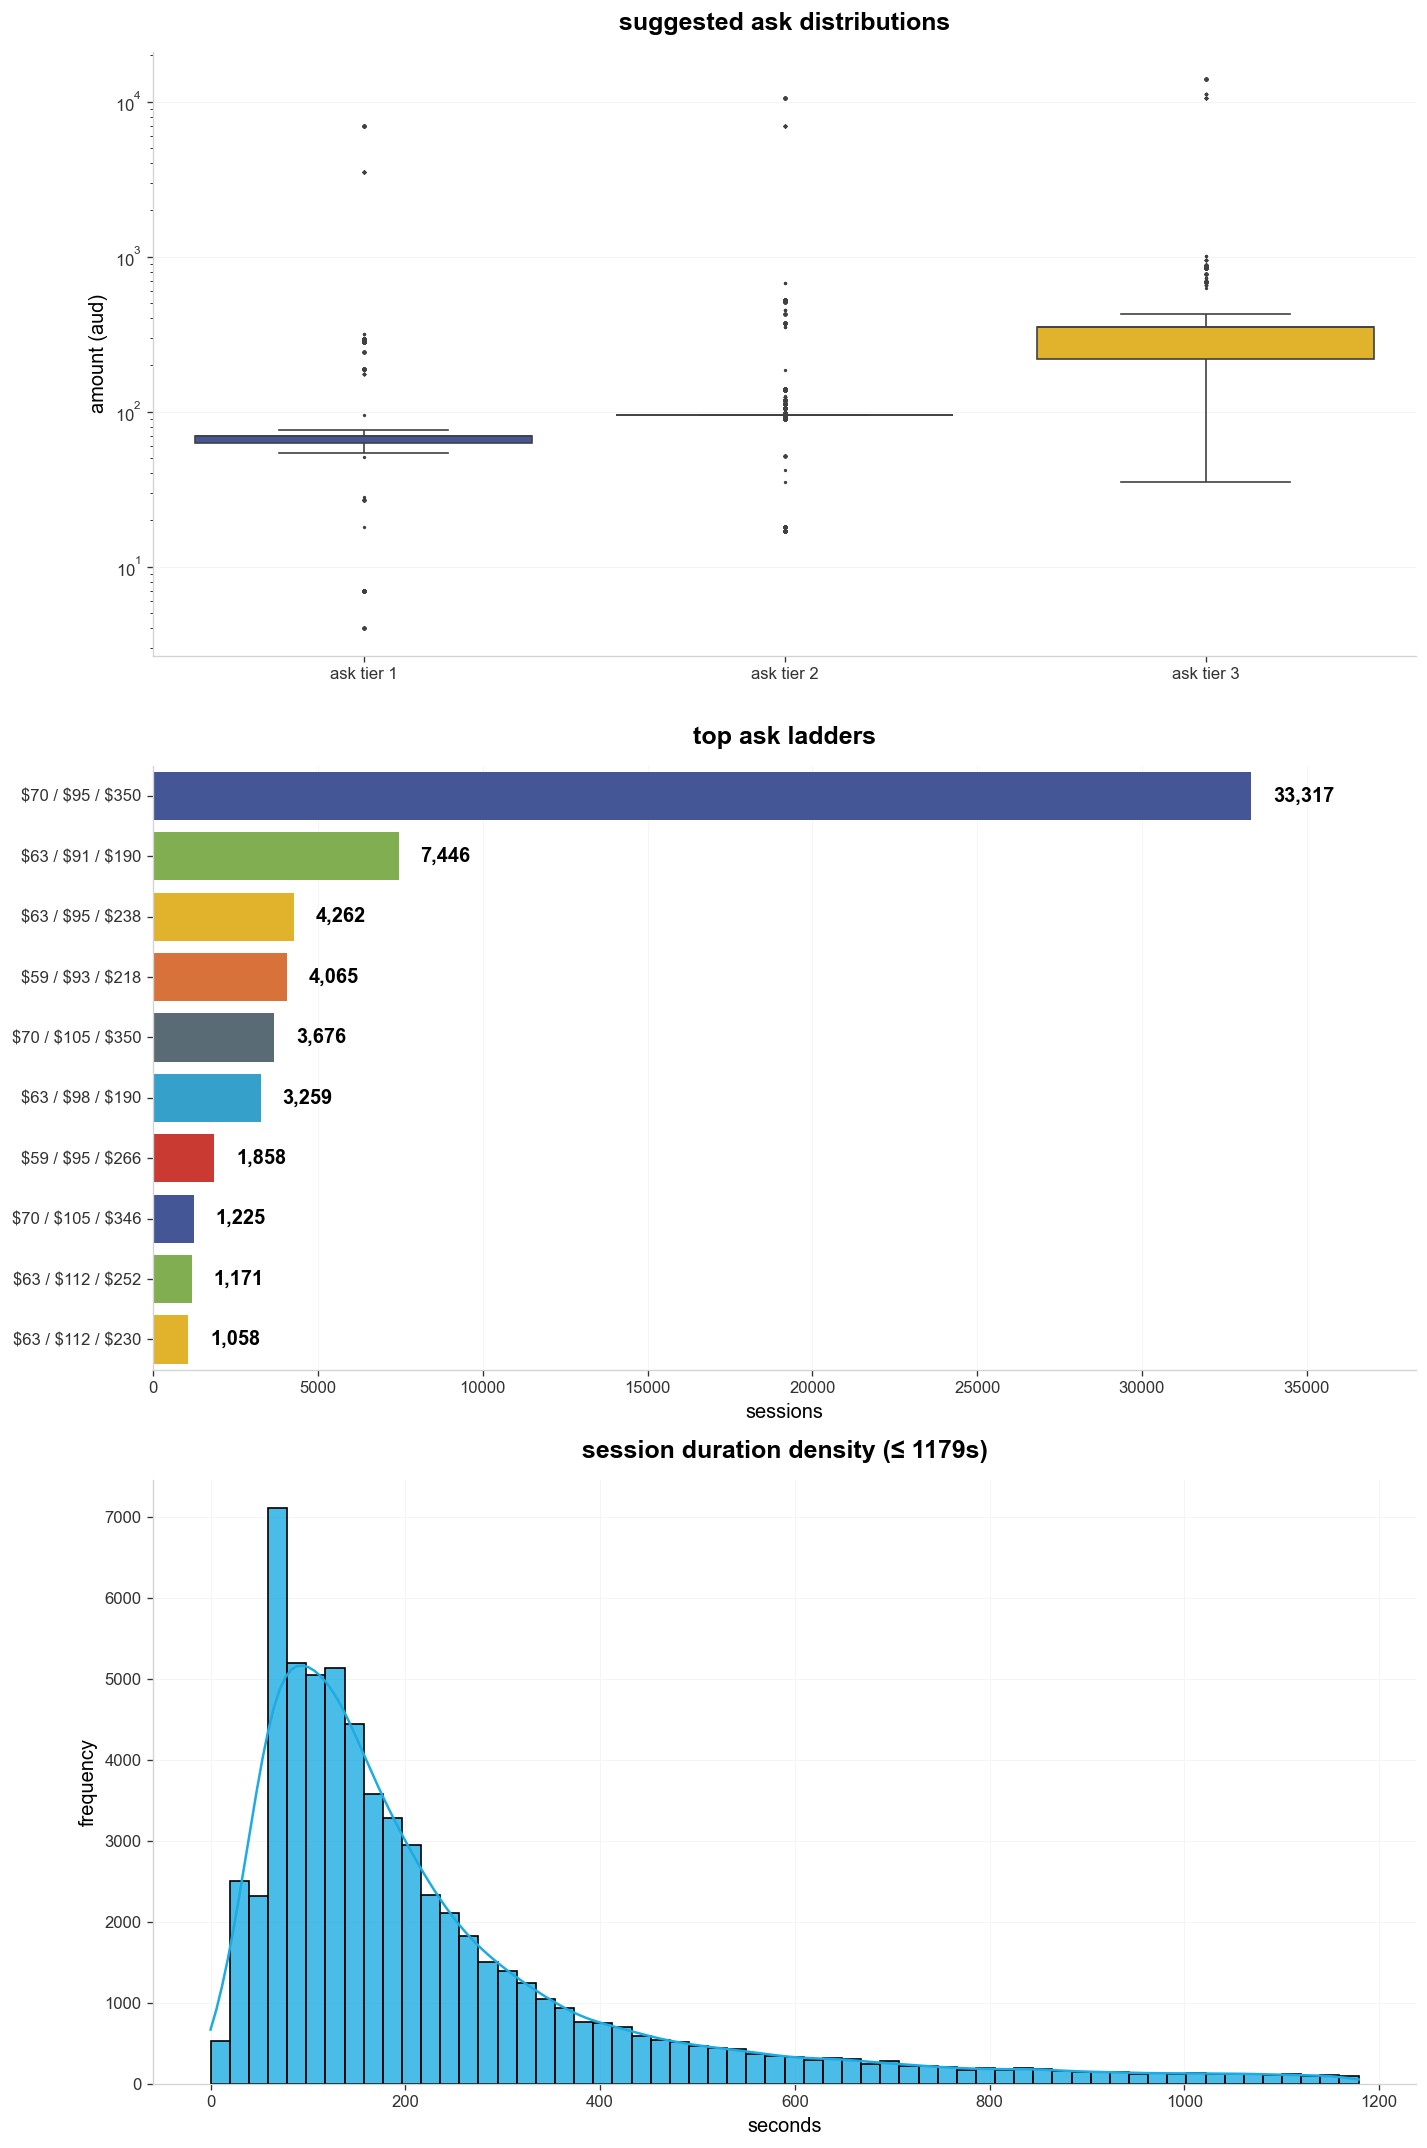

=== ask distribution ===
            min      max  median    iqr    range
once_ask1  4.00  7000.00   70.00   7.00  6996.00
once_ask2 17.00 10500.00   95.00   0.00 10483.00
once_ask3 35.00 14000.00  350.00 132.00 13965.00

=== variation by landing family ===
                       once_ask1  once_ask2  once_ask3
land_family                                           
general_donation           63.00      95.00     218.00
intent_based_donation      70.00      95.00     350.00
other_engagement           70.00      95.00     350.00

=== session duration ===
min          0.00
max      10800.00
mean       321.41
median     170.00
std        542.49
Name: session_duration, dtype: float64
iqr: 227.00
>3600s: 175 (0.25%)


In [223]:
import matplotlib.gridspec as gridspec

# Data processing (kept as is)
ask_cols = ['once_ask1', 'once_ask2', 'once_ask3']
duration_col = 'session_duration'

ask_stats = data[ask_cols].agg(
    ['min', 'max', 'median', lambda x: x.quantile(.75) - x.quantile(.25)]
).T
ask_stats.columns = ['min', 'max', 'median', 'iqr']
ask_stats['range'] = ask_stats['max'] - ask_stats['min']

variation_stats = data.groupby('land_family')[ask_cols].median()
duration_summary = data[duration_col].agg(['min', 'max', 'mean', 'median', 'std']).round(2)
duration_iqr = data[duration_col].quantile(.75) - data[duration_col].quantile(.25)
extreme_sessions = (data[duration_col] > 3600).sum()

# Setup for individual rows (3 rows, 1 column)
fig = plt.figure(figsize=(12, 18)) # Taller figure for 3 individual rows
gs = gridspec.GridSpec(3, 1, figure=fig)

# ── Row 1: Suggested Ask Distributions ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=data[ask_cols].melt(),
    x='variable', y='value',
    palette=get_rotating_colors(3),
    fliersize=1, ax=ax1
)
ax1.set(yscale='log', title='suggested ask distributions', xlabel='', ylabel='amount (aud)')
ax1.set_xticklabels(['ask tier 1', 'ask tier 2', 'ask tier 3'])
strip_axes(ax1)

# ── Row 2: Top Ask Ladders ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ask_ladders = (
    data.groupby(ask_cols).size().reset_index(name='count')
    .sort_values('count', ascending=False).head(10)
)
ask_ladders['ladder'] = ask_ladders[ask_cols].apply(
    lambda x: f'${x.iloc[0]:.0f} / ${x.iloc[1]:.0f} / ${x.iloc[2]:.0f}', axis=1
)
sns.barplot(
    data=ask_ladders, x='count', y='ladder',
    palette=get_rotating_colors(len(ask_ladders)), ax=ax2
)
ax2.set_xlim(0, ask_ladders['count'].max() * 1.15)
ax2.set(title='top ask ladders', xlabel='sessions', ylabel='')
for p in ax2.patches:
    ax2.text(
        p.get_width() + ask_ladders['count'].max() * .02,
        p.get_y() + p.get_height() / 2,
        f'{int(p.get_width()):,}',
        va='center', ha='left', fontsize=12, fontweight='bold'
    )
strip_axes(ax2)

# ── Row 3: Session Duration Density ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
upper = data[duration_col].quantile(.95)
sns.histplot(
    data.loc[data[duration_col] <= upper, duration_col],
    bins=60, kde=True, color=u_cyan, alpha=.8, ax=ax3
)
ax3.set(title=f'session duration density (≤ {upper:.0f}s)', xlabel='seconds', ylabel='frequency')
strip_axes(ax3)

plt.tight_layout()
plt.show()

# Stats prints (kept as is)
print('=== ask distribution ===')
print(ask_stats.round(2))
print('\n=== variation by landing family ===')
print(variation_stats)
print('\n=== session duration ===')
print(duration_summary)
print(f'iqr: {duration_iqr:.2f}')
print(f'>3600s: {extreme_sessions} ({extreme_sessions / len(data) * 100:.2f}%)')

The univariate analysis of continuous predictors identifies a highly standardised donation experience dominated by static anchoring.

The suggested ask amounts show significant concentration, with the most frequent configuration $\$70$ / $\$95$ / $\$350$ appearing in the vast majority of sessions. While the boxplots reveal extreme outliers reaching up to \$14,000, the interquartile range for primary asks is notably narrow. This indicates that framing is consistent across different entry points, which represents a missed opportunity for revenue optimisation through dynamic price ladders tailored to donor capacity.

Session duration exhibits severe right skew, with a median of 170 seconds compared to a maximum of 10,800 seconds. The density plot confirms that the primary window for conversion decisions occurs within the first three minutes of user interaction. Because only 1.21% of sessions exceed one hour, the tracking limits effectively isolate the relevant decision-making window from extreme long-tail noise. Strategic interventions to reduce friction must be front-loaded to capitalise on this brief period of high engagement.

In [225]:
# ask amount segmentation
ask_standard = data[data['once_ask1'] < 1000]
ask_high = data[data['once_ask1'] >= 1000]

print("=== ask summary — full dataset ===")
for col in ['once_ask1', 'once_ask2', 'once_ask3']:
    print(f"\n{col}:")
    print(f"  median: {data[col].median():.0f} | mean: {data[col].mean():.0f} | "
          f"min: {data[col].min():.0f} | max: {data[col].max():.0f} | "
          f"IQR: {data[col].quantile(0.75)-data[col].quantile(0.25):.0f}")

print("\n=== standard segment (ask1 < $1000) ===")
print(f"sessions: {len(ask_standard):,} ({len(ask_standard)/len(data)*100:.1f}%)")
for col in ['once_ask1', 'once_ask2', 'once_ask3']:
    print(f"{col}: median={ask_standard[col].median():.0f} | "
          f"IQR={ask_standard[col].quantile(0.75)-ask_standard[col].quantile(0.25):.0f}")

print("\n=== high value segment (ask1 >= $1000) ===")
print(f"sessions: {len(ask_high):,} ({len(ask_high)/len(data)*100:.1f}%)")
for col in ['once_ask1', 'once_ask2', 'once_ask3']:
    print(f"{col}: median={ask_high[col].median():.0f} | "
          f"IQR={ask_high[col].quantile(0.75)-ask_high[col].quantile(0.25):.0f}")

print("\n=== step-up ratios ===")
data['ratio_12'] = data['once_ask2'] / data['once_ask1']
data['ratio_23'] = data['once_ask3'] / data['once_ask2']
data['ratio_13'] = data['once_ask3'] / data['once_ask1']

for seg, df in [('standard', ask_standard), ('high value', ask_high)]:
    print(f"\n{seg}:")
    for r in ['ratio_12', 'ratio_23', 'ratio_13']:
        ratio = df['once_ask3'] / df['once_ask1'] if r == 'ratio_13' else \
                df['once_ask2'] / df['once_ask1'] if r == 'ratio_12' else \
                df['once_ask3'] / df['once_ask2']
        print(f"  {r}: median={ratio.median():.2f} | p75={ratio.quantile(0.75):.2f} | max={ratio.max():.2f}")

print("\n=== top 5 most common ladders ===")
print(data.groupby(['once_ask1','once_ask2','once_ask3']).size()
      .reset_index(name='n').sort_values('n', ascending=False).head(5))

print("\n=== session duration ===")
print(f"median: {data['session_duration'].median():.0f}s")
print(f"mean: {data['session_duration'].mean():.0f}s")
print(f"p25: {data['session_duration'].quantile(0.25):.0f}s")
print(f"p75: {data['session_duration'].quantile(0.75):.0f}s")

=== ask summary — full dataset ===

once_ask1:
  median: 70 | mean: 82 | min: 4 | max: 7000 | IQR: 7

once_ask2:
  median: 95 | mean: 122 | min: 17 | max: 10500 | IQR: 0

once_ask3:
  median: 350 | mean: 330 | min: 35 | max: 14000 | IQR: 132

=== standard segment (ask1 < $1000) ===
sessions: 69,002 (99.9%)
once_ask1: median=70 | IQR=7
once_ask2: median=95 | IQR=0
once_ask3: median=350 | IQR=132

=== high value segment (ask1 >= $1000) ===
sessions: 103 (0.1%)
once_ask1: median=7000 | IQR=0
once_ask2: median=10500 | IQR=0
once_ask3: median=14000 | IQR=0

=== step-up ratios ===

standard:
  ratio_12: median=1.43 | p75=1.51 | max=4.50
  ratio_23: median=3.68 | p75=3.68 | max=5.00
  ratio_13: median=5.00 | p75=5.00 | max=10.00

high value:
  ratio_12: median=1.50 | p75=1.50 | max=2.00
  ratio_23: median=1.33 | p75=1.33 | max=1.60
  ratio_13: median=2.00 | p75=2.00 | max=3.20

=== top 5 most common ladders ===
    once_ask1  once_ask2  once_ask3      n
44      70.00      95.00     350.00  33

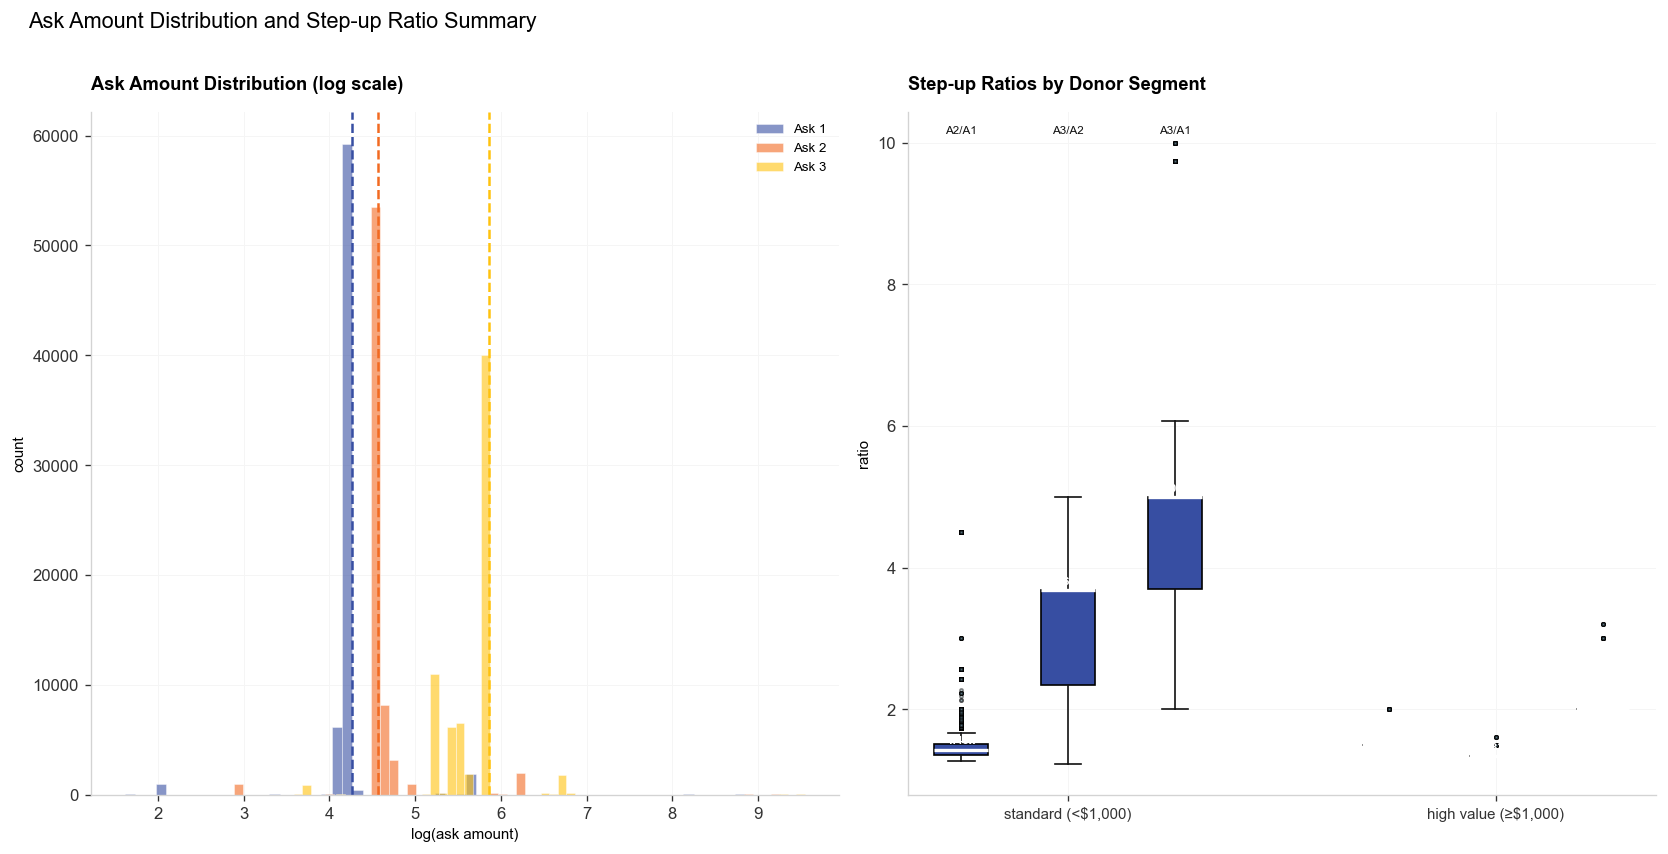

In [226]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ── left: ask distributions overlaid ─────────────────────────
ax = axes[0]
colours = [u_blue, u_orange, u_yellow]
for col, label, c in zip(
    ['once_ask1', 'once_ask2', 'once_ask3'],
    ['Ask 1', 'Ask 2', 'Ask 3'],
    colours
):
    vals = data[col].dropna()
    ax.hist(np.log1p(vals), bins=60, color=c, alpha=0.6,
            edgecolor='white', linewidth=0.4, label=label)
    ax.axvline(np.log1p(vals.median()), color=c,
               linewidth=1.5, linestyle='--')

ax.set_title('Ask Amount Distribution (log scale)', loc='left', fontsize=11)
ax.set_xlabel('log(ask amount)', fontsize=9)
ax.set_ylabel('count', fontsize=9)
ax.legend(fontsize=8, frameon=False)
strip_axes(ax)

# ── right: step-up ratio boxplots ────────────────────────────
ax = axes[1]
standard = data[data['once_ask1'] < 1000].copy()
highval  = data[data['once_ask1'] >= 1000].copy()

for df in [standard, highval]:
    df['ratio_12'] = df['once_ask2'] / df['once_ask1']
    df['ratio_23'] = df['once_ask3'] / df['once_ask2']
    df['ratio_13'] = df['once_ask3'] / df['once_ask1']

positions = [1, 2, 3, 5, 6, 7]
box_data  = [
    standard['ratio_12'].dropna(),
    standard['ratio_23'].dropna(),
    standard['ratio_13'].dropna(),
    highval['ratio_12'].dropna(),
    highval['ratio_23'].dropna(),
    highval['ratio_13'].dropna(),
]
box_colours = [u_blue] * 3 + [u_orange] * 3

bp = ax.boxplot(
    box_data,
    positions=positions,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color=u_dark, linewidth=1),
    capprops=dict(color=u_dark, linewidth=1),
    flierprops=dict(marker='o', markersize=2,
                    markerfacecolor=u_grey, alpha=0.4)
)
for patch, c in zip(bp['boxes'], box_colours):
    patch.set_facecolor(c)

for pos, d in zip(positions, box_data):
    med = d.median()
    ax.text(pos, med + 0.05, f'{med:.2f}x',
            ha='center', va='bottom', fontsize=7,
            color='white', fontweight='bold')

ax.set_xticks([2, 6])
ax.set_xticklabels(['standard (<$1,000)', 'high value (≥$1,000)'], fontsize=9)
ax.set_title('Step-up Ratios by Donor Segment', loc='left', fontsize=11)
ax.set_ylabel('ratio', fontsize=9)

# ratio labels on top
for pos, lbl in zip([1, 2, 3], ['A2/A1', 'A3/A2', 'A3/A1']):
    ax.text(pos, ax.get_ylim()[1] * 0.97, lbl,
            ha='center', fontsize=7, color=u_dark)

strip_axes(ax)

fig.suptitle('Ask Amount Distribution and Step-up Ratio Summary',
             fontsize=13, x=0.02, ha='left', y=1.01)
plt.tight_layout()
plt.show()

### 2.3. Categorical Predictors

#### 2.3.a. Source, Medium & Channel 

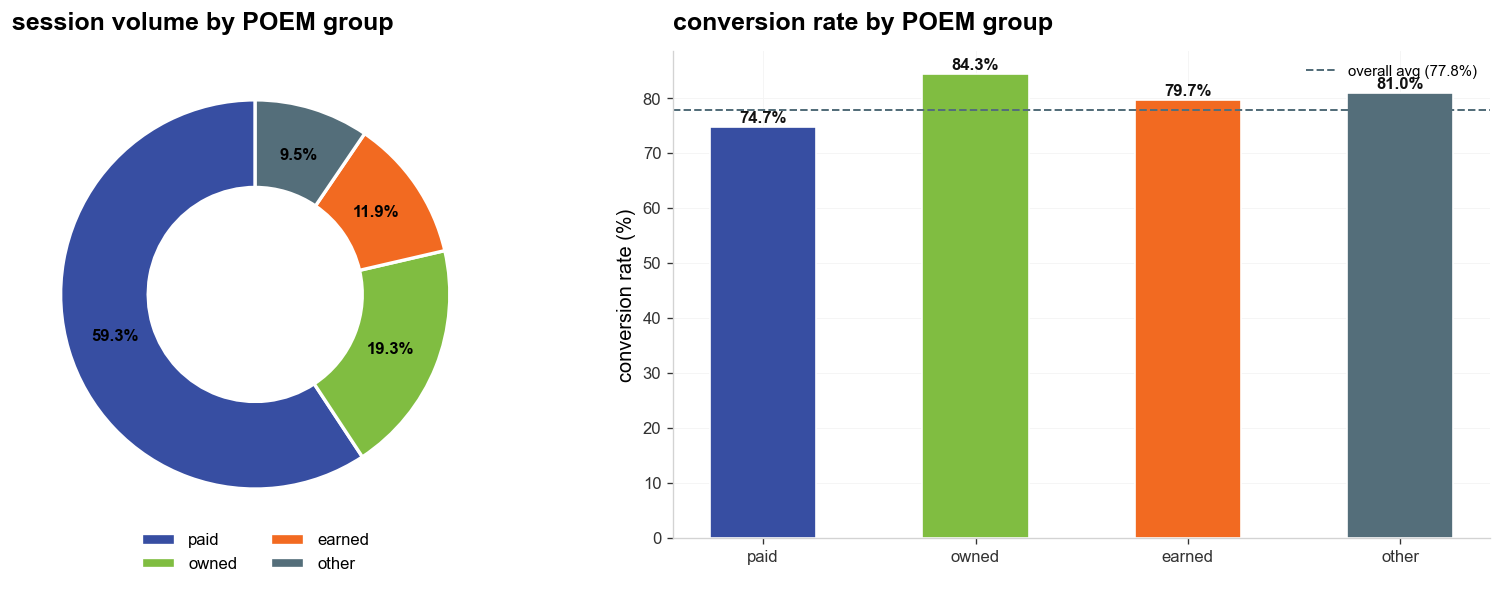

In [229]:
# POEM grouping — paid vs owned vs earned
poem_map = {
    'paid_search'   : 'paid',
    'paid_social'   : 'paid',
    'cross_network' : 'paid',
    'display'       : 'paid',
    'email'         : 'owned',
    'sms'           : 'owned',
    'offline'       : 'owned',
    'direct'        : 'owned',
    'organic_search': 'earned',
    'organic_social': 'earned',
    'organic_video' : 'earned',
    'referral'      : 'earned',
    'internal'      : 'other',
    'bot_or_scanner': 'other',
    'unknown'       : 'other',
}

data['poem_group'] = data['session_channel'].map(poem_map).fillna('other')

poem_counts = data['poem_group'].value_counts()
poem_cr     = data.groupby('poem_group')['target_purchased'].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# donut — volume share
poem_colours = [u_blue, u_green, u_orange, u_grey]
wedges, _, autotexts = axes[0].pie(
    poem_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=poem_colours[:len(poem_counts)],
    wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10, 'fontweight': 'bold'},
    pctdistance=0.75
)
axes[0].legend(wedges, poem_counts.index,
               loc='lower center', bbox_to_anchor=(0.5, -0.1),
               ncol=2, frameon=False, fontsize=10)
axes[0].set_title('session volume by POEM group', loc='left')

# bar — conversion rate by POEM group
poem_cr_sorted = poem_cr.reindex(poem_counts.index)
bars = axes[1].bar(poem_cr_sorted.index, poem_cr_sorted.values,
                   color=poem_colours[:len(poem_cr_sorted)],
                   width=0.5, edgecolor='white')
axes[1].axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
                linewidth=1.2,
                label=f'overall avg ({OVERALL_CR*100:.1f}%)')
axes[1].set_ylabel('conversion rate (%)')
axes[1].set_title('conversion rate by POEM group', loc='left')
axes[1].legend(fontsize=9, frameon=False)

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=10,
                 fontweight='bold', color=u_dark)

strip_axes(axes[1])
plt.tight_layout()
plt.show()

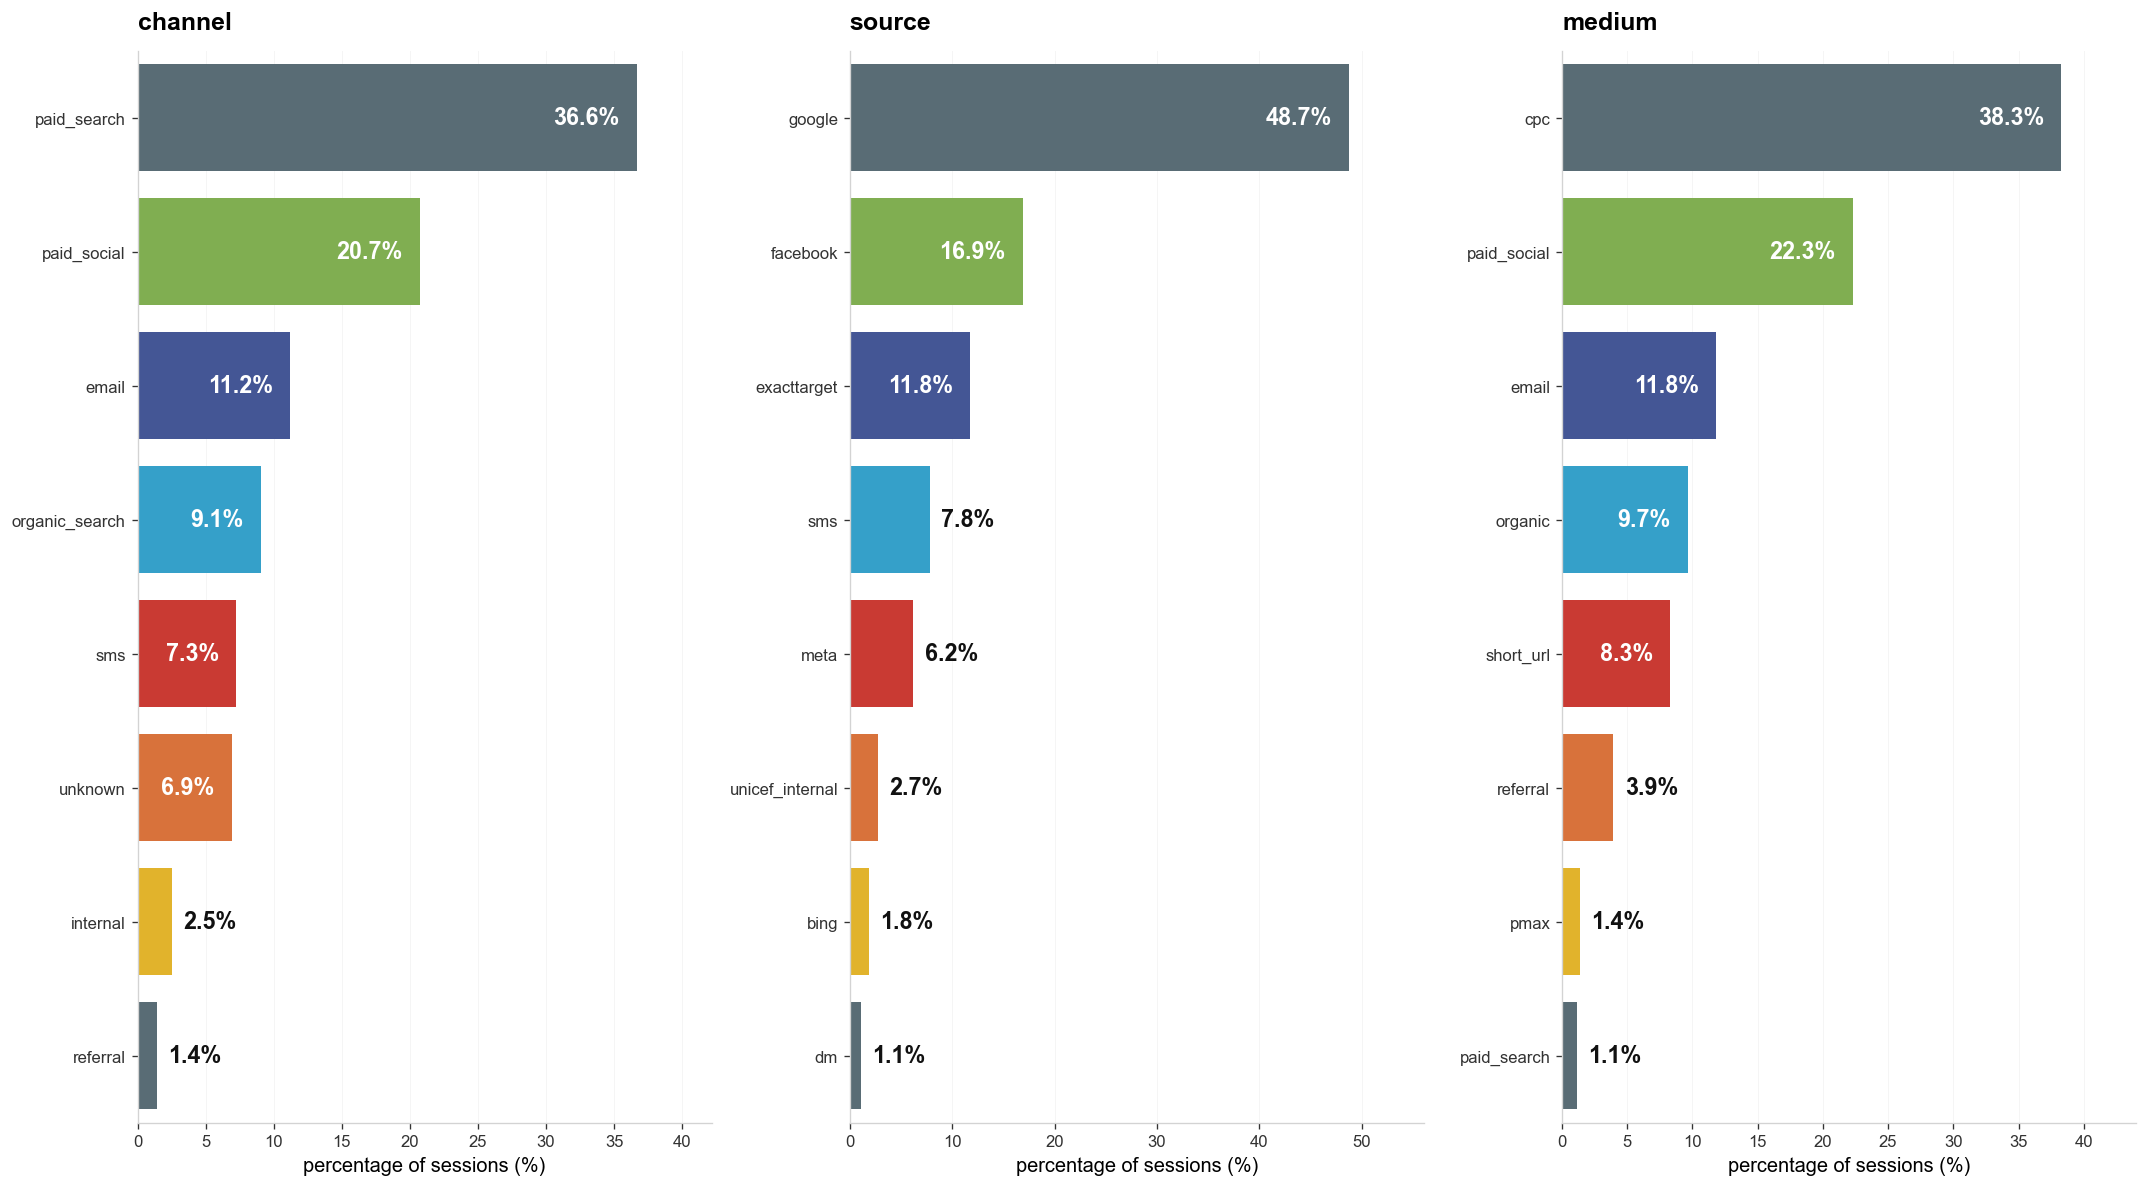

In [230]:
acquisition_cols = ['session_channel', 'session_source', 'session_medium']

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

for ax, col in zip(axes, acquisition_cols):
    counts = data[col].value_counts(normalize=True).head(8).mul(100)
    
    sns.barplot(
        x=counts.values,
        y=counts.index.astype(str),
        palette=get_rotating_colors(len(counts), seed=5),
        ax=ax
    )
    ax.set_xlim(0, counts.max() * 1.15)
    ax.set_title(col.replace('session_', ''), loc='left')
    ax.set_xlabel('percentage of sessions (%)')
    ax.set_ylabel('')
    
    append_bar_values(ax, format_str='{:.1f}%', text_size=14)
    strip_axes(ax)

plt.tight_layout()
plt.show()

Traffic acquisition is highly concentrated in paid channels, with paid search contributing 36.8% of sessions and paid social a further 20.7%. This indicates that the majority of traffic is driven by performance marketing rather than organic or owned channels.

At the source level, Google accounts for 48.7% of all sessions, significantly outweighing Facebook at 18.9% and other sources. This level of concentration creates dependency on a single platform, exposing acquisition performance to cost volatility and algorithm changes.

Email contributes 11.2% of sessions, representing a meaningful but secondary channel. Organic search and SMS remain relatively limited at 9.1% and 7.3% respectively, while referral and internal traffic are minimal.

From a medium perspective, paid search (38.3%) and paid social (22.3%) dominate, reinforcing the reliance on paid acquisition. Organic (9.7%) and referral (3.0%) channels are underrepresented relative to their potential for scalable, lower-cost traffic.

The current mix reflects strong short-term acquisition capability but limited channel diversification and underutilisation of sustainable traffic sources.

#### 2.3.b. Device Category & OS 

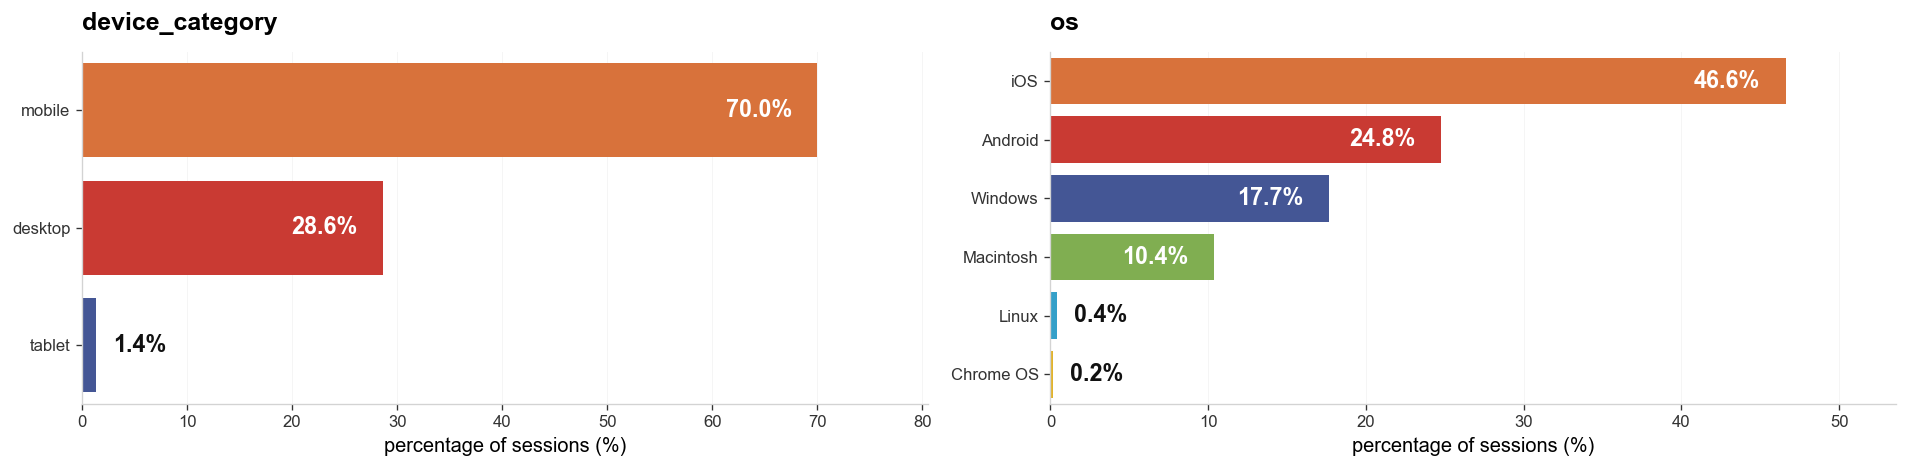

In [233]:
tech_cols = ['device_category', 'os']

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, col in zip(axes, tech_cols):
    counts = data[col].value_counts(normalize=True).head(8).mul(100)
    
    sns.barplot(
        x=counts.values,
        y=counts.index.astype(str),
        palette=get_rotating_colors(len(counts), seed=6),
        ax=ax
    )
    
    ax.set_xlim(0, counts.max() * 1.15)
    ax.set_title(col, loc='left')
    ax.set_xlabel('percentage of sessions (%)')
    ax.set_ylabel('')
    
    append_bar_values(ax, format_str='{:.1f}%', text_size=14)
    strip_axes(ax)

plt.tight_layout()
plt.show()

User traffic is overwhelmingly mobile-driven, with mobile devices accounting for 70.0% of all sessions compared to 28.6% on desktop and only 1.4% on tablet. This confirms that the donation journey is primarily experienced on smaller screens, making mobile optimisation a critical driver of overall performance.

At the operating system level, iOS leads with 46.6% of sessions, followed by Android at 24.8%. Combined, mobile operating systems represent over 70% of total traffic, reinforcing the dominance of mobile usage. Desktop environments, including Windows (17.7%) and Macintosh (10.4%), form a secondary but still material segment.

The concentration of traffic on iOS is particularly notable, suggesting a user base skewed towards higher-value devices, which may correlate with stronger donation capacity. However, the significant share of Android users highlights the need to ensure consistent performance across a wider range of device capabilities.

#### 2.3.c. Landing Page 

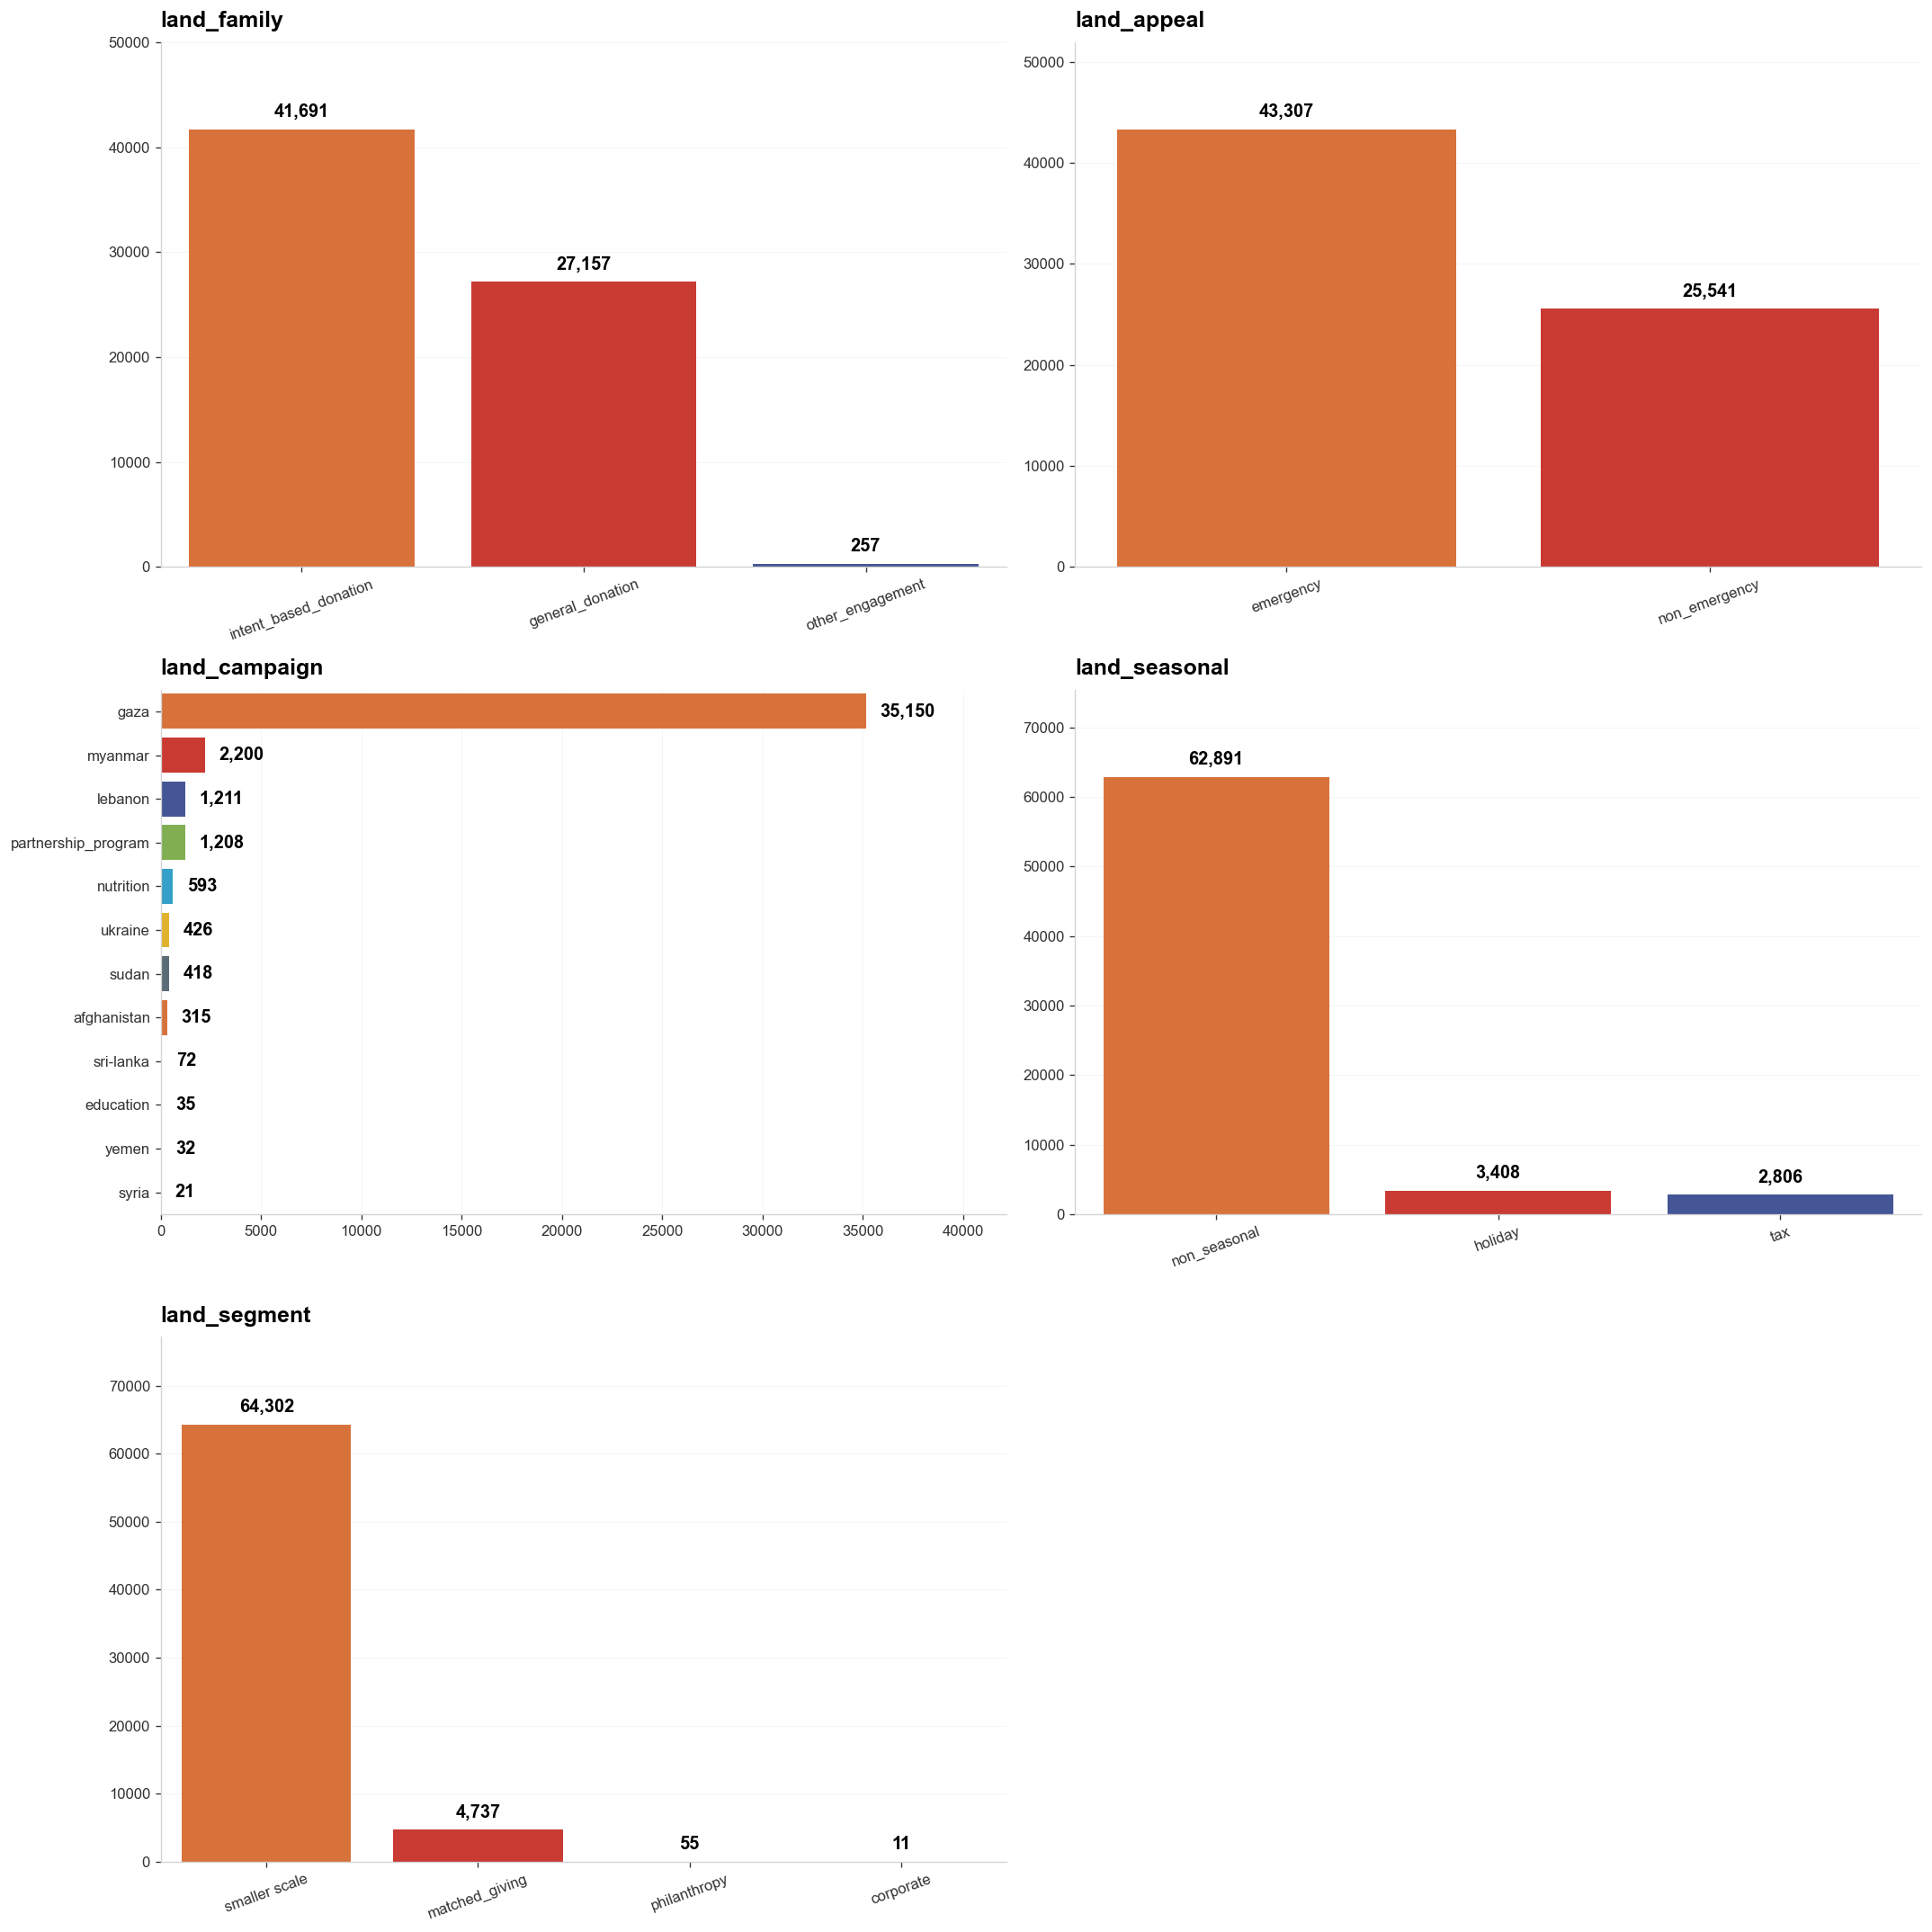

In [236]:
plot_data = data.copy()

plot_data['land_seasonal_grouped'] = plot_data['land_seasonal'].where(
    plot_data['land_seasonal'].isin(['holiday', 'tax']), 'non_seasonal'
)

plot_data['land_segment_grouped'] = plot_data['land_segment'].where(
    plot_data['land_segment'].isin(['matched_giving', 'philanthropy', 'corporate']), 'smaller scale'
)

cols = ['land_family', 'land_appeal', 'land_campaign', 'land_seasonal_grouped', 'land_segment_grouped']

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    counts = plot_data[col].dropna().value_counts()
    if col == 'land_campaign':
        counts = counts.head(12)

    sns.barplot(
        x=counts.values if col == 'land_campaign' else counts.index,
        y=counts.index if col == 'land_campaign' else counts.values,
        palette=get_rotating_colors(len(counts), seed=6),
        ax=ax
    )

    if col == 'land_campaign':
        ax.set_xlim(0, counts.max() * 1.2)
        for p in ax.patches:
            ax.annotate(
                f'{int(p.get_width()):,}',
                (p.get_width() + counts.max() * 0.02, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=12, fontweight='bold'
            )
    else:
        ax.set_ylim(0, counts.max() * 1.2)
        ax.tick_params(axis='x', rotation=20)
        for p in ax.patches:
            ax.annotate(
                f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height() + counts.max() * 0.02),
                ha='center', va='bottom', fontsize=12, fontweight='bold'
            )

    ax.set_title(col.replace('_grouped', ''), loc='left', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    strip_axes(ax)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

Most people are landing with a clear intent to donate, not really browsing around

Traffic is heavily driven by emergency appeals, with non emergency getting much less attention

Gaza completely dominates the campaign traffic, everything else is relatively small

Almost all traffic is non seasonal, so key periods like holiday and tax are not being fully used

Nearly everyone sits in non segment, with very little traffic going into matched giving, philanthropy, or corporate paths

#### 2.3.d. Last Page 

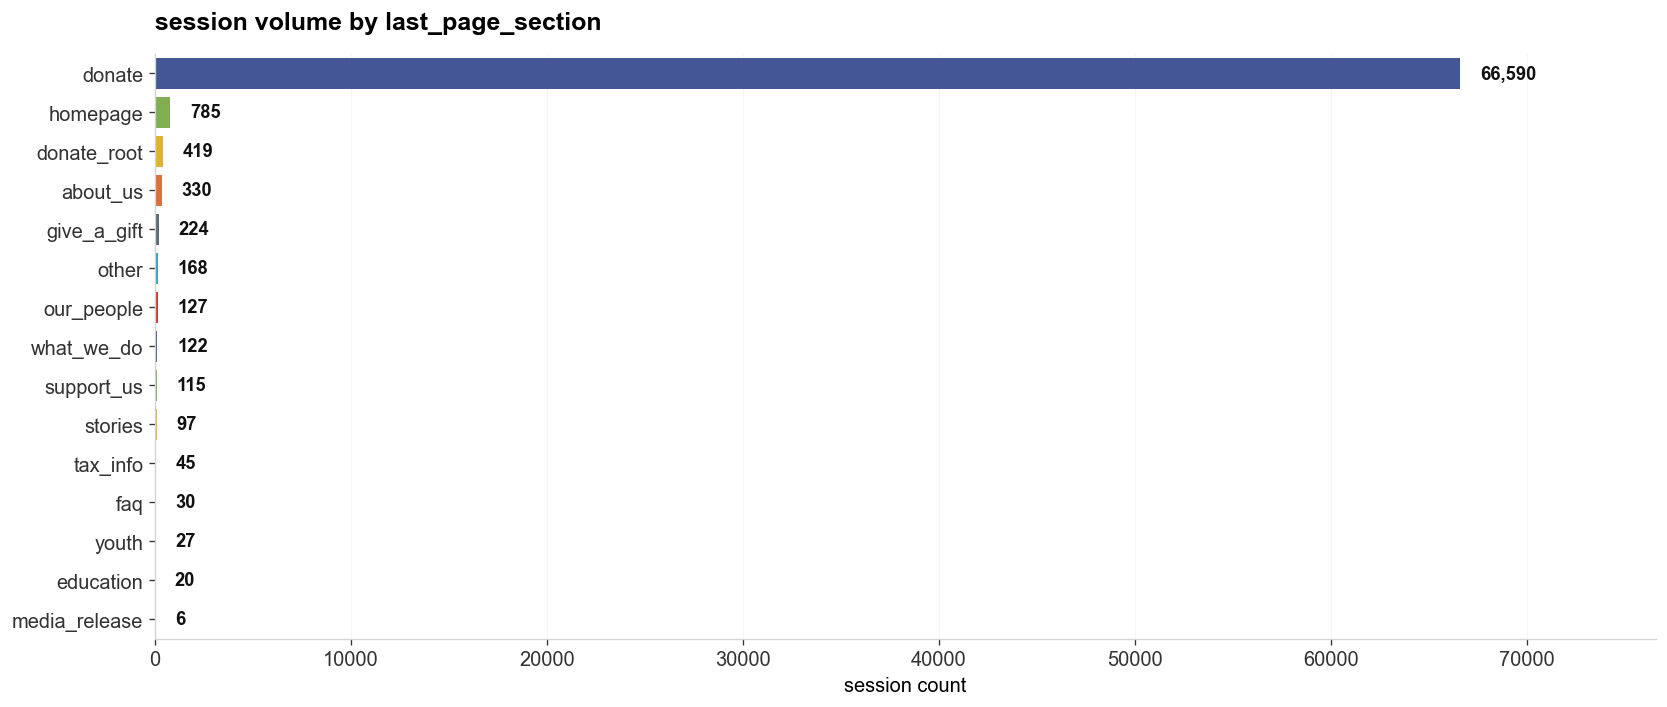

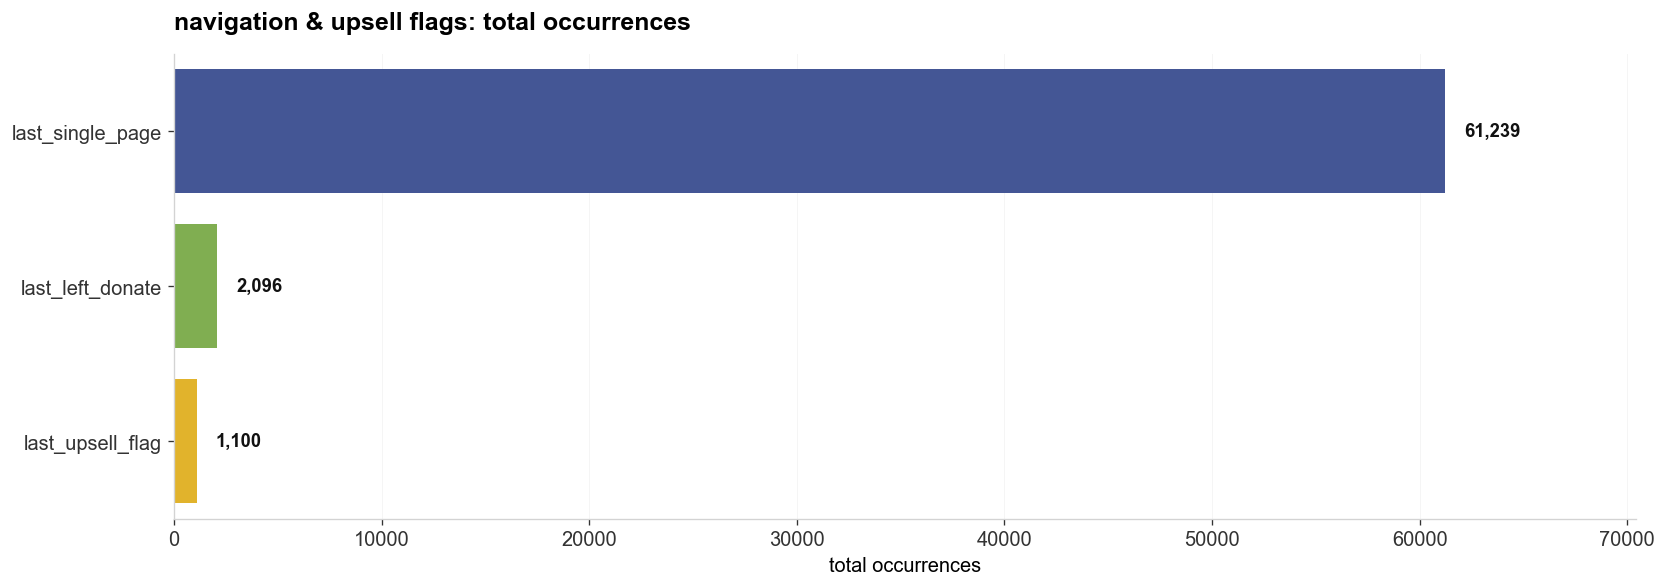

In [239]:
# ── volume diagnostics: terminal UX & navigation flags (Stacked Rows) ───────

# 1. Configuration & Data Prep
section_col = 'last_page_section'
flag_cols = ['last_upsell_flag', 'last_left_donate', 'last_single_page']

# Prep Last Page Data
sec_counts = data[section_col].value_counts()
# Prep Flag Data
flag_volumes = data[flag_cols].sum().sort_values(ascending=False)

# 2. ROW 1: Last Page Section (Full Width)
plt.figure(figsize=(14, 6))
ax1 = sns.barplot(x=sec_counts.values, y=sec_counts.index.astype(str), 
                  palette=get_rotating_colors(len(sec_counts)))

ax1.set_title(f'session volume by {section_col}', loc='left', fontsize=15, pad=15, fontweight='bold')
ax1.set_xlim(0, sec_counts.max() * 1.15)
ax1.set_xlabel('session count', fontsize=12)
ax1.set_ylabel('')

# Annotations for Row 1
for p in ax1.patches:
    ax1.text(p.get_width() + (sec_counts.max() * 0.015), p.get_y() + p.get_height()/2,
             f'{int(p.get_width()):,}', ha='left', va='center', 
             fontsize=11, fontweight='bold', color=u_dark)

strip_axes(ax1)
ax1.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()


# 3. ROW 2: Navigation & Upsell Flags (Full Width)
plt.figure(figsize=(14, 5))
ax2 = sns.barplot(x=flag_volumes.values, y=flag_volumes.index.astype(str), 
                  palette=get_rotating_colors(len(flag_volumes)))

ax2.set_title('navigation & upsell flags: total occurrences', loc='left', fontsize=15, pad=15, fontweight='bold')
ax2.set_xlim(0, flag_volumes.max() * 1.15)
ax2.set_xlabel('total occurrences', fontsize=12)
ax2.set_ylabel('')

# Annotations for Row 2
for p in ax2.patches:
    ax2.text(p.get_width() + (flag_volumes.max() * 0.015), p.get_y() + p.get_height()/2,
             f'{int(p.get_width()):,}', ha='left', va='center', 
             fontsize=11, fontweight='bold', color=u_dark)

strip_axes(ax2)
ax2.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

Almost everyone is ending on the donate page, it is clearly the main exit point by a huge margin.

Very little drop off into other pages like homepage or about, meaning users are staying focused on the donation flow.

A large majority of sessions are single page, suggesting people either convert quickly or leave without exploring further.

Only a small number of users leave the donate flow or see upsell prompts, so those features are barely being engaged with.

#### 2.3.e. Region 

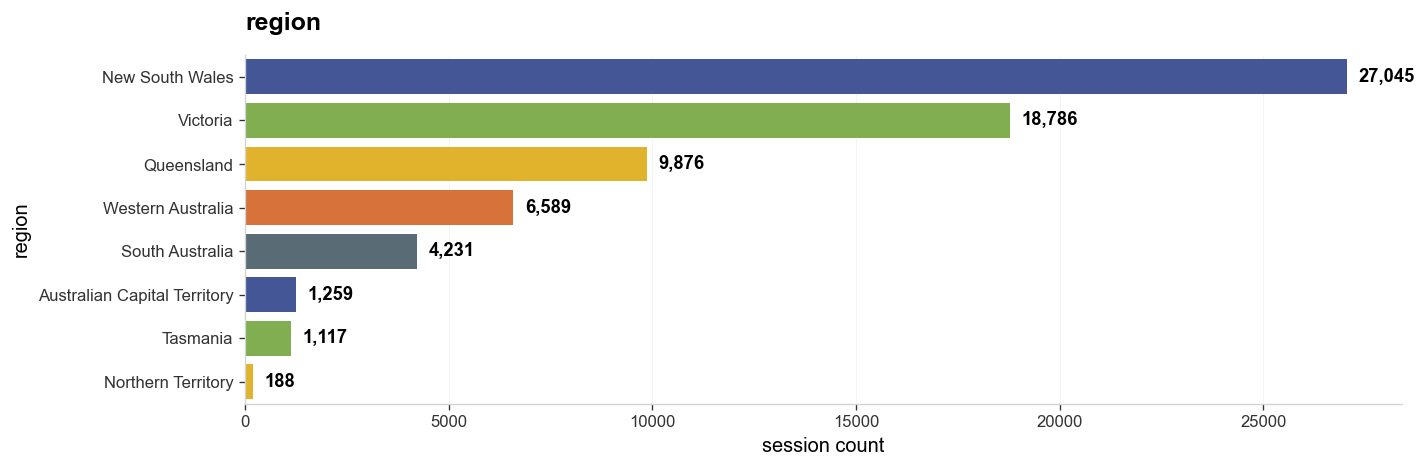

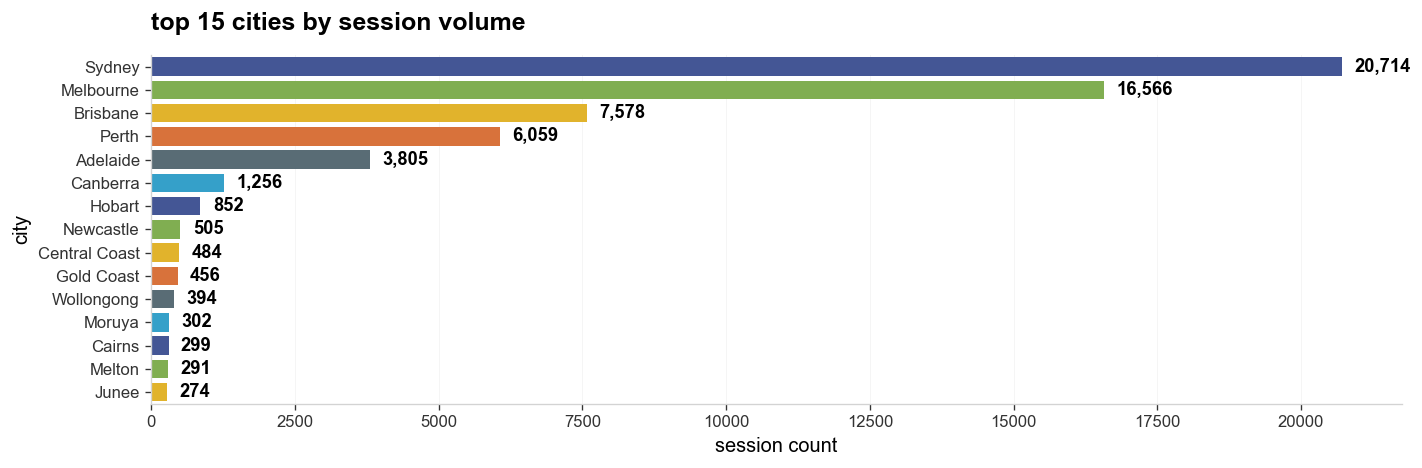

In [242]:
# 1. regional distribution (state level)
plt.figure(figsize=(12, 4))
region_counts = data['region'].value_counts().head(10)

# utilizing u_grey for geographic baseline
ax_r = sns.barplot(x=region_counts.values, y=region_counts.index.astype(str), palette=get_rotating_colors((5)))
ax_r.set_title('region', loc='left', pad=15)
ax_r.set_xlabel("session count")

# absolute count labeling
for p in ax_r.patches:
    ax_r.annotate(f'{int(p.get_width()):,}', 
                     (p.get_width() + (ax_r.get_xlim()[1] * 0.01), p.get_y() + p.get_height()/2),
                     ha='left', va='center', fontsize=11, fontweight='bold')
strip_axes(ax_r)
plt.show()

# 2. top 15 cities (metropolitan level)
plt.figure(figsize=(12, 4))
city_counts = data['city'].value_counts().head(15)

# utilizing u_blue for focal metropolitan centers
ax_c = sns.barplot(x=city_counts.values, y=city_counts.index.astype(str), palette=get_rotating_colors((6)))
ax_c.set_title('top 15 cities by session volume', loc='left', pad=15)
ax_c.set_xlabel("session count")

# absolute count labeling
for p in ax_c.patches:
    ax_c.annotate(f'{int(p.get_width()):,}', 
                     (p.get_width() + (ax_c.get_xlim()[1] * 0.01), p.get_y() + p.get_height()/2),
                     ha='left', va='center', fontsize=11, fontweight='bold')
strip_axes(ax_c)
plt.show()

Traffic is heavily concentrated in New South Wales, followed by Victoria and then Queensland at a significantly lower level, with all other states contributing relatively minor volumes. This concentration is even more pronounced at the city level, where Sydney dominates by a large margin, with Melbourne second and Brisbane third but still notably behind. Beyond the top three cities, session volumes decline sharply, with the remaining cities contributing only marginal traffic.

#### 2.3.f. Time

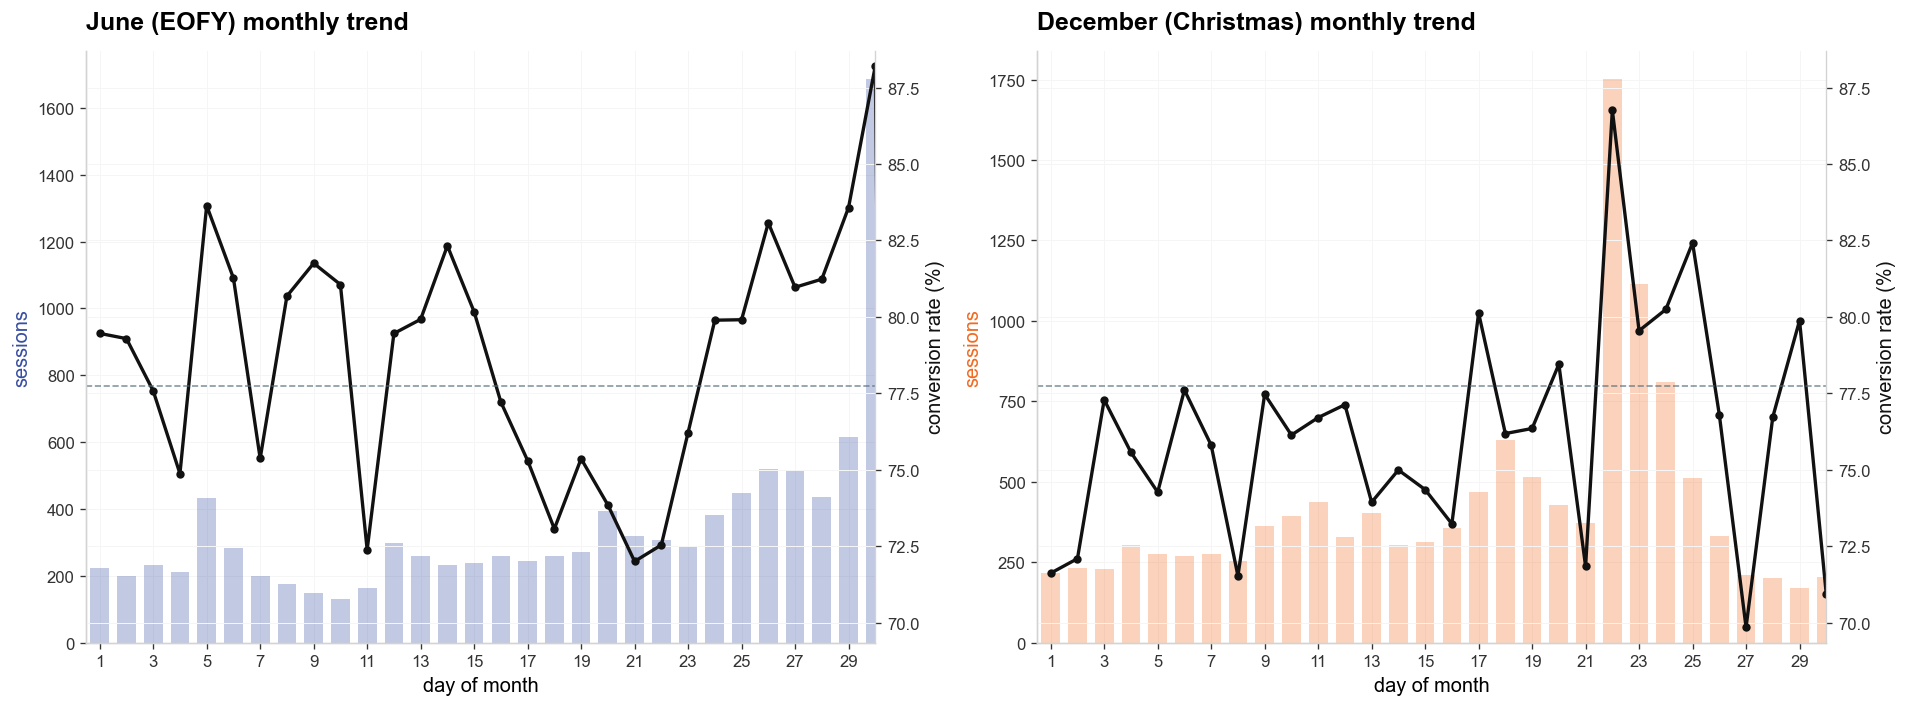

In [245]:
# prepare features
data['session_date'] = pd.to_datetime(data['session_date'])
data['session_day'] = data['session_date'].dt.day

TCOL = 'target_purchased'

# ── compute global CR range (across both months) ─────────────────────────────
cr_values = []

for month_num in [6, 12]:
    subset = data.loc[data['session_month'] == month_num]

    daily = subset.groupby('session_day')[TCOL].mean()
    cr_values.extend(daily.values)

cr_min = min(cr_values) * 100
cr_max = max(cr_values) * 100

# padding for aesthetics
padding = 0.5
cr_min -= padding
cr_max += padding

# ── plotting ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, month_num, month_name, colour in [
    (axes[0], 6,  'June (EOFY)', u_blue),
    (axes[1], 12, 'December (Christmas)', u_orange)
]:
    subset = data.loc[data['session_month'] == month_num].copy()

    daily = (
        subset.groupby('session_day')
        .agg(
            sessions=(TCOL, 'count'),
            cr=(TCOL, 'mean')
        )
        .reindex(range(1, 32), fill_value=0)
        .reset_index()
        .rename(columns={'index': 'session_day'})
    )

    daily['cr'] = daily['cr'] * 100

    ax2 = ax.twinx()

    ax.bar(
        daily['session_day'],
        daily['sessions'],
        color=colour,
        alpha=0.30,
        width=0.7
    )

    ax2.plot(
        daily['session_day'],
        daily['cr'],
        marker='o',
        color=u_dark,
        linewidth=2,
        markersize=4
    )

    ax2.axhline(
        OVERALL_CR * 100,
        color=u_grey,
        linestyle='--',
        linewidth=1,
        alpha=0.7
    )

    # ── FIX: aligned CR axis ──
    ax2.set_ylim(cr_min, cr_max)

    ax.set_xticks(range(1, 32, 2))
    ax.set_xlim(0.5, 30)
    ax.set_xlabel('day of month')
    ax.set_ylabel('sessions', color=colour)
    ax2.set_ylabel('conversion rate (%)', color=u_dark)
    ax.set_title(f'{month_name} monthly trend', loc='left')

    strip_axes(ax)
    ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

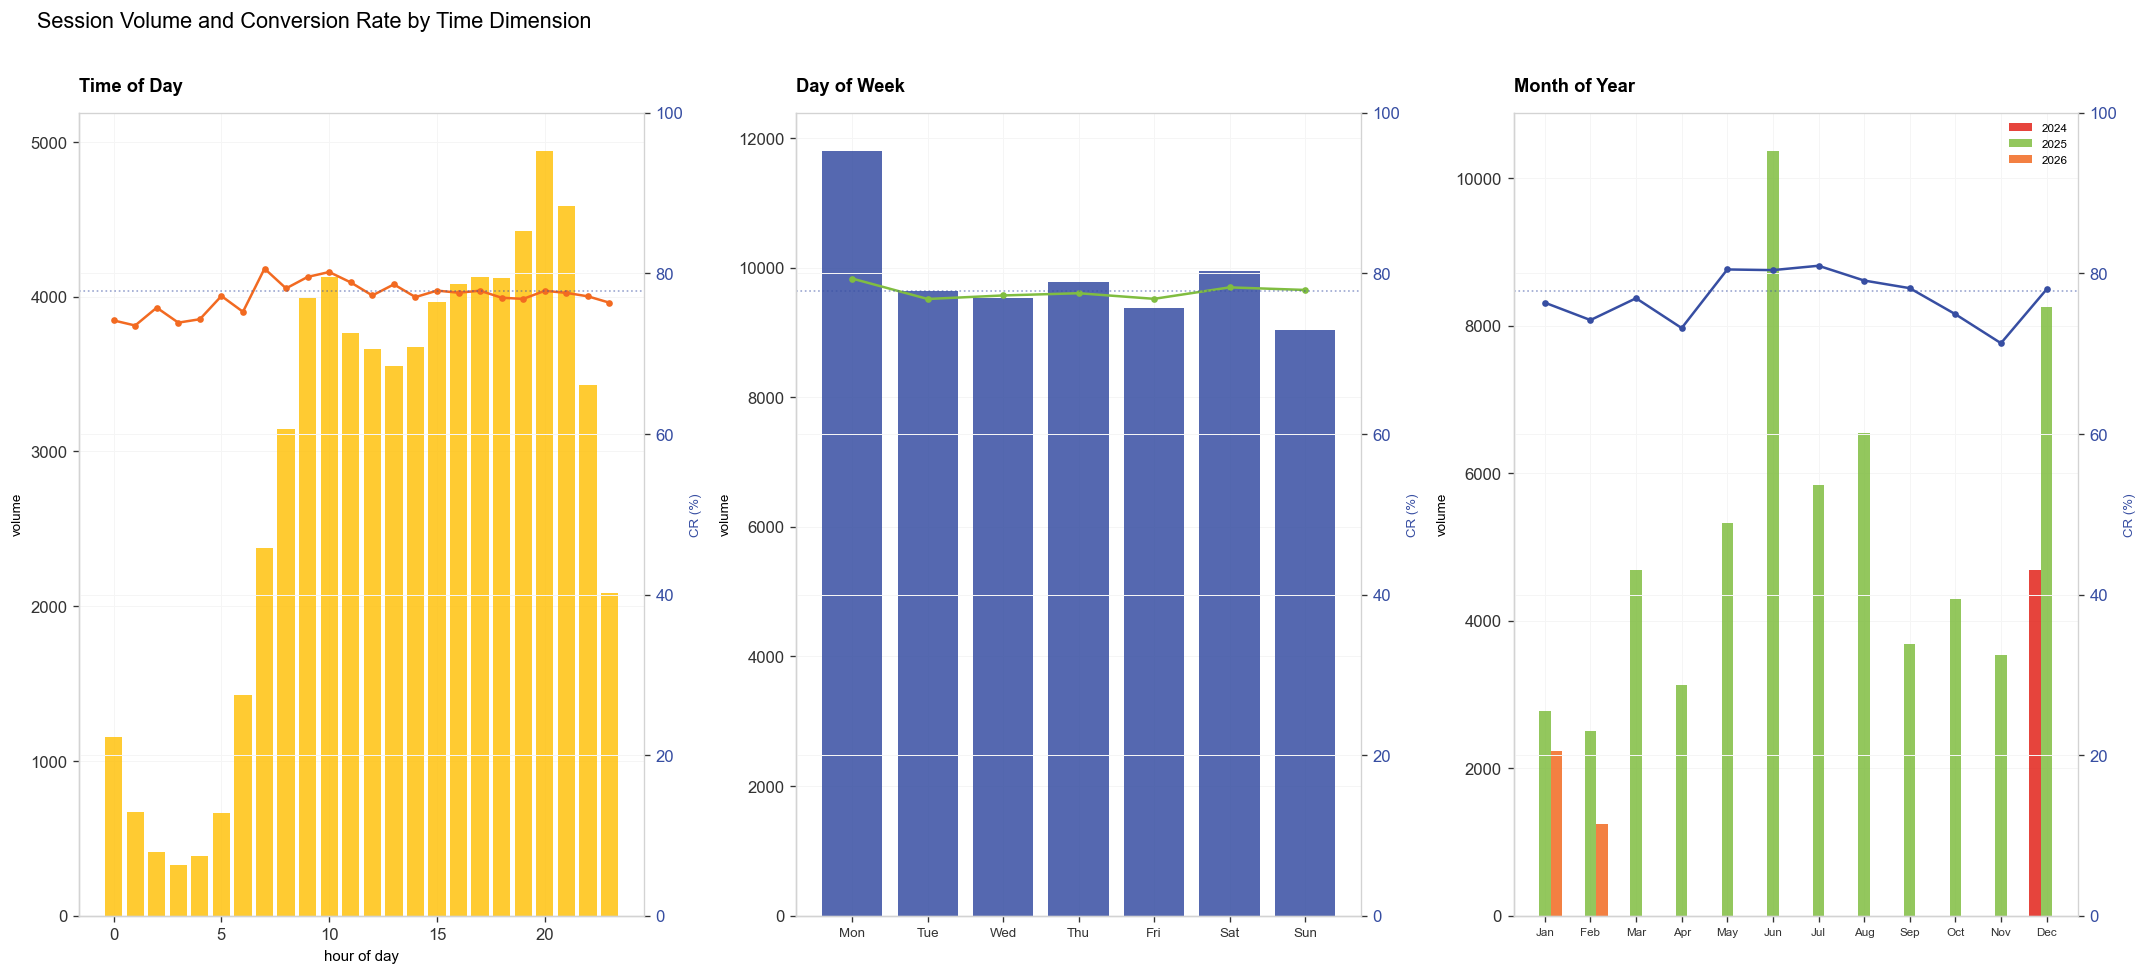

In [246]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# ── time of day ───────────────────────────────────────────────
hourly = data.groupby('session_hour').agg(
    volume=(TCOL, 'count'),
    cr=(TCOL, 'mean')
).reset_index()

ax1 = axes[0]
ax1b = ax1.twinx()
ax1.bar(hourly['session_hour'], hourly['volume'], color=u_yellow, alpha=0.85)
ax1b.plot(hourly['session_hour'], hourly['cr'] * 100,
          color=u_orange, marker='o', markersize=3, linewidth=1.5)
ax1b.axhline(OVERALL_CR * 100, color=u_blue, linestyle=':', linewidth=1, alpha=0.5)
ax1b.set_ylim(0, 100)
ax1.set_xlabel('hour of day', fontsize=9)
ax1.set_title('Time of Day', loc='left', fontsize=11)
strip_axes(ax1)

# ── day of week ───────────────────────────────────────────────
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = data.groupby('session_day_name').agg(
    volume=(TCOL, 'count'),
    cr=(TCOL, 'mean')
).reindex(dow_order).reset_index()

ax2 = axes[1]
ax2b = ax2.twinx()
ax2.bar(range(7), daily['volume'], color=u_blue, alpha=0.85)
ax2b.plot(range(7), daily['cr'] * 100,
          color=u_green, marker='o', markersize=3, linewidth=1.5)
ax2b.axhline(OVERALL_CR * 100, color=u_blue, linestyle=':', linewidth=1, alpha=0.5)
ax2b.set_ylim(0, 100)
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=8)
ax2.set_title('Day of Week', loc='left', fontsize=11)
strip_axes(ax2)

# ── month of year ─────────────────────────────────────────────
monthly = data.groupby(['session_year','session_month']).agg(
    volume=(TCOL, 'count'),
    cr=(TCOL, 'mean')
).reset_index()

ax3 = axes[2]
ax3b = ax3.twinx()

year_colours = {2024: u_red, 2025: u_green, 2026: u_orange}
for yr, grp in monthly.groupby('session_year'):
    ax3.bar(grp['session_month'] + (list(monthly['session_year'].unique()).index(yr) * 0.25 - 0.25),
            grp['volume'],
            width=0.25,
            color=year_colours.get(yr, u_grey),
            alpha=0.85,
            label=str(yr))

cr_annual = data.groupby('session_month')[TCOL].mean() * 100
ax3b.plot(range(1, 13), cr_annual,
          color=u_blue, marker='o', markersize=3, linewidth=1.5)
ax3b.axhline(OVERALL_CR * 100, color=u_blue, linestyle=':', linewidth=1, alpha=0.5)
ax3b.set_ylim(0, 100)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=7)
ax3.set_title('Month of Year', loc='left', fontsize=11)
ax3.legend(fontsize=7, frameon=False)
strip_axes(ax3)

# ── shared labels ─────────────────────────────────────────────
for ax in axes:
    ax.set_ylabel('volume', fontsize=8)
for axb in [ax1b, ax2b, ax3b]:
    axb.set_ylabel('CR (%)', fontsize=8, color=u_blue)
    axb.tick_params(axis='y', labelcolor=u_blue)

fig.suptitle('Session Volume and Conversion Rate by Time Dimension',
             fontsize=13, x=0.02, ha='left', y=1.01)
plt.tight_layout()
plt.show()

## 3. Bivariate Analysis

### 3.1. Ask Amounts

In [249]:
for i, col in enumerate(['once_ask1', 'once_ask2', 'once_ask3'], start=1):
    plot_data = cr_by_ask_bracket(col, q=6)

    fig, ax = plt.subplots(figsize=(5.8, 3.2))
    
    bars = ax.bar(
        range(len(plot_data)),
        plot_data['cr'],
        color=[u_blue, u_orange, u_yellow, u_green, u_red, u_cyan][:len(plot_data)],
        width=0.6,
        edgecolor='white'
    )

    ax.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
               linewidth=1.2, label=f'Overall avg ({OVERALL_CR*100:.1f}%)')

    # set y-axis to zoom in on meaningful range
    y_min = max(0, plot_data['cr'].min() - 8)
    y_max = plot_data['cr'].max() + 5
    ax.set_ylim(y_min, y_max)

    ax.set_xticks(range(len(plot_data)))
    ax.set_xticklabels(plot_data['_br'].tolist(), rotation=25,
                       ha='right', fontsize=8)
    ax.set_title(f'conversion rate by {col} bracket',
                 loc='left', fontsize=10)
    ax.set_ylabel('CR (%)', fontsize=9)
    ax.legend(fontsize=7, frameon=False)

    for j, (bar, val) in enumerate(zip(bars, plot_data['cr'])):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.1f}%',
                ha='center', va='bottom',
                fontsize=7.5, color=u_dark)

    strip_axes(ax)
    plt.tight_layout()
    plt.show()

NameError: name 'cr_by_ask_bracket' is not defined

In [ ]:
data['ratio_12'] = (data['once_ask2'] / data['once_ask1']).replace([np.inf, -np.inf], np.nan)
data['ratio_23'] = (data['once_ask3'] / data['once_ask2']).replace([np.inf, -np.inf], np.nan)

def plot_cr_ratio(rcol, top=12):
    tmp      = data.dropna(subset=[rcol, TCOL]).copy()
    top_vals = tmp[rcol].value_counts().head(top).index
    res = (tmp[tmp[rcol].isin(top_vals)]
           .groupby(rcol)[TCOL].mean()
           .mul(100).reset_index(name='cr')
           .sort_values(rcol))

    plt.figure(figsize=(14, 4))
    ax = sns.lineplot(data=res, x=rcol, y='cr', marker='o',
                      lw=3, color=u_blue)
    ax.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
               linewidth=1.2, label=f'Overall avg ({OVERALL_CR*100:.1f}%)')
    ax.set_title(f'conversion rate by ask multiplier ({rcol})',
                 loc='left', fontsize=14, pad=15)
    ax.set_ylabel('CR (%)')
    ax.set_xlabel(f'multiplier ({rcol})')
    ax.legend(frameon=False, fontsize=9)
    strip_axes(ax)
    plt.tight_layout()
    plt.show()

plot_cr_ratio('ratio_12')
plot_cr_ratio('ratio_23')

# ask ladder × landing page heatmap
ladder_data = data.loc[data[['once_ask1','once_ask2','once_ask3']].notna().all(axis=1)].copy()
ladder_data['ask_ladder'] = (
    ladder_data['once_ask1'].round().astype(int).astype(str) + ' | ' +
    ladder_data['once_ask2'].round().astype(int).astype(str) + ' | ' +
    ladder_data['once_ask3'].round().astype(int).astype(str)
)

top_pages   = ladder_data['land_page_path'].value_counts().head(5).index
top_ladders = ladder_data['ask_ladder'].value_counts().head(10).index
hm_df = ladder_data[
    ladder_data['land_page_path'].isin(top_pages) &
    ladder_data['ask_ladder'].isin(top_ladders)
]

pivot_lp = hm_df.pivot_table(
    index='ask_ladder', columns='land_page_path',
    values=TCOL, aggfunc='mean'
).mul(100)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_lp, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('conversion rate by ask ladder and landing page',
          loc='left', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
heat_ladders = ladder_data['ask_ladder'].value_counts().head(10).index
hm = ladder_data[ladder_data['ask_ladder'].isin(heat_ladders)].copy()

top_channels = hm['session_channel'].value_counts().head(7).index
top_devices  = hm['device_category'].value_counts().head(4).index

# ask ladder × channel
hm_ch    = hm[hm['session_channel'].isin(top_channels)].copy()
pivot_ch = hm_ch.pivot_table(
    index='ask_ladder', columns='session_channel',
    values=TCOL, aggfunc='mean'
).mul(100)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_ch, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('ask ladder variation by marketing channel',
          loc='left', pad=15, fontsize=14)
plt.tight_layout()
plt.show()

# ask ladder × device
hm_dev    = hm[hm['device_category'].isin(top_devices)].copy()
pivot_dev = hm_dev.pivot_table(
    index='ask_ladder', columns='device_category',
    values=TCOL, aggfunc='mean'
).mul(100)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_dev, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('ask ladder variation by device category',
          loc='left', pad=15, fontsize=14)
plt.tight_layout()
plt.show()

### 3.2. Online Acquisitions

#### 3.2.a. Channel

In [ ]:
if 'session_channel' not in data.columns:
    raise KeyError("session_channel column missing from data")

source_col   = 'session_source'   if 'session_source'   in data.columns else None
medium_col   = 'session_medium'   if 'session_medium'   in data.columns else None

internal_keywords = ['internal', 'bot_or_scanner']
unknown_keywords  = ['unknown']

def any_keyword_mask(s, keywords):
    s    = s.astype(str).str.lower()
    mask = pd.Series(False, index=s.index)
    for k in keywords:
        mask = mask | s.str.contains(k, na=False)
    return mask

concat_cols   = [c for c in [source_col, medium_col] if c] + ['session_channel']
concat_series = data[concat_cols].astype(str).agg(' | '.join, axis=1)

internal_bot_mask = any_keyword_mask(concat_series, internal_keywords)
unknown_mask      = any_keyword_mask(concat_series, unknown_keywords)

# volume + conversion rate per channel
channel_stats = (data.groupby('session_channel')
                     .agg(n_sessions=(TCOL, 'size'), cr=(TCOL, 'mean'))
                     .reset_index())
channel_stats['cr'] = channel_stats['cr'] * 100

top_n = 10
cs    = channel_stats.sort_values('n_sessions', ascending=False).reset_index(drop=True)
if len(cs) > top_n:
    top      = cs.head(top_n).copy()
    other_n  = cs['n_sessions'].iloc[top_n:].sum()
    other_cr = (cs['cr'].iloc[top_n:] * cs['n_sessions'].iloc[top_n:]).sum() / other_n
    top = pd.concat([
        top,
        pd.DataFrame({'session_channel': ['Other (low vol)'],
                       'n_sessions': [other_n], 'cr': [other_cr]})
    ], ignore_index=True)
else:
    top = cs

fig, ax1 = plt.subplots(figsize=(12, 4.8))
ax2 = ax1.twinx()

sns.barplot(data=top, x='session_channel', y='n_sessions',
            ax=ax1, color=u_grey, alpha=0.25)
ax1.set_ylabel('sessions', color=u_grey)
ax1.tick_params(axis='x', rotation=25, labelsize=8)

sns.lineplot(data=top.sort_values('n_sessions', ascending=False),
             x='session_channel', y='cr',
             ax=ax2, marker='o', color=u_blue, linewidth=2.5)
ax2.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
            linewidth=1, alpha=0.8,
            label=f'Overall avg ({OVERALL_CR*100:.1f}%)')
ax2.set_ylabel('conversion rate (%)', color=u_blue)
ax2.legend(fontsize=8, frameon=False)

for _, r in top.iterrows():
    ax2.annotate(f'{r["cr"]:.1f}%', (r.name, r['cr']),
                 textcoords='offset points', xytext=(0, 6),
                 ha='center', fontsize=8, color=u_dark)

ax1.set_xlabel('')
strip_axes(ax1)
plt.tight_layout()
plt.show()

# paid search vs paid social vs email vs SMS
def classify_paid_group(s):
    s = s.lower()
    if 'email' in s:                                           return 'email'
    if any(k in s for k in ['sms', 'text']):                  return 'sms'
    if any(k in s for k in ['paid_search', 'cpc', 'google']): return 'paid search'
    if any(k in s for k in ['paid_social', 'facebook',
                              'instagram', 'linkedin']):       return 'paid social'
    return 'other'

paid_data              = data.loc[~internal_bot_mask].copy()
paid_data['paid_group'] = concat_series.loc[paid_data.index].apply(classify_paid_group)

grp  = (paid_data.groupby('paid_group')
                 .agg(n_sessions=(TCOL, 'size'), cr=(TCOL, 'mean'))
                 .reset_index())
grp['cr'] = grp['cr'] * 100

wanted = ['paid search', 'paid social', 'email', 'sms']
grp2   = grp[grp['paid_group'].isin(wanted)].sort_values('cr', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.2))
sns.barplot(data=grp2, x='paid_group', y='cr',
            palette=get_rotating_colors(len(grp2), seed=123), ax=ax)
ax.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
           linewidth=1.2, label=f'Overall avg ({OVERALL_CR*100:.1f}%)')
ax.set_title('paid search vs paid social vs email vs SMS conversion',
             loc='left', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('CR (%)')
ax.tick_params(axis='x', rotation=15, labelsize=9)
ax.legend(fontsize=8, frameon=False)
strip_axes(ax)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9, color=u_dark,
                xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

for i, (_, row) in enumerate(channel_bubble.iterrows()):
    ax.scatter(
        row['sessions'], row['cr'],
        s=row['donors'] / channel_bubble['donors'].max() * 2000 + 80,
        color=cat_colours[i % len(cat_colours)],
        alpha=0.85,
        edgecolors='white',
        linewidths=1.2
    )
    ax.annotate(row['session_channel'],
                (row['sessions'], row['cr']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color=u_dark)

ax.set_xscale('log')

# quadrant lines
ax.axvline(overall_vol, color=u_grey, linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(overall_cr,  color=u_grey, linestyle='--', linewidth=1, alpha=0.6)

# quadrant labels — use data-space values directly, not xlim
x_left = channel_bubble['sessions'].min() * 1.05
ax.text(x_left, overall_cr * 1.02,
        'low vol\nhigh CR', fontsize=8, color=u_green, fontstyle='italic')
ax.text(overall_vol * 1.05, overall_cr * 1.02,
        'high vol\nhigh CR', fontsize=8, color=u_blue, fontstyle='italic')
ax.text(overall_vol * 1.05, overall_cr * 0.92,
        'high vol\nlow CR', fontsize=8, color=u_red, fontstyle='italic')

ax.set_xlabel('total sessions (log scale)', fontsize=11)
ax.set_ylabel('conversion rate (%)', fontsize=11)
ax.set_title('channel efficiency vs volume\n(bubble size = total donors)',
             loc='left', fontsize=13)
strip_axes(ax)
plt.tight_layout()
plt.show()

#### 3.2.b. Source & Medium

In [ ]:
# ── Plot A: Top Converting Sources ────────────────────────────
s_stats = (data.groupby('session_source')
               .agg(n=(TCOL, 'size'), cr=(TCOL, 'mean'))
               .reset_index())
top_s = (s_stats[s_stats['n'] > 500]
             .sort_values('cr', ascending=False)
             .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    top_s['session_source'][::-1],
    top_s['cr'][::-1] * 100,
    color=get_rotating_colors(len(top_s)),
    edgecolor='white', height=0.6
)
ax.axvline(OVERALL_CR * 100, color=u_grey, linestyle='--',
           linewidth=1.2, label=f'Overall avg ({OVERALL_CR*100:.1f}%)')
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.2f}%',
            va='center', ha='left', fontsize=8, color=u_dark)
ax.set_xlabel('conversion rate (%)', fontsize=9)
ax.set_title('top converting sources (n > 500)', loc='left', fontsize=11)
ax.legend(fontsize=8, frameon=False)
strip_axes(ax)
plt.tight_layout()
plt.show()

# ── Plot B: Organic vs Paid Gap ────────────────────────────────
data['traffic_type'] = data['session_medium'].apply(
    lambda x: 'Paid' if any(
        k in str(x).lower()
        for k in ['cpc', 'ppc', 'paid', 'social-paid']
    ) else 'Organic/Other'
)
type_cr = data.groupby('traffic_type')[TCOL].mean() * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    type_cr.index,
    type_cr.values,
    color=[u_blue, u_cyan],
    edgecolor='white', width=0.5
)
ax.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
           linewidth=1.2, label=f'Overall avg ({OVERALL_CR*100:.1f}%)')
y_min = max(0, type_cr.min() - 8)
ax.set_ylim(y_min, type_cr.max() + 5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%',
            ha='center', va='bottom', fontsize=9, color=u_dark)
ax.set_ylabel('conversion rate (%)', fontsize=9)
ax.set_title('organic vs paid conversion gap', loc='left', fontsize=11)
ax.legend(fontsize=8, frameon=False)
strip_axes(ax)
plt.tight_layout()
plt.show()

In [ ]:
# ── bivariate: behavioral profile (switched to dual-axis layout) ─────────────

target_m = ['referral', '(none)', 'direct', 'organic'] 
rd_data = data[data['session_medium'].isin(target_m)]

if len(rd_data) > 0:
    # Aggregate data
    rd_stats = rd_data.groupby('session_medium').agg(
        dur=('session_duration', 'mean'), 
        cr=('target_purchased', 'mean')
    ).reset_index()
    
    # Sort by duration to give the chart a logical flow (longest to shortest)
    rd_stats = rd_stats.sort_values('dur', ascending=False).reset_index(drop=True)
    rd_stats['cr'] = rd_stats['cr'] * 100

    # Setup dual-axis figure
    fig, ax1 = plt.subplots(figsize=(10, 3))
    ax2 = ax1.twinx()

    # Base Layer: Session Duration (Bars)
    sns.barplot(data=rd_stats, x='session_medium', y='dur', ax=ax1, color=u_grey, alpha=0.2)
    ax1.set_ylabel('avg session duration (seconds)', color=u_grey)
    
    # Top Layer: Conversion Rate (Line + Markers)
    sns.lineplot(data=rd_stats, x='session_medium', y='cr', ax=ax2, 
                 marker='o', color=u_blue, linewidth=3, markersize=12)
    ax2.set_ylabel('conversion rate (%)', color=u_blue, fontweight='bold')

    # Force dynamic limits to give the annotations breathing room
    ax1.set_ylim(0, rd_stats['dur'].max() * 1.3)
    ax2.set_ylim(0, rd_stats['cr'].max() * 1.4)

    # Single-line annotation logic (Duration inside the bar, CR above the dot)
    for i, row in rd_stats.iterrows():
        ax1.annotate(f'{row["dur"]:.0f}s', (i, row['dur']), xytext=(0, -18), textcoords='offset points', ha='center', fontsize=11, color=u_dark)
        ax2.annotate(f'{row["cr"]:.2f}%', (i, row['cr']), xytext=(0, 15), textcoords='offset points', ha='center', fontsize=12, fontweight='bold', color=u_blue)

    ax1.set_title('behavioral profile: duration vs. conversion rate', loc='left', pad=15)
    ax1.set_xlabel('')
    strip_axes(ax1)
    
    plt.tight_layout()
    plt.show()
else:
    print("Debug: No matching mediums found.")

#### 3.2.c. Landing Page

In [ ]:
# 1. ROW 1: Strategic Framing (Family & Appeal)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

fam_cr = data.groupby('land_family')['target_purchased'].mean().sort_values(ascending=False) * 100
sns.barplot(x=fam_cr.values, y=fam_cr.index, palette=get_rotating_colors(len(fam_cr)), ax=ax1)
ax1.set_title('conversion by land_family', loc='left', fontsize=14)
for p in ax1.patches: ax1.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

app_cr = data.groupby('land_appeal')['target_purchased'].mean().sort_values(ascending=False) * 100
sns.barplot(x=app_cr.values, y=app_cr.index, palette=[u_red, u_grey], ax=ax2)
ax2.set_title('conversion by land_appeal', loc='left', fontsize=14)
for p in ax2.patches: ax2.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

for ax in [ax1, ax2]: strip_axes(ax); ax.set_xlabel('conversion rate (%)', fontsize=12); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [ ]:
# 2. ROW 2: Transactional Framing (Segment & Frequency)
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))

seg_cr = data.groupby('land_segment')['target_purchased'].mean().sort_values(ascending=False) * 100
sns.barplot(x=seg_cr.values, y=seg_cr.index, palette=get_rotating_colors(len(seg_cr)), ax=ax3)
ax3.set_title('conversion by land_segment', loc='left', fontsize=14)
for p in ax3.patches: ax3.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

freq_cr = data.groupby('land_frequency_intent')['target_purchased'].mean().sort_values(ascending=False) * 100
sns.barplot(x=freq_cr.values, y=freq_cr.index, palette=[u_blue, u_cyan, u_grey][:len(freq_cr)], ax=ax4)
ax4.set_title('conversion by land_frequency_intent', loc='left', fontsize=14)
for p in ax4.patches: ax4.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

for ax in [ax3, ax4]: strip_axes(ax); ax.set_xlabel('conversion rate (%)', fontsize=12); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [ ]:
# 3. ROW 3: Contextual Framing (Seasonal & Campaign)
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(18, 6))

seas_cr = data.groupby('land_seasonal')['target_purchased'].mean().sort_values(ascending=False) * 100
sns.barplot(x=seas_cr.values, y=seas_cr.index, palette=get_rotating_colors(len(seas_cr)), ax=ax5)
ax5.set_title('conversion by land_seasonal', loc='left', fontsize=14)
for p in ax5.patches: ax5.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

# Aggregating campaigns and filtering out low-volume tests to keep the chart readable
camp_stats = data.groupby('land_campaign').agg(n=('target_purchased', 'size'), cr=('target_purchased', 'mean')).reset_index()
top_camp = camp_stats[camp_stats['n'] >= 200].sort_values('cr', ascending=False).head(10)
sns.barplot(x=top_camp['cr'] * 100, y=top_camp['land_campaign'], palette=get_rotating_colors(len(top_camp)), ax=ax6)
ax6.set_title('top 10 converting land_campaigns (min n=200)', loc='left', fontsize=14)
for p in ax6.patches: ax6.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

for ax in [ax5, ax6]: strip_axes(ax); ax.set_xlabel('conversion rate (%)', fontsize=12); ax.set_ylabel('')
plt.tight_layout(); plt.show()

### 3.3. Visitor Journey 

In [ ]:
# ── bivariate: customer journey & donor behavior (Part 1) ───────────────────

# 1. ROW 1: Session Depth & Pathway Deviation (The "Leaky Funnel" checks)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot A: Single vs Multi-page (Assuming 0=Multi, 1=Single based on previous flags)
sp_cr = data.groupby('last_single_page')['target_purchased'].mean() * 100
sp_cr.index = ['Multi-Page', 'Single-Page'] 
sns.barplot(x=sp_cr.index, y=sp_cr.values, palette=[u_blue, u_grey], ax=ax1)
ax1.set_title('conversion impact: single vs multi-page', loc='left', fontsize=14)
for p in ax1.patches: ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=12, fontweight='bold', color=u_dark)

# Plot B: Left Donate Section (Did they wander off?)
ld_cr = data.groupby('last_left_donate')['target_purchased'].mean() * 100
ld_cr.index = ['Stayed in Flow', 'Left Donate Section']
sns.barplot(x=ld_cr.index, y=ld_cr.values, palette=[u_cyan, u_red], ax=ax2)
ax2.set_title('conversion impact: left donate section', loc='left', fontsize=14)
for p in ax2.patches: ax2.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=12, fontweight='bold', color=u_dark)

for ax in [ax1, ax2]: strip_axes(ax); ax.set_ylabel('conversion rate (%)', fontsize=12); ax.set_xlabel('')
plt.tight_layout(); plt.show()

In [ ]:
# ── bivariate: customer journey & donor behavior (Part 2) ───────────────────

# Feature Engineering: Binning session duration to find the "Golden Window"
bins = [0, 30, 60, 180, 300, 600, np.inf]
labels = ['<30s', '30s-1m', '1m-3m', '3m-5m', '5m-10m', '10m+']
data['duration_bucket'] = pd.cut(data['session_duration'], bins=bins, labels=labels)

# 2. ROW 2: Upsell Friction & Time-to-Convert
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))

# Plot C: Monthly Upsell Flag
up_cr = data.groupby('last_upsell_flag')['target_purchased'].mean() * 100
up_cr.index = ['No Upsell Triggered', 'Saw Monthly Upsell']
sns.barplot(x=up_cr.index, y=up_cr.values, palette=[u_grey, u_orange], ax=ax3)
ax3.set_title('conversion impact: monthly upsell trigger', loc='left', fontsize=14)
for p in ax3.patches: ax3.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=12, fontweight='bold', color=u_dark)

# Plot D: Session Duration Buckets
dur_cr = data.groupby('duration_bucket')['target_purchased'].mean() * 100
sns.lineplot(x=dur_cr.index.astype(str), y=dur_cr.values, ax=ax4, marker='o', color=u_blue, lw=3, markersize=10)
ax4.set_title('conversion rate by session duration')
for i, val in enumerate(dur_cr.values): ax4.annotate(f'{val:.2f}%', (i, val), xytext=(0, 15), textcoords='offset points', ha='center', fontsize=11, fontweight='bold', color=u_dark)

for ax in [ax3, ax4]: strip_axes(ax); ax.set_ylabel('conversion rate (%)', fontsize=12); ax.set_xlabel('')
plt.tight_layout(); plt.show()

In [ ]:
# duration decile → conversion rate (non-linear check)
data['duration_decile'] = pd.qcut(
    data['session_duration'], q=10, labels=False, duplicates='drop'
)

decile_stats = (
    data.groupby('duration_decile')
        .agg(sessions=(TCOL, 'count'),
             cr=(TCOL, 'mean'))
        .reset_index()
)
decile_stats['cr'] = decile_stats['cr'] * 100

# decile boundary labels for x-axis
decile_bounds = (
    data.groupby('duration_decile')['session_duration']
        .max().reset_index()
)
decile_bounds.columns = ['duration_decile', 'upper_bound']
decile_stats = decile_stats.merge(decile_bounds, on='duration_decile')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax2.bar(decile_stats['duration_decile'], decile_stats['sessions'],
        color=u_grey, alpha=0.2, width=0.7)
ax1.plot(decile_stats['duration_decile'], decile_stats['cr'],
         marker='o', color=u_blue, linewidth=2.5, markersize=7)
ax1.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
            linewidth=1.2, label=f'overall avg ({OVERALL_CR*100:.1f}%)')

for _, row in decile_stats.iterrows():
    ax1.annotate(f'{row["cr"]:.1f}%',
                 (row['duration_decile'], row['cr']),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8, color=u_dark)

ax1.set_xticks(decile_stats['duration_decile'])
ax1.set_xticklabels(
    [f'D{int(d)+1}\n(≤{int(b)}s)' for d, b in
     zip(decile_stats['duration_decile'], decile_stats['upper_bound'])],
    fontsize=8
)
ax1.set_ylabel('conversion rate (%)', color=u_blue)
ax2.set_ylabel('sessions', color=u_grey)
ax1.set_title('conversion rate by session duration decile\n'
              '(non-linear check — D1 = shortest sessions)',
              loc='left')
ax1.legend(fontsize=8, frameon=False)
strip_axes(ax1)
plt.tight_layout()
plt.show()

In [ ]:
# ── bivariate: customer journey & donor behavior (Part 3) ───────────────────

# 3. ROW 3: Terminal UX (Where do they end up?)
plt.figure(figsize=(12, 6))

# Filter for statistical relevance (min 100 sessions)
lp_stats = data.groupby('last_page_section').agg(n=('target_purchased', 'size'), cr=('target_purchased', 'mean')).reset_index()
top_lp = lp_stats[lp_stats['n'] >= 100].sort_values('cr', ascending=False).head(8)

ax5 = sns.barplot(x=top_lp['cr'] * 100, y=top_lp['last_page_section'], palette=get_rotating_colors(len(top_lp)))
ax5.set_title('conversion by last page section (min n=100)', loc='left', fontsize=14)
for i, p in enumerate(ax5.patches): ax5.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

strip_axes(ax5); ax5.set_xlabel('conversion rate (%)', fontsize=12); ax5.set_ylabel('')
plt.tight_layout(); plt.show()

### 3.4. Device and Technical Contexts

In [ ]:
# ── bivariate: device and technical context (Part 1) ────────────────────────

# 1. ROW 1: Hardware Diagnostics (Device Category & OS)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot A: Device Category
dev_cr = data.groupby('device_category')['target_purchased'].mean().sort_values(ascending=False) * 100
sns.barplot(x=dev_cr.values, y=dev_cr.index, palette=get_rotating_colors(len(dev_cr)), ax=ax1)
ax1.set_title('conversion by device category', loc='left', fontsize=14)
for p in ax1.patches: ax1.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

# Plot B: Operating System (Filtering for Top 4 to avoid fragmentation)
os_stats = data.groupby('os').agg(n=('target_purchased', 'size'), cr=('target_purchased', 'mean')).reset_index()
top_os = os_stats.sort_values('n', ascending=False).head(4).sort_values('cr', ascending=False)
sns.barplot(x=top_os['cr'] * 100, y=top_os['os'], palette=get_rotating_colors(len(top_os)), ax=ax2)
ax2.set_title('conversion by operating system (top 4 volume)', loc='left', fontsize=14)
for p in ax2.patches: ax2.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

for ax in [ax1, ax2]: strip_axes(ax); ax.set_xlabel('conversion rate (%)', fontsize=12); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [ ]:
# statistical tests for device, OS, browser
print("=== statistical tests: device and technical context ===\n")

for col, label in [
    ('device_category', 'device category'),
    ('os',              'operating system'),
    ('browser',         'browser'),
]:
    support    = data[col].value_counts()
    valid_cats = support[support >= 50].index
    df_sub     = data[data[col].isin(valid_cats)]
    get_stats(df_sub, col, TCOL)

In [ ]:
# 2. ROW 2: Browser Efficiency & Hardware Engagement
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))

# Plot C: Browser Performance (Top 5)
browser_stats = data.groupby('browser').agg(n=('target_purchased', 'size'), cr=('target_purchased', 'mean')).reset_index()
top_browser = browser_stats.sort_values('n', ascending=False).head(5).sort_values('cr', ascending=False)
sns.barplot(x=top_browser['cr'] * 100, y=top_browser['browser'], palette=get_rotating_colors(len(top_browser)), ax=ax3)
ax3.set_title('conversion by browser (top 5 volume)', loc='left')
for p in ax3.patches: ax3.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold', color=u_dark)

# Plot D: Session Duration by Device Category (Mobile vs Desktop)
dur_dev = data[data['device_category'].isin(['mobile', 'desktop'])].groupby('device_category')['session_duration'].mean()
sns.barplot(x=dur_dev.index, y=dur_dev.values, palette=[u_blue, u_grey], ax=ax4)
ax4.set_title('avg session duration: mobile vs desktop', loc='left')
for p in ax4.patches: ax4.annotate(f'{p.get_height():.0f}s', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, -15), textcoords='offset points', fontsize=12, fontweight='bold', color='white')

for ax in [ax3, ax4]: strip_axes(ax)
ax3.set_xlabel('conversion rate (%)', fontsize=12); ax3.set_ylabel('')
ax4.set_ylabel('avg duration (seconds)', fontsize=12); ax4.set_xlabel('')
plt.tight_layout(); plt.show()

In [ ]:
# Cross-tabulating Device with Channel to find where Mobile might win
device_match = data.pivot_table(index='session_channel', columns='device_category', 
                                values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 6))
sns.heatmap(device_match, annot=True, fmt='.1f', cmap='RdYlGn', center=data['target_purchased'].mean()*100)
plt.title('Device x Channel Heatmap', loc='left', pad=15)
plt.show()

### 3.5 Temporal Patterns

In [ ]:
# session duration by hour (fixed wording)

min_sessions = 500

hourly = data.groupby('session_hour').agg(
    avg_duration=('session_duration', 'mean'),
    med_duration=('session_duration', 'median'),
    std_duration=('session_duration', 'std'),
    n_sessions=('session_duration', 'count')
).reset_index().rename(columns={'session_hour': 'hour'})

hourly['high_volume'] = hourly['n_sessions'] >= min_sessions
hourly['se'] = hourly['std_duration'] / np.sqrt(hourly['n_sessions'])
hourly['ci_low'] = hourly['avg_duration'] - 1.96 * hourly['se']
hourly['ci_high'] = hourly['avg_duration'] + 1.96 * hourly['se']

fig, ax1 = plt.subplots(figsize=(11, 4.5)); ax2 = ax1.twinx()

ax2.bar(hourly['hour'], hourly['n_sessions'], color='#D9D9D9', alpha=0.5, width=0.8)
ax2.set_ylabel('session volume', color=u_grey); ax2.tick_params(axis='y', labelcolor=u_grey)

high = hourly[hourly['high_volume']]
low = hourly[~hourly['high_volume']]

ax1.plot(high['hour'], high['avg_duration'], color=u_blue, linewidth=2.2, marker='o', markersize=4, label='Mean')
ax1.fill_between(high['hour'], high['ci_low'], high['ci_high'], color=u_cyan, alpha=0.15)
ax1.plot(hourly['hour'], hourly['med_duration'], color=u_orange, linestyle='--', linewidth=1.6, label='Median')

ax1.set_title('Session duration by hour', loc='left')
ax1.set_xlabel('hour'); ax1.set_ylabel('duration (s)', color=u_blue)
ax1.tick_params(axis='y', labelcolor=u_blue)
ax1.set_xticks(range(24)); ax1.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax1.legend(frameon=False, fontsize=9, loc='upper left')

strip_axes(ax1); plt.tight_layout(); plt.show()

In [ ]:
# Ordering for days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot A: Conversion by Hour (Dual Axis with Volume)
hour_stats = data.groupby('session_hour').agg(n=('target_purchased', 'size'), cr=('target_purchased', 'mean')).reset_index()
hour_stats['cr'] = hour_stats['cr'] * 100

# Volume as background bars
sns.barplot(data=hour_stats, x='session_hour', y='n', ax=ax1, color=u_grey, alpha=0.25)
ax1.set_ylabel('session volume', color=u_grey, fontsize=13)
ax1_twin = ax1.twinx() # Twin axis for conversion rate
sns.lineplot(data=hour_stats, x='session_hour', y='cr', ax=ax1_twin, marker='o', color=u_blue, lw=3, markersize=8)
ax1_twin.set_ylabel('conversion rate (%)', color=u_blue, fontsize=13, fontweight='bold')
ax1.set_title('conversion by hour of day (with volume)', loc='left', fontsize=15, pad=15)

# Plot B: Conversion by Day of Week
day_cr = data.groupby('session_day_name')['target_purchased'].mean().reindex(day_order).dropna() * 100
sns.barplot(x=day_cr.index, y=day_cr.values, palette=get_rotating_colors(len(day_cr)), ax=ax2)
ax2.set_title('conversion by day of week', loc='left', fontsize=15, pad=15)
for p in ax2.patches: ax2.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=12, fontweight='bold', color=u_dark)

for ax in [ax1, ax1_twin, ax2]: strip_axes(ax); ax.tick_params(axis='both', labelsize=12)
ax1.set_xlabel('hour of day (0-23)', fontsize=13); ax2.set_xlabel(''); ax2.set_ylabel('conversion rate (%)', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# Ordering for months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 8))

# Plot C: Conversion by Month
month_cr = data.groupby('session_month_name')['target_purchased'].mean().reindex(month_order).dropna() * 100
sns.barplot(x=month_cr.index, y=month_cr.values, palette=get_rotating_colors(len(month_cr)), ax=ax3)
ax3.set_title('conversion by month', loc='left', fontsize=15, pad=15)
# Rotate x-labels for months so they don't overlap
ax3.tick_params(axis='x', rotation=30)
for p in ax3.patches: ax3.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=12, fontweight='bold', color=u_dark)

# Plot D: Weekend vs Weekday
wknd_cr = data.groupby('is_weekend')['target_purchased'].mean() * 100
wknd_cr.index = ['Weekday', 'Weekend']
sns.barplot(x=wknd_cr.index, y=wknd_cr.values, palette=[u_blue, u_grey], ax=ax4)
ax4.set_title('conversion: weekday vs weekend', loc='left', fontsize=15, pad=15)
for p in ax4.patches: ax4.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=13, fontweight='bold', color=u_dark)

for ax in [ax3, ax4]: strip_axes(ax); ax.tick_params(axis='both', labelsize=13)
ax3.set_xlabel(''); ax3.set_ylabel('conversion rate (%)', fontsize=13)
ax4.set_xlabel(''); ax4.set_ylabel('conversion rate (%)', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(18, 8))

# Plot E: Seasonality (Tax vs Holiday vs Baseline)
# Using land_seasonal from the previous section
season_cr = data.groupby('land_seasonal')['target_purchased'].mean().sort_values(ascending=False) * 100
sns.barplot(x=season_cr.index, y=season_cr.values, palette=get_rotating_colors(len(season_cr)), ax=ax5)
ax5.set_title('conversion by seasonal frame', loc='left', fontsize=15, pad=15)
for p in ax5.patches: ax5.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=13, fontweight='bold', color=u_dark)

# Plot F: Year-over-Year Trend (Assuming column is 'session_year')
yoy_stats = data.groupby('session_year').agg(n=('target_purchased', 'size'), cr=('target_purchased', 'mean')).reset_index()
yoy_stats = yoy_stats[yoy_stats['session_year'].isin([2024, 2025])] # Enforce 2024/2025 comparison
yoy_stats['cr'] = yoy_stats['cr'] * 100

sns.barplot(x=yoy_stats['session_year'].astype(str), y=yoy_stats['cr'], palette=[u_grey, u_blue], ax=ax6)
ax6.set_title('year-over-year conversion trend', loc='left', fontsize=15, pad=15)
for p in ax6.patches: ax6.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontsize=13, fontweight='bold', color=u_dark)

for ax in [ax5, ax6]: strip_axes(ax); ax.tick_params(axis='both', labelsize=13)
ax5.set_xlabel(''); ax5.set_ylabel('conversion rate (%)', fontsize=13)
ax6.set_xlabel('session year', fontsize=13); ax6.set_ylabel('conversion rate (%)', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# tax season vs holiday vs baseline using time-based flag
# (distinct from land_seasonal which reflects page framing, not session timing)
data['temporal_season'] = 'baseline'
data.loc[data['is_tax_season'] == 1, 'temporal_season'] = 'tax season (May-Jun)'
data.loc[data['session_month'].isin([11, 12]), 'temporal_season'] = 'holiday (Nov-Dec)'

season_stats = (
    data.groupby('temporal_season')
        .agg(sessions=(TCOL, 'count'), cr=(TCOL, 'mean'))
        .reset_index()
)
season_stats['cr'] = season_stats['cr'] * 100
season_stats = season_stats.sort_values('cr', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

colours = [u_blue, u_orange, u_grey]
bars = ax1.bar(season_stats['temporal_season'], season_stats['sessions'],
               color=colours[:len(season_stats)], alpha=0.25, width=0.5)
ax2.plot(season_stats['temporal_season'], season_stats['cr'],
         marker='o', color=u_dark, linewidth=2.5, markersize=10)
ax2.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
            linewidth=1.2, label=f'overall avg ({OVERALL_CR*100:.1f}%)')

for i, (_, row) in enumerate(season_stats.iterrows()):
    ax2.annotate(f'{row["cr"]:.2f}%', (i, row["cr"]),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=11, fontweight='bold', color=u_dark)
    ax1.annotate(f'n={row["sessions"]:,}', (i, row["sessions"] * 0.5),
                 ha='center', fontsize=9, color='white', fontweight='bold')

ax1.set_ylabel('sessions', color=u_grey)
ax2.set_ylabel('conversion rate (%)', color=u_dark)
ax1.set_title('temporal seasonality: tax season vs holiday vs baseline',
              loc='left')
ax2.legend(fontsize=9, frameon=False)
strip_axes(ax1)
plt.tight_layout()
plt.show()

get_stats(data, 'temporal_season', TCOL)

### 3.6. Geographic and Geodemographic Signals

In [ ]:
# 1. Coverage Check & Caveat Printing
pc_coverage = data['postcode'].notna().mean() * 100
print(f"DIAGNOSTIC: Postcode data is present for {pc_coverage:.1f}% of sessions.")
print("CAVEAT: Postcode (and therefore Mosaic data) is heavily skewed toward DONORS.")
print("As a result, all Mosaic analysis below is DESCRIPTIVE of the donor base, NOT predictive of conversion.\n")

# 2. ROW 1: Regional Conversion
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot A: Conversion by Region (State level)
reg_stats = data.groupby('region').agg(n=('target_purchased', 'size'), cr=('target_purchased', 'mean')).reset_index()
top_reg = reg_stats[reg_stats['n'] > 100].sort_values('cr', ascending=False)

sns.barplot(x=top_reg['cr'] * 100, y=top_reg['region'], palette=get_rotating_colors(len(top_reg)), ax=ax1)

ax1.set_title('conversion by region (state level, min n=100)', loc='left', fontsize=15, pad=15)
for p in ax1.patches: ax1.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=12, fontweight='bold', color=u_dark)

strip_axes(ax1)
ax1.tick_params(axis='both', labelsize=13)
ax1.set_xlabel('conversion rate (%)', fontsize=13)
ax1.set_ylabel('')

plt.tight_layout()
plt.show()

### 3.7. Mosaic Analysis (Geodemographic Profiling)

In [ ]:
# ── Mosaic: donor population profiling only (not conversion) ───

# 1. mosaic group distribution among donors only
donors_mosaic = (
    data[(data[TCOL] == 1) & (data['mosaic_group'].notna())]
    ['mosaic_group']
    .value_counts()
    .reset_index()
)
donors_mosaic.columns = ['mosaic_group', 'count']
donors_mosaic['pct'] = donors_mosaic['count'] / donors_mosaic['count'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    donors_mosaic['mosaic_group'],
    donors_mosaic['pct'],
    color=get_rotating_colors(len(donors_mosaic)),
    edgecolor='white', width=0.6
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=7.5, color=u_dark)
ax.set_xlabel('mosaic group', fontsize=9)
ax.set_ylabel('% of donors', fontsize=9)
ax.set_title('donor composition by mosaic group', loc='left', fontsize=11)
strip_axes(ax)
plt.tight_layout()
plt.show()

# 2. mosaic group x channel (among donors only)
valid_channels = data['session_channel'].value_counts()
valid_channels = valid_channels[valid_channels >= 200].index

pivot_mc = (
    data[(data[TCOL] == 1) &
         data['mosaic_group'].notna() &
         data['session_channel'].isin(valid_channels)]
    .pivot_table(index='mosaic_group', columns='session_channel',
                 values=TCOL, aggfunc='count')
)
pivot_mc_pct = pivot_mc.div(pivot_mc.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_mc_pct, annot=True, fmt='.1f',
            cmap=seq_cmap, ax=ax,
            cbar_kws={'label': '% of group sessions'})
ax.set_title('channel mix by mosaic group (donors only)',
             loc='left', fontsize=11)
plt.tight_layout()
plt.show()

# 3. mosaic group x device (among donors only)
pivot_md = (
    data[(data[TCOL] == 1) & data['mosaic_group'].notna()]
    .pivot_table(index='mosaic_group', columns='device_category',
                 values=TCOL, aggfunc='count')
)
pivot_md_pct = pivot_md.div(pivot_md.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_md_pct, annot=True, fmt='.1f',
            cmap=seq_cmap, ax=ax,
            cbar_kws={'label': '% of group sessions'})
ax.set_title('device mix by mosaic group (donors only)',
             loc='left', fontsize=11)
plt.tight_layout()
plt.show()

# 4. mosaic group x land_appeal (among donors only)
pivot_ma = (
    data[(data[TCOL] == 1) &
         data['mosaic_group'].notna() &
         data['land_appeal'].notna()]
    .pivot_table(index='mosaic_group', columns='land_appeal',
                 values=TCOL, aggfunc='count')
)
pivot_ma_pct = pivot_ma.div(pivot_ma.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_ma_pct, annot=True, fmt='.1f',
            cmap=seq_cmap, ax=ax,
            cbar_kws={'label': '% of group sessions'})
ax.set_title('appeal type mix by mosaic group (donors only)',
             loc='left', fontsize=11)
plt.tight_layout()
plt.show()

# 5. print summary
print("\ndonor mosaic group summary:")
print(donors_mosaic.to_string(index=False))

In [ ]:
# Isolate DONORS ONLY for demographic profiling
donors = data[(data['target_purchased'] == 1) & (data['postcode'].notna())].copy()

fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(18, 6))

# Plot A: Affluence Composition (Removed redundant * 100)
aff_cols = [c for c in donors.columns if 'mosaic_affluence_level__' in c]
aff_means = donors[aff_cols].mean() 
# Clean up labels dynamically
aff_means.index = [c.split('__')[1].replace('_', ' ') for c in aff_means.index]
aff_means = aff_means.sort_values(ascending=False)

sns.barplot(x=aff_means.values, y=aff_means.index, palette=get_rotating_colors(len(aff_means)), ax=ax2)
ax2.set_title('donor profile: affluence composition', loc='left', fontsize=15, pad=15)
for p in ax2.patches: ax2.annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=12, fontweight='bold', color=u_dark)

# Plot B: Financial Situation 
fin_cols = [c for c in donors.columns if 'mosaic_overall_financial_situation__' in c]
fin_means = donors[fin_cols].mean()
fin_means.index = [c.split('__')[1].replace('_', ' ') for c in fin_means.index]
fin_means = fin_means.sort_values(ascending=False)

sns.barplot(x=fin_means.values, y=fin_means.index, palette=get_rotating_colors(len(fin_means)), ax=ax3)
ax3.set_title('donor profile: financial situation', loc='left', fontsize=15, pad=15)
for p in ax3.patches: ax3.annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=12, fontweight='bold', color=u_dark)

for ax in [ax2, ax3]: strip_axes(ax); ax.tick_params(axis='both', labelsize=13); ax.set_xlabel('% of total donors', fontsize=13); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [ ]:
fig, (ax4, ax5) = plt.subplots(1, 2, figsize=(18, 6))

# Plot C: Household Composition 
hh_cols = [c for c in donors.columns if 'mosaic_household_composition__' in c]
hh_means = donors[hh_cols].mean()
hh_means.index = [c.split('__')[1].replace('_', ' ') for c in hh_means.index]
hh_means = hh_means.sort_values(ascending=False)

# THE FIX: Unpacking into 3 variables. We use '_' to throw away the empty label list.
wedges4, _, autotexts4 = ax4.pie(
    hh_means.values, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=get_rotating_colors(len(hh_means)), 
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2.5}, 
    textprops={'fontsize': 11, 'fontweight': 'bold', 'color': u_dark},
    pctdistance=0.80 
)

ax4.set_title('donor profile: household composition', loc='left', fontsize=15, pad=15)
ax4.legend(wedges4, hh_means.index, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=12)


# Plot D: Children Ever Born 
child_cols = [c for c in donors.columns if 'mosaic_children_ever_born__' in c]
child_means = donors[child_cols].mean()
child_means.index = [c.split('__')[1].replace('_', ' ') for c in child_means.index]

# THE FIX: Unpacking into 3 variables here as well.
wedges5, _, autotexts5 = ax5.pie(
    child_means.values, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=get_rotating_colors(len(child_means)), 
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2.5}, 
    textprops={'fontsize': 11, 'fontweight': 'bold', 'color': u_dark},
    pctdistance=0.80
)

ax5.set_title('donor profile: children ever born', loc='left', fontsize=15, pad=15)
ax5.legend(wedges5, child_means.index, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=14)

# Shrink the plotting area slightly so the legends fit cleanly
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
fig, (ax6, ax7) = plt.subplots(1, 2, figsize=(18, 6))

# Plot E: Employment Status
emp_cols = [c for c in donors.columns if 'mosaic_employment_status__' in c]
emp_means = (donors[emp_cols].mean()).sort_values(ascending=False)
emp_means.index = [c.split('__')[1].replace('_', ' ') for c in emp_means.index]

# Removed 'width' to make it a solid Pie
wedges6, _, autotexts6 = ax6.pie(
    emp_means.values, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=get_rotating_colors(len(emp_means)), 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}, 
    textprops={'fontsize': 11, 'fontweight': 'bold', 'color': u_dark},
    pctdistance=0.75 # Adjusted slightly inward for solid pie visibility
)

ax6.set_title('donor profile: employment status', loc='left', fontsize=15, pad=15)
ax6.legend(wedges6, emp_means.index, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=12)


# Plot F: Charity Propensity (Yes vs No)
char_cols = [c for c in donors.columns if 'mosaic_charity_donations_past_12_months__' in c]
char_means = (donors[char_cols].mean()).sort_values(ascending=False)
char_means.index = [c.split('__')[1].capitalize() for c in char_means.index]

# Removed 'width' to make it a solid Pie
wedges7, _, autotexts7 = ax7.pie(
    char_means.values, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=[u_red, u_blue], 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}, 
    textprops={'fontsize': 11, 'fontweight': 'bold', 'color': "white"},
    pctdistance=0.75
)

ax7.set_title('donor profile: general charity propensity', loc='left', fontsize=15, pad=15)
ax7.legend(wedges7, char_means.index, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=14)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## 4. Multivariate Analysis

### 4.1. Acquisition 

In [ ]:
top_src = data['session_source'].value_counts().head(6).index
top_app = data['land_appeal'].value_counts().head(6).index
df_sa = data[(data['session_source'].isin(top_src)) & (data['land_appeal'].isin(top_app))]

get_stats(df_sa, 'session_source', 'land_appeal')

pivot_sa = df_sa.pivot_table(index='session_source', columns='land_appeal', 
                             values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_sa, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Source & Appeal Type', loc='left', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

In [ ]:
top_app = data['land_appeal'].value_counts().head(8).index
top_med = data['session_medium'].value_counts().head(5).index
df_ma = data[(data['land_appeal'].isin(top_app)) & (data['session_medium'].isin(top_med))]

get_stats(df_ma, 'session_medium', 'land_appeal')

pivot_ma = df_ma.pivot_table(index='session_medium', columns='land_appeal', 
                             values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_ma, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Medium & Appeal Type', loc='left', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [ ]:
top_src = data['session_source'].value_counts().head(6).index
top_lp = data['land_page_path'].value_counts().head(5).index
df_slp = data[(data['session_source'].isin(top_src)) & (data['land_page_path'].isin(top_lp))]

get_stats(df_slp, 'session_source', 'land_page_path')

pivot_slp = df_slp.pivot_table(index='session_source', columns='land_page_path', 
                               values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_slp, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Source & Landing Page', loc='left', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

In [ ]:
get_stats(data, 'session_channel', 'land_family')

pivot_ch_fam = data.pivot_table(
    index='session_channel', columns='land_family',
    values=TCOL, aggfunc='mean'
).mul(100)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_ch_fam, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Channel & Landing Page Family',
          loc='left', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# LRT: does channel × landing page interaction significantly improve fit?
import statsmodels.formula.api as smf
from scipy.stats import chi2 as chi2_dist

fit_kwargs = dict(disp=0, maxiter=200, method='bfgs')

valid_fams  = data['land_family'].value_counts()
valid_fams  = valid_fams[valid_fams >= 200].index
valid_chans = data['session_channel'].value_counts()
valid_chans = valid_chans[valid_chans >= 200].index

df_lrt = data[
    data['land_family'].isin(valid_fams) &
    data['session_channel'].isin(valid_chans)
][['session_channel', 'land_family', TCOL]].dropna()

model_main = smf.logit(
    f'{TCOL} ~ C(session_channel) + C(land_family)', data=df_lrt
).fit(**fit_kwargs)

model_int = smf.logit(
    f'{TCOL} ~ C(session_channel) * C(land_family)', data=df_lrt
).fit(**fit_kwargs)

lr_stat = 2 * (model_int.llf - model_main.llf)
df_diff = model_int.df_model - model_main.df_model
p_lrt   = chi2_dist.sf(lr_stat, df_diff)

print(f"\nLRT — channel × landing page interaction:")
print(f"  LR statistic = {lr_stat:.2f} | df = {df_diff:.0f} | p = {p_lrt:.4f}")
print(f"  interaction {'IS' if p_lrt < 0.05 else 'IS NOT'} statistically significant")

In [ ]:
top_camps = data['land_campaign'].value_counts().head(10).index
top_chans = data['session_channel'].value_counts().head(6).index
df_cc = data[(data['land_campaign'].isin(top_camps)) & (data['session_channel'].isin(top_chans))]

pivot_cc = df_cc.pivot_table(index='land_campaign', columns='session_channel', 
                             values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_cc, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Channel & Landing Page Campaign', loc='left', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [ ]:
donors_trust = data[data['target_purchased'] == 1].copy()

top_lp = donors_trust['land_page_path'].value_counts().head(5).index
top_chan = donors_trust['session_channel'].value_counts().head(5).index
df_trust = donors_trust[(donors_trust['land_page_path'].isin(top_lp)) & (donors_trust['session_channel'].isin(top_chan))]

pivot_trust = df_trust.pivot_table(index='land_page_path', columns='session_channel', 
                                   values='session_duration', aggfunc='median')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_trust, annot=True, fmt='.0f', cmap=seq_cmap,
            cbar_kws={'label': 'Median Session Duration (s)'})

plt.title('Session Duration by Page and Channel', loc='left', fontsize=15, pad=20)
plt.xlabel('Acquisition Channel'); plt.ylabel('Landing Page Path')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

In [ ]:
top_chans  = data['session_channel'].value_counts().head(8).index
df_tax_ch  = data[data['session_channel'].isin(top_chans)]

tax_ch = (
    df_tax_ch.groupby(['session_channel', 'is_tax_season'])[TCOL]
             .mean().mul(100).reset_index()
)
tax_ch['period'] = tax_ch['is_tax_season'].map(
    {0: 'non-tax', 1: 'tax season'}
)

fig, ax = plt.subplots(figsize=(13, 5))
x      = np.arange(len(top_chans))
width  = 0.35

non_tax = tax_ch[tax_ch['is_tax_season'] == 0].set_index('session_channel')['target_purchased']
tax     = tax_ch[tax_ch['is_tax_season'] == 1].set_index('session_channel')['target_purchased']

bars1 = ax.bar(x - width/2,
               [non_tax.get(c, 0) for c in top_chans],
               width, color=u_grey, alpha=0.8, label='non-tax')
bars2 = ax.bar(x + width/2,
               [tax.get(c, 0) for c in top_chans],
               width, color=u_blue, alpha=0.8, label='tax season')

ax.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
           linewidth=1, alpha=0.7,
           label=f'overall avg ({OVERALL_CR*100:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(top_chans, rotation=25, ha='right')
ax.set_ylabel('conversion rate (%)')
ax.set_title('Conversion by Channel & Tax Season',
             loc='left', fontsize=13)
ax.legend(fontsize=9, frameon=False)
strip_axes(ax)
plt.tight_layout()
plt.show()

# LRT
df_lrt4 = df_tax_ch[['session_channel', 'is_tax_season', TCOL]].dropna()

model_main4 = smf.logit(
    f'{TCOL} ~ C(session_channel) + is_tax_season', data=df_lrt4
).fit(**fit_kwargs)
model_int4  = smf.logit(
    f'{TCOL} ~ C(session_channel) * is_tax_season', data=df_lrt4
).fit(**fit_kwargs)

lr_stat4 = 2 * (model_int4.llf - model_main4.llf)
df_diff4 = model_int4.df_model - model_main4.df_model
p_lrt4   = chi2_dist.sf(lr_stat4, df_diff4)

print(f"\nLRT — channel × tax season interaction:")
print(f"  LR statistic = {lr_stat4:.2f} | df = {df_diff4:.0f} | p = {p_lrt4:.4f}")
print(f"  interaction {'IS' if p_lrt4 < 0.05 else 'IS NOT'} statistically significant")

In [ ]:
top_land = data['land_page_path'].value_counts().head(6).index
df_fric = data[data['land_page_path'].isin(top_land)].copy()

plt.figure(figsize=(14, 7))
# Using a Violin plot to see the distribution of time spent on top pages
sns.violinplot(data=df_fric, x='land_page_path', y='session_duration', 
               hue='target_purchased', split=True, inner="quart", 
               palette=[u_grey, u_blue])

plt.ylim(0, df_fric['session_duration'].quantile(0.95)) # Cap outliers
plt.xticks(rotation=30, ha='right')
plt.title('Session Duration by Landing Page & Donation Status', loc='left', fontsize=15, pad=15)
plt.legend(title='Converted', frameon=False)
strip_axes(plt.gca())
plt.tight_layout(); plt.show()

### 4.2. Technical Friction & User Environment

In [ ]:
# Filtering for the two main devices to perform a clean 2-group test
df_dev = data[data['device_category'].isin(['mobile', 'desktop'])].dropna(subset=['session_duration'])
g_mob = df_dev[df_dev['device_category'] == 'mobile']['session_duration']
g_desk = df_dev[df_dev['device_category'] == 'desktop']['session_duration']

# 1. Run Mann-Whitney U Test
stat_dev, p_dev = mannwhitneyu(g_mob, g_desk)

# 2. Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_dev, x='device_category', y='session_duration', 
            palette=get_rotating_colors(2), showfliers=False)

plt.title(f'Session Duration by Mobile & Desktop', loc='left', fontsize=14, pad=15)
plt.ylabel('Duration (Seconds)'); plt.xlabel('Device')
strip_axes(plt.gca())
plt.tight_layout(); plt.show()

In [ ]:
get_stats(data, 'session_channel', 'device_category')

pivot_cd = data.pivot_table(index='session_channel', columns='device_category', 
                            values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_cd, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Channel & Device', loc='left', fontsize=14, pad=15)
plt.tight_layout(); plt.show()

In [ ]:
get_stats(data, 'land_frequency_intent', 'device_category')

pivot_dfi = data.pivot_table(index='land_frequency_intent', columns='device_category', 
                             values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_dfi, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Landing Page Frequency & Device', loc='left', fontsize=14, pad=15)
plt.tight_layout(); plt.show()

In [ ]:
top_regs = data['region'].value_counts().head(7).index
df_rd = data[data['region'].isin(top_regs)]

pivot_rd = df_rd.pivot_table(index='region', columns='device_category', 
                             values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_rd, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Region & Device', loc='left', fontsize=14, pad=15)
plt.tight_layout(); plt.show()

In [ ]:
top_lp = data['land_page_path'].value_counts().head(6).index
df_lpd = data[data['land_page_path'].isin(top_lp)]

get_stats(df_lpd, 'land_page_path', 'device_category')

pivot_lpd = df_lpd.pivot_table(index='land_page_path', columns='device_category', 
                               values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_lpd, annot=True, fmt='.1f', cmap=div_cmap,
            center=OVERALL_CR * 100, cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Landing Page & Device', loc='left', fontsize=14, pad=15)
plt.tight_layout(); plt.show()

In [ ]:
top_reg = data['region'].value_counts().head(6).index
top_src = data['session_source'].value_counts().head(6).index
df_rs = data[(data['region'].isin(top_reg)) & (data['session_source'].isin(top_src))]

get_stats(df_rs, 'region', 'session_source')

pivot_rs = df_rs.pivot_table(index='region', columns='session_source', 
                             values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_rs, annot=True, fmt='.1f', cmap='coolwarm', center=data['target_purchased'].mean()*100)
plt.title('Conversion Rate by Region & Source', loc='left', fontsize=14, pad=15)
plt.tight_layout(); plt.show()

In [ ]:
top_os = data['os'].value_counts().head(4).index
top_lp = data['land_page_path'].value_counts().head(5).index
df_ux = data[(data['os'].isin(top_os)) & (data['land_page_path'].isin(top_lp))]

get_stats(df_ux, 'os', 'land_page_path')

pivot_ux = df_ux.pivot_table(index='os', columns='land_page_path', 
                             values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_ux, annot=True, fmt='.1f', cmap=div_cmap,
            center=OVERALL_CR * 100, cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Operating System & Page Path', loc='left', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

In [ ]:
# Filter for top platforms to avoid a sparse/messy heatmap
top_os = data['os'].value_counts().head(5).index
top_browsers = data['browser'].value_counts().head(6).index
df_plat = data[(data['os'].isin(top_os)) & (data['browser'].isin(top_browsers))]

pivot_plat = df_plat.pivot_table(index='os', columns='browser', 
                                 values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_plat, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})

plt.title('Conversion Rate by OS and Browser', loc='left', fontsize=15, pad=20)
plt.xlabel('Browser'); plt.ylabel('Operating System')
plt.tight_layout(); plt.show()

In [ ]:
# J7 — session duration by channel × device (Kruskal-Wallis)
top_chans = data['session_channel'].value_counts().head(6).index
df_dur_ch = data[
    data['session_channel'].isin(top_chans) &
    data['device_category'].isin(['mobile', 'desktop'])
].dropna(subset=['session_duration'])

groups_kw = [
    df_dur_ch[df_dur_ch['session_channel'] == ch]['session_duration'].values
    for ch in top_chans
]
h_stat, p_kw = kruskal(*groups_kw)
print(f"Kruskal-Wallis — duration by channel: H = {h_stat:.2f}, p = {p_kw:.4f}")

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=df_dur_ch,
    x='session_channel', y='session_duration',
    hue='device_category',
    palette=[u_blue, u_orange],
    showfliers=False,
    order=top_chans,
    ax=ax
)
ax.set_yscale('log')
tick_vals = [30, 60, 120, 300, 600, 1800, 3600]
ax.set_yticks(tick_vals)
ax.set_yticklabels([f'{v}s' if v < 60 else f'{v//60}m' for v in tick_vals])
ax.set_title(f'Session Duration by Channel & Device\n' +
             f'Kruskal-Wallis H = {h_stat:.2f}, p = {p_kw:.4f}',
             loc='left', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('session duration (log scale)')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='device', frameon=False, fontsize=9)
strip_axes(ax)
plt.tight_layout()
plt.show()

### 4.3. Temporal & Seasonal

In [ ]:
# Filtering for donors only and comparing two specific appeals
donors_only = data[data['target_purchased'] == 1].copy()
top_appeals = donors_only['land_appeal'].value_counts().head(2).index
df_app = donors_only[donors_only['land_appeal'].isin(top_appeals)]

g_a1, g_a2 = top_appeals[0], top_appeals[1]
v_a1 = df_app[df_app['land_appeal'] == g_a1]['seconds_to_purchase']
v_a2 = df_app[df_app['land_appeal'] == g_a2]['seconds_to_purchase']

# 1. Run Mann-Whitney U Test
stat_app, p_app = mannwhitneyu(v_a1, v_a2)

# 2. Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_app, x='land_appeal', y='seconds_to_purchase', 
            palette=get_rotating_colors(2), showfliers=False)

plt.title(f'Seconds to Purchase by Appeal Type', loc='left', fontsize=14, pad=15)
plt.ylabel('Seconds to Purchase'); plt.xlabel('Appeal Type')
strip_axes(plt.gca())
plt.tight_layout(); plt.show()

In [ ]:
# 1. Prep Time Blocks (Categorical)
data['time_block'] = pd.cut(data['session_hour'], 
                            bins=[0, 6, 12, 18, 24], 
                            labels=['Late Night', 'Morning', 'Afternoon', 'Evening'])

get_stats(data, 'time_block', 'land_frequency_intent')

pivot_ti = data.pivot_table(index='time_block', columns='land_frequency_intent', 
                            values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_ti, annot=True, fmt='.1f', cmap=seq_cmap,
            cbar_kws={'label': 'CR %'})
plt.title('Conversion Rate by Time Block & Frequency Intent', loc='left', fontsize=14, pad=15)
plt.tight_layout(); plt.show()

In [ ]:
# ── multivariate: regional peak (Region × Time vs CR) ─────────────────────

# 1. Prep Time Blocks
data['time_block'] = pd.cut(data['session_hour'], 
                            bins=[0, 6, 12, 18, 24], 
                            labels=['Late Night', 'Morning', 'Afternoon', 'Evening'])

# 2. Filter for Top Regions
top_regions = data['region'].value_counts().head(6).index
df_peak = data[data['region'].isin(top_regions)]

# 3. Pivot for CR
pivot_peak = df_peak.pivot_table(index='region', columns='time_block', 
                                 values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_peak, annot=True, fmt='.1f', cmap=div_cmap,
            center=OVERALL_CR * 100, cbar_kws={'label': 'CR %'})

plt.title('Conversion Rate by Region and Time Block', loc='left', fontsize=15, pad=20)
plt.xlabel('Time of Day'); plt.ylabel('Region')
plt.tight_layout(); plt.show()

In [ ]:
# ── numerical: session duration × conversion (Point-Biserial) ───────────

from scipy.stats import pointbiserialr

# Clean data (removing extreme outliers for better visualization)
df_dur = data[data['session_duration'] < data['session_duration'].quantile(0.95)].dropna(subset=['session_duration', 'target_purchased'])
pb_corr, pb_p = pointbiserialr(df_dur['target_purchased'], df_dur['session_duration'])

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_dur, x='session_duration', hue='target_purchased', fill=True, palette=[u_grey, u_blue], common_norm=False)

plt.title(f'Conversion by Session Duration (Point-Biserial: {pb_corr:.3f})', loc='left', fontsize=14, pad=15)
plt.xlabel('Session Duration (seconds)'); plt.ylabel('Density')
plt.legend(title='Converted', labels=['Yes', 'No'], frameon=False)
strip_axes(plt.gca())
plt.tight_layout(); plt.show()

In [ ]:
# 1. Isolate Donors only to see "Seconds to Purchase"
donors_only = data[data['target_purchased'] == 1].copy()

# 2. Binning hours into blocks (Morning, Afternoon, Evening, Late Night)
donors_only['hour_bin'] = pd.cut(donors_only['session_hour'], 
                                 bins=[0, 6, 12, 18, 24], 
                                 labels=['Late Night', 'Morning', 'Afternoon', 'Evening'])

plt.figure(figsize=(12, 6))
sns.boxenplot(data=donors_only, x='hour_bin', y='seconds_to_purchase', 
              palette=get_rotating_colors(4))

plt.yscale('log') # Decision times vary wildly, log scale keeps it readable
plt.title('Seconds to Purchase by Time of Day', loc='left', fontsize=15, pad=15)
plt.ylabel('Seconds to Purchase (Log Scale)'); plt.xlabel('')
strip_axes(plt.gca())
plt.tight_layout(); plt.show()

In [ ]:
donors_urgency = data[data['target_purchased'] == 1].copy()

plt.figure(figsize=(14, 7))
# Use a pointplot to see the trend of decision speed across the day
sns.pointplot(data=donors_urgency, x='session_hour', y='seconds_to_purchase', 
              hue='is_tax_season', palette=[u_grey, u_blue], markers='o', linestyles='-')

plt.title('Seconds to Purchase by Hour (Tax vs Non-Tax)', loc='left', fontsize=15, pad=15)
plt.ylabel('Avg Seconds to Purchase'); plt.xlabel('Hour of Day (0-23)')
plt.legend(title='Is Tax Season?', frameon=False)
strip_axes(plt.gca())
plt.tight_layout(); plt.show()

In [ ]:
from scipy.stats import mannwhitneyu

# Prep data (Donors vs Non-Donors)
df_dur = data.dropna(subset=['session_duration', 'target_purchased'])
group0 = df_dur[df_dur['target_purchased'] == 0]['session_duration']
group1 = df_dur[df_dur['target_purchased'] == 1]['session_duration']

# 1. Run Mann-Whitney U Test
stat, p = mannwhitneyu(group0, group1)

# 2. Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_dur, x='target_purchased', y='session_duration', 
            palette=[u_grey, u_blue], showfliers=False) # Hiding outliers for clarity

plt.title(f'Conversion Rate by Session Duration', loc='left', fontsize=14, pad=15)
plt.ylabel('Duration (Seconds)'); plt.xlabel('Converted (0=No, 1=Yes)')
plt.xticks([0, 1], ['Non-Converters', 'Converters'])
strip_axes(plt.gca())
plt.tight_layout(); plt.show()

### 4.4. Ask Amount

In [ ]:
df_ask12  = data.dropna(subset=['once_ask1', 'once_ask2'])
rho12, p12 = spearmanr(df_ask12['once_ask1'], df_ask12['once_ask2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for outcome, colour, label in [
    (0, u_orange, 'did not donate'),
    (1, u_blue,   'donated')
]:
    sub = df_ask12[df_ask12[TCOL] == outcome].sample(
        min(2000, len(df_ask12[df_ask12[TCOL] == outcome])), random_state=42
    )
    axes[0].scatter(np.log1p(sub['once_ask1']),
                    np.log1p(sub['once_ask2']),
                    c=colour, alpha=0.3, s=10, label=label)

axes[0].set_xlabel('ask1 (log scale)')
axes[0].set_ylabel('ask2 (log scale)')
axes[0].set_title(f'ask1 × ask2 — Spearman ρ = {rho12:.3f} (p = {p12:.4f})',
                  loc='left', fontsize=10)
axes[0].legend(fontsize=8, frameon=False)
strip_axes(axes[0])

hb = axes[1].hexbin(np.log1p(df_ask12['once_ask1']),
                     np.log1p(df_ask12['once_ask2']),
                     gridsize=40, cmap='YlOrBr', mincnt=1)
plt.colorbar(hb, ax=axes[1], label='session count')
axes[1].set_xlabel('ask1 (log scale)')
axes[1].set_ylabel('ask2 (log scale)')
axes[1].set_title('ask1 × ask2 — density (full dataset)', loc='left', fontsize=10)
strip_axes(axes[1])

plt.suptitle('ask1 × ask2 correlation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# does wider ask3/ask1 ratio associate with lower conversion?
data['ratio_13'] = (data['once_ask3'] / data['once_ask1']).replace(
    [np.inf, -np.inf], np.nan
)

ratio_bins = pd.qcut(data['ratio_13'].dropna(), q=5, duplicates='drop')
ratio_cr   = (
    data.dropna(subset=['ratio_13'])
        .assign(ratio_bin=ratio_bins)
        .groupby('ratio_bin')[TCOL]
        .mean().mul(100)
)

plt.figure(figsize=(11, 4))
ax = ratio_cr.plot(kind='line', marker='o', color=u_blue,
                   linewidth=2.5, markersize=8)
ax.axhline(OVERALL_CR * 100, color=u_grey, linestyle='--',
           linewidth=1.2, label=f'overall avg ({OVERALL_CR*100:.1f}%)')
ax.set_title('Conversion by ask3/ask1 ratio (quintiles)',
             loc='left', fontsize=12)
ax.set_xlabel('ask3/ask1 ratio (quintile bins, low → high stretch)')
ax.set_ylabel('conversion rate (%)')
ax.legend(fontsize=8, frameon=False)
ax.tick_params(axis='x', rotation=25, labelsize=8)
strip_axes(ax)
plt.tight_layout()
plt.show()

In [ ]:
df_ask13  = data.dropna(subset=['once_ask1', 'once_ask3'])
rho13, p13 = spearmanr(df_ask13['once_ask1'], df_ask13['once_ask3'])

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for outcome, colour, label in [
    (0, u_orange, 'did not donate'),
    (1, u_blue,   'donated')
]:
    sub = df_ask13[df_ask13[TCOL] == outcome].sample(
        min(2000, len(df_ask13[df_ask13[TCOL] == outcome])), random_state=42
    )
    axes[0].scatter(np.log1p(sub['once_ask1']),
                    np.log1p(sub['once_ask3']),
                    c=colour, alpha=0.3, s=10, label=label)

axes[0].set_xlabel('ask1 anchor (log scale)', fontsize=13)
axes[0].set_ylabel('ask3 stretch (log scale)', fontsize=13)
axes[0].set_title(f'ask1 × ask3 — Spearman ρ = {rho13:.3f} (p = {p13:.4f})',
                  loc='left', fontsize=12)
axes[0].tick_params(labelsize=11)
axes[0].legend(fontsize=11, frameon=False)
strip_axes(axes[0])

hb = axes[1].hexbin(np.log1p(df_ask13['once_ask1']),
                     np.log1p(df_ask13['once_ask3']),
                     gridsize=40, cmap='YlOrBr', mincnt=1)
cb = plt.colorbar(hb, ax=axes[1], label='session count')
cb.ax.tick_params(labelsize=11)
cb.set_label('session count', fontsize=12)
axes[1].set_xlabel('ask1 anchor (log scale)', fontsize=13)
axes[1].set_ylabel('ask3 stretch (log scale)', fontsize=13)
axes[1].set_title('ask1 × ask3 — density (full dataset)', loc='left', fontsize=12)
axes[1].tick_params(labelsize=11)
strip_axes(axes[1])

plt.suptitle('ask1 × ask3 anchor-to-stretch correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Spearman ρ (ask1 × ask3) = {rho13:.3f}, p = {p13:.4f}")
print(f"Spearman ρ (ask1 × ask2) = {rho12:.3f}, p = {p12:.4f}")
print("A higher ρ for ask1×ask3 than ask1×ask2 means stretch scales with anchor.")
print("This is the key input for revenue-maximising ladder design by cohort.")

In [ ]:
# 1. Bin Ask 1 into common starting points
data['ask1_bin'] = pd.cut(data['once_ask1'], bins=[0, 30, 60, 100, 250, 1000], 
                          labels=['<$30', '$30-60', '$60-100', '$100-250', '$250+'])

# 2. Bin Ratio 1:2 into common "Steps"
data['ratio_bin'] = pd.cut(data['ratio_12'], bins=[0, 1.2, 1.6, 2.1, 3, 10], 
                           labels=['Flat (<1.2x)', 'Small (1.5x)', 'Double (2x)', 'Triple (3x)', 'Aggressive (>3x)'])

# 3. Pivot for CR
pivot_elasticity = data.pivot_table(index='ask1_bin', columns='ratio_bin', 
                                    values='target_purchased', aggfunc='mean').mul(100)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_elasticity, annot=True, fmt='.2f', cmap='RdYlGn', center=data['target_purchased'].mean()*100)

plt.title('Conversion Rate by Initial Ask and Multiplier', loc='left', fontsize=15, pad=20)
plt.xlabel('Ask Multiplier (Ask 2 / Ask 1)'); plt.ylabel('Initial Ask Amount')
plt.tight_layout(); plt.show()

In [ ]:
top_chans = data['session_channel'].value_counts().head(3).index
df_ask_ch = data[data['session_channel'].isin(top_chans)].copy()

# Binning Ask 1 for cleaner visualization
df_ask_ch['ask_bin'] = pd.cut(df_ask_ch['once_ask1'], bins=[0, 30, 60, 100, 250, 1000], 
                              labels=['<$30', '$30-60', '$60-100', '$100-250', '$250+'])

plt.figure(figsize=(14, 7))
sns.pointplot(data=df_ask_ch, x='ask_bin', y='target_purchased', hue='session_channel', 
              palette='Set2', markers='o', scale=0.8)

plt.title('Conversion by Ask Level and Channel', loc='left', fontsize=14, pad=15)
plt.ylabel('Conversion Rate (0 to 1)'); plt.xlabel('Initial Ask Amount (Ask 1)')
plt.legend(title='Channel', frameon=False)
strip_axes(plt.gca())
plt.tight_layout(); plt.show()

### 4.5. Others

In [ ]:
vol_cr = data.groupby(['session_channel', 'land_appeal']).agg(
    sessions=('target_purchased', 'count'),
    cr=('target_purchased', 'mean')
).reset_index()

high_vol_cutoff = vol_cr['sessions'].median()
low_cr_cutoff   = vol_cr['cr'].quantile(0.25)

friction_segments = vol_cr[
    (vol_cr['sessions'] > high_vol_cutoff) & (vol_cr['cr'] < low_cr_cutoff)
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=vol_cr, x='sessions', y='cr',
    size='sessions', sizes=(20, 500),
    color=u_blue, alpha=0.5, legend='brief', ax=ax
)

if not friction_segments.empty:
    sns.scatterplot(
        data=friction_segments, x='sessions', y='cr',
        color='red', size='sessions', sizes=(100, 600),
        legend=False, ax=ax
    )

ax.axhline(low_cr_cutoff, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(high_vol_cutoff, color='red', linestyle='--', alpha=0.5, linewidth=1)

ax.set_title('High Volume vs Low Conversion Rate',
             fontsize=14, fontweight='bold', loc='left', pad=15)
ax.set_xlabel('sessions', fontsize=13)
ax.set_ylabel('cr', fontsize=13)
ax.tick_params(labelsize=11)

legend = ax.get_legend()
if legend:
    legend.set_title('sessions', prop={'size': 11})
    for text in legend.get_texts():
        text.set_fontsize(11)

strip_axes(ax)
plt.tight_layout()
plt.show()

print("High Volume Low Conversion Rate):")
print(friction_segments.sort_values('sessions', ascending=False).head())

In [ ]:
high_cr_cutoff = vol_cr['cr'].quantile(0.80)
low_vol_limit  = vol_cr['sessions'].mean()

gems = vol_cr[
    (vol_cr['sessions'] < low_vol_limit) & (vol_cr['cr'] > high_cr_cutoff)
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=vol_cr, x='sessions', y='cr',
    color=u_blue, alpha=0.3, size='sessions',
    sizes=(20, 500), legend='brief', ax=ax
)

if not gems.empty:
    sns.scatterplot(
        data=gems, x='sessions', y='cr',
        color='green', s=100, zorder=5,
        legend=False, ax=ax
    )

ax.axhline(high_cr_cutoff, color='green', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(low_vol_limit,  color='green', linestyle='--', alpha=0.5, linewidth=1)

ax.set_title('Low Volume vs High Conversion Rate',
             fontsize=14, fontweight='bold', loc='left', pad=15)
ax.set_xlabel('sessions', fontsize=13)
ax.set_ylabel('cr', fontsize=13)
ax.tick_params(labelsize=11)

legend = ax.get_legend()
if legend:
    legend.set_title('sessions', prop={'size': 11})
    for text in legend.get_texts():
        text.set_fontsize(11)

strip_axes(ax)
plt.tight_layout()
plt.show()

print("Under-invested High-Value Audiences:")
print(gems.sort_values('cr', ascending=False).head())

## 5. Conversion Drive

In [ ]:
# ── L. conversion driver synthesis ───────────────────────────────────────────
# Cramér's V ranked summary table — all categorical predictors vs target

all_cat_vars = [
    ('session_channel',      'channel'),
    ('session_source',       'source'),
    ('session_medium',       'medium'),
    ('device_category',      'device'),
    ('os',                   'OS'),
    ('browser',              'browser'),
    ('region',               'region'),
    ('land_family',          'landing family'),
    ('land_appeal',          'landing appeal'),
    ('land_campaign',        'landing campaign'),
    ('land_seasonal',        'landing seasonal'),
    ('land_segment',         'landing segment'),
    ('land_frequency_intent','frequency intent'),
    ('last_page_section',    'last page section'),
    ('time_of_day',          'time of day'),
    ('is_weekend',           'is weekend'),
    ('is_tax_season',        'is tax season'),
    ('ask_bracket',          'ask bracket'),
    ('poem_group',           'POEM group'),
]

summary_rows = []
for col, label in all_cat_vars:
    if col not in data.columns:
        continue
    support    = data[col].value_counts()
    valid_cats = support[support >= 50].index
    df_sub     = data[data[col].isin(valid_cats)].dropna(subset=[col, TCOL])
    if df_sub[col].nunique() < 2:
        continue
    ct         = pd.crosstab(df_sub[col], df_sub[TCOL])
    chi2, p, dof, _ = chi2_contingency(ct)
    n          = ct.values.sum()
    v          = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    summary_rows.append({
        'variable'   : label,
        'col'        : col,
        'chi2'       : round(chi2, 2),
        'p_value'    : round(p, 4),
        "cramers_v"  : round(v, 4),
        'effect'     : categorize_v_strength(v),
        'significant': p < 0.05,
    })

cramers_summary = (pd.DataFrame(summary_rows)
                     .sort_values('cramers_v', ascending=False)
                     .reset_index(drop=True))

print("=== cramér's v ranked summary — all categorical predictors ===")
print(cramers_summary[['variable','cramers_v','effect',
                        'p_value','significant']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
colours = [u_blue if sig else u_grey
           for sig in cramers_summary['significant']]
bars = ax.barh(cramers_summary['variable'][::-1],
               cramers_summary['cramers_v'][::-1],
               color=colours[::-1], edgecolor='white', height=0.65)
ax.axvline(0.10, color=u_grey,   linestyle=':', linewidth=1, alpha=0.7,
           label='small (0.10)')
ax.axvline(0.30, color=u_orange, linestyle=':', linewidth=1, alpha=0.7,
           label='moderate (0.30)')
ax.axvline(0.50, color=u_red,    linestyle=':', linewidth=1, alpha=0.7,
           label='strong (0.50)')
for bar, v in zip(bars, cramers_summary['cramers_v'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left', fontsize=8, color=u_dark)
ax.set_xlabel("cramér's v")
ax.set_title("cramér's v ranked — all categorical predictors vs conversion\n"
             "(blue = significant, grey = not significant)",
             loc='left', fontsize=12)
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.set_xlim(0, cramers_summary['cramers_v'].max() * 1.2)
strip_axes(ax)
plt.tight_layout()
plt.show()

In [272]:
# ── univariate logistic regression screens ────────────────────────────────────
from scipy.stats import chi2 as chi2_dist

data['log_duration'] = np.log1p(data['session_duration'])

univariate_results = []

# numeric predictor
model_dur = smf.logit(f'{TCOL} ~ log_duration', data=data).fit(disp=0)
coef  = model_dur.params['log_duration']
p_val = model_dur.pvalues['log_duration']
or_v  = np.exp(coef)
ci    = np.exp(model_dur.conf_int().loc['log_duration'])
univariate_results.append({
    'predictor': 'session duration (log)',
    'or': round(or_v, 3),
    'ci_low': round(ci[0], 3),
    'ci_high': round(ci[1], 3),
    'p': round(p_val, 4),
    'sig': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else
           ('*' if p_val < 0.05 else 'ns'))
})

# binary flags
for col, label in [('is_weekend', 'is weekend'),
                   ('is_tax_season', 'is tax season')]:
    m   = smf.logit(f'{TCOL} ~ {col}', data=data).fit(disp=0)
    c   = m.params[col]
    p   = m.pvalues[col]
    orv = np.exp(c)
    ci  = np.exp(m.conf_int().loc[col])
    univariate_results.append({
        'predictor': label, 'or': round(orv, 3),
        'ci_low': round(ci[0], 3), 'ci_high': round(ci[1], 3),
        'p': round(p, 4),
        'sig': '***' if p < 0.001 else ('**' if p < 0.01 else
               ('*' if p < 0.05 else 'ns'))
    })

# categorical predictors
cat_screen_vars = [
    ('session_channel',      'channel'),
    ('device_category',      'device'),
    ('land_family',          'landing family'),
    ('land_appeal',          'landing appeal'),
    ('region',               'region'),
]

for col, label in cat_screen_vars:
    ref     = data[col].value_counts().index[0]
    df_enc  = data[[col, TCOL, 'log_duration']].dropna().copy()
    cats    = [ref] + [c for c in df_enc[col].unique() if c != ref]
    df_enc[f'{col}_enc'] = pd.Categorical(df_enc[col], categories=cats)
    try:
        m = smf.logit(
            f'{TCOL} ~ C({col}_enc)', data=df_enc
        ).fit(disp=0, maxiter=200, method='bfgs')
        for param in m.params.index:
            if 'Intercept' in param:
                continue
            c   = m.params[param]
            p   = m.pvalues[param]
            orv = np.exp(c)
            try:
                ci = np.exp(m.conf_int().loc[param])
                ci_low, ci_high = round(ci[0], 3), round(ci[1], 3)
            except Exception:
                ci_low = ci_high = np.nan
            cat_name = param.split('[T.')[-1].rstrip(']')
            univariate_results.append({
                'predictor': f'{label}: {cat_name} vs {ref}',
                'or': round(orv, 3),
                'ci_low': ci_low, 'ci_high': ci_high,
                'p': round(p, 4),
                'sig': '***' if p < 0.001 else ('**' if p < 0.01 else
                       ('*' if p < 0.05 else 'ns'))
            })
    except Exception as e:
        print(f"could not fit {label}: {e}")

uni_df = pd.DataFrame(univariate_results)
print("\n=== univariate logistic regression screens ===")
print(uni_df.to_string(index=False))


=== univariate logistic regression screens ===
                                                predictor   or  ci_low  ci_high    p sig
                                   session duration (log) 1.48    1.46     1.51 0.00 ***
                                               is weekend 1.03    0.99     1.07 0.19  ns
                                            is tax season 1.23    1.18     1.28 0.00 ***
                      channel: paid_social vs paid_search 0.64    0.61     0.67 0.00 ***
                         channel: referral vs paid_search 0.91    0.78     1.05 0.19  ns
                          channel: unknown vs paid_search 1.22    1.12     1.32 0.00 ***
                   channel: organic_search vs paid_search 1.20    1.11     1.28 0.00 ***
                         channel: internal vs paid_search 1.21    1.07     1.37 0.00  **
                            channel: email vs paid_search 1.60    1.49     1.71 0.00 ***
                              channel: sms vs paid_search 1.48

converged: True
pseudo R² (McFadden): 0.0412
AIC: 70220.51
n:   69,063

=== VIF ===
        feature   VIF
          const 44.61
device_category  1.05
session_channel  1.03
   log_duration  1.02
     is_weekend  1.01
    land_family  1.01
  is_tax_season  1.00
         region  1.00


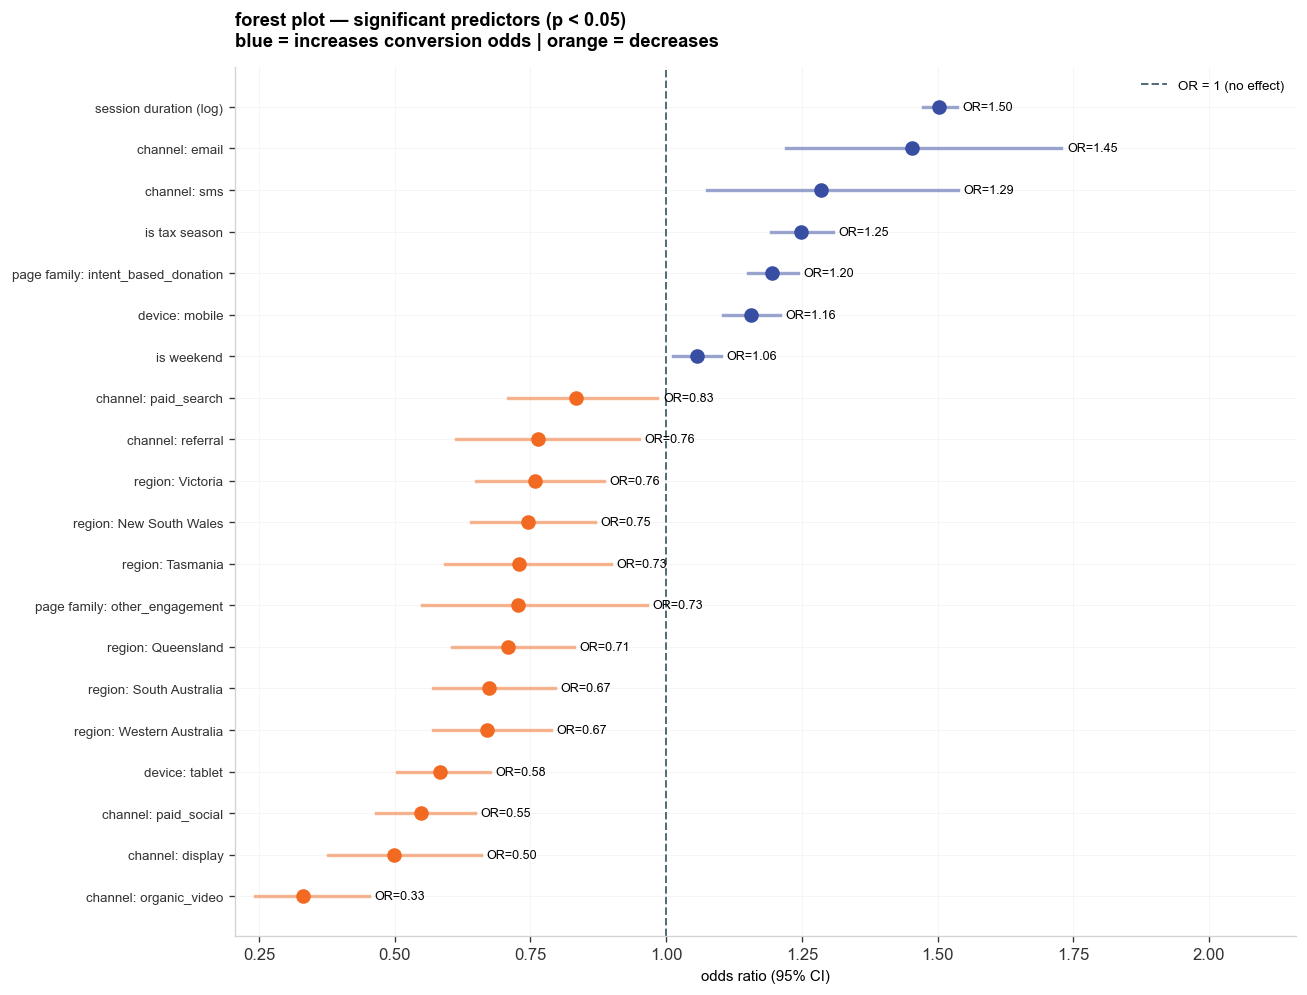

In [274]:
# ── multivariate logistic regression + VIF + forest plot ─────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

# filter rare categories
min_cell = 200
valid_ch  = data['session_channel'].value_counts()
valid_ch  = valid_ch[valid_ch >= min_cell].index
valid_fam = data['land_family'].value_counts()
valid_fam = valid_fam[valid_fam >= min_cell].index

df_multi = data[
    data['session_channel'].isin(valid_ch) &
    data['land_family'].isin(valid_fam)
][['session_channel', 'land_family', 'device_category',
   'region', 'is_weekend', 'is_tax_season',
   'log_duration', TCOL]].dropna()

formula = (
    f'{TCOL} ~ log_duration + '
    'C(session_channel) + C(land_family) + '
    'C(device_category) + C(region) + '
    'is_weekend + is_tax_season'
)

multi_model = smf.logit(formula, data=df_multi).fit(
    disp=0, maxiter=200, method='bfgs'
)

print(f"converged: {multi_model.mle_retvals['converged']}")
print(f"pseudo R² (McFadden): {multi_model.prsquared:.4f}")
print(f"AIC: {multi_model.aic:.2f}")
print(f"n:   {int(multi_model.nobs):,}")

# VIF
le      = LabelEncoder()
df_vif  = df_multi.copy()
for col in ['session_channel', 'land_family', 'device_category', 'region']:
    df_vif[col] = le.fit_transform(df_vif[col].astype(str))

X_vif = sm.add_constant(
    df_vif[['log_duration', 'session_channel', 'land_family',
            'device_category', 'region', 'is_weekend', 'is_tax_season']]
)
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).round(2)
print("\n=== VIF ===")
print(vif_data.to_string(index=False))

# forest plot
conf_int   = multi_model.conf_int()
odds_table = pd.DataFrame({
    'or'      : np.exp(multi_model.params),
    'ci_low'  : np.exp(conf_int[0]),
    'ci_high' : np.exp(conf_int[1]),
    'p'       : multi_model.pvalues
}).round(3)

odds_table = odds_table[
    (odds_table.index != 'Intercept') &
    (odds_table['p'] < 0.05) &
    (odds_table['or'] < 50) &
    (odds_table['or'] > 0.02)
].sort_values('or')

def clean_param(name):
    for old, new in [
        ('C(session_channel)[T.', 'channel: '),
        ('C(land_family)[T.',     'page family: '),
        ('C(device_category)[T.', 'device: '),
        ('C(region)[T.',          'region: '),
        (']', ''), ('log_duration', 'session duration (log)'),
        ('is_weekend', 'is weekend'), ('is_tax_season', 'is tax season'),
    ]:
        name = name.replace(old, new)
    return name

odds_table.index = [clean_param(i) for i in odds_table.index]

fig, ax = plt.subplots(figsize=(11, max(6, len(odds_table) * 0.42)))

for i, (idx, row) in enumerate(odds_table.iterrows()):
    colour = u_blue if row['or'] > 1 else u_orange
    ax.plot([row['ci_low'], row['ci_high']], [i, i],
            color=colour, linewidth=2, alpha=0.5)
    ax.scatter(row['or'], i, color=colour, s=60, zorder=3)
    ax.text(row['ci_high'] + 0.01, i,
            f"OR={row['or']:.2f}",
            va='center', ha='left', fontsize=7.5)

ax.axvline(1, color=u_grey, linestyle='--', linewidth=1.2,
           label='OR = 1 (no effect)')
ax.set_yticks(range(len(odds_table)))
ax.set_yticklabels(odds_table.index, fontsize=8)
ax.set_xlabel('odds ratio (95% CI)', fontsize=9)
ax.set_title('forest plot — significant predictors (p < 0.05)\n'
             'blue = increases conversion odds | orange = decreases',
             loc='left', fontsize=11)
ax.legend(fontsize=8, frameon=False)
ax.set_xlim(odds_table['ci_low'].min() * 0.85,
            odds_table['ci_high'].max() * 1.25)
strip_axes(ax)
plt.tight_layout()
plt.show()